In [2]:
import matplotlib.pyplot as plt
from os import walk
import json
import numpy as np 

In [3]:
mypath = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/resnet-logs-new-2/'
filenames = next(walk(mypath), (None, None, []))[2]  # [] if no file

In [4]:
hashs = []
values = {}
for name in filenames:
    f = open(mypath + name, "r")
    best = 100000
    for line in f:
        result = json.loads(line)
        task = result['i'][0][0]
        r = sum(result['r'][0])/len(result['r'][0])
        if(task not in values):
            values[task] = []
        if(r < best):
            best = r
        if(r < 1000):
            values[task].append(best)

In [5]:
for task in values:
    print(task)

["f96117bda6ea9cbc0291c643079b3700", [1, 56, 56, 64], [3, 3, 64, 64], [1, 1, 1, 64], [1, 56, 56, 64], [1, 56, 56, 64]]
["07f9fcad27bdd3233f86fe35a5185d33", [1, 224, 224, 3], [7, 7, 3, 64], [1, 1, 1, 64], [1, 112, 112, 64]]
["08f7449d79e570b7274174709e5e5e01", [1, 512], [1000, 512], [1, 1000], [1, 1000]]
["cb5e1bf27549411a1320749a1d8e07ca", [1, 14, 14, 256], [1, 1, 256, 512], [1, 1, 1, 512], [1, 7, 7, 512]]
["d37380659057397544e056461ea3bad3", [1, 56, 56, 64], [3, 3, 64, 64], [1, 1, 1, 64], [1, 56, 56, 64]]
["c219de5fa5fe694343f2826ebe8e47ce", [1, 112, 112, 64], [1, 56, 56, 64]]
["cb5e1bf27549411a1320749a1d8e07ca", [1, 28, 28, 128], [1, 1, 128, 256], [1, 1, 1, 256], [1, 14, 14, 256]]
["8c53ca2904398da2889aa7508082d7bb", [1, 7, 7, 512], [1, 1, 1, 512]]
["07f9fcad27bdd3233f86fe35a5185d33", [1, 56, 56, 64], [3, 3, 64, 128], [1, 1, 1, 128], [1, 28, 28, 128]]
["38552500208b25b4035682b0e93cbce3", [1, 14, 14, 256], [6, 6, 256, 256], [1, 1, 1, 256], [1, 14, 14, 256]]
["4f6b116e24c389f1cf7d9a59d

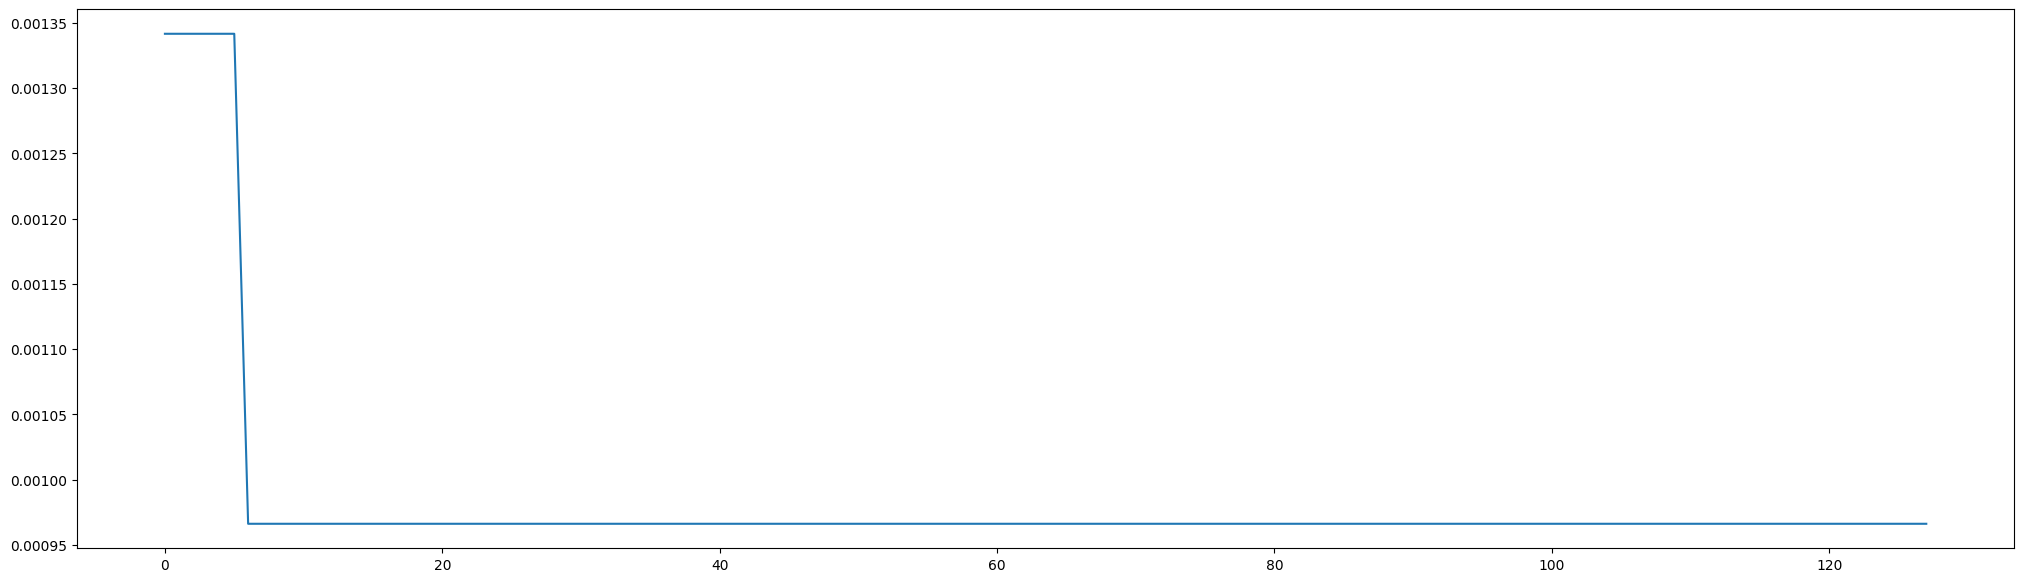

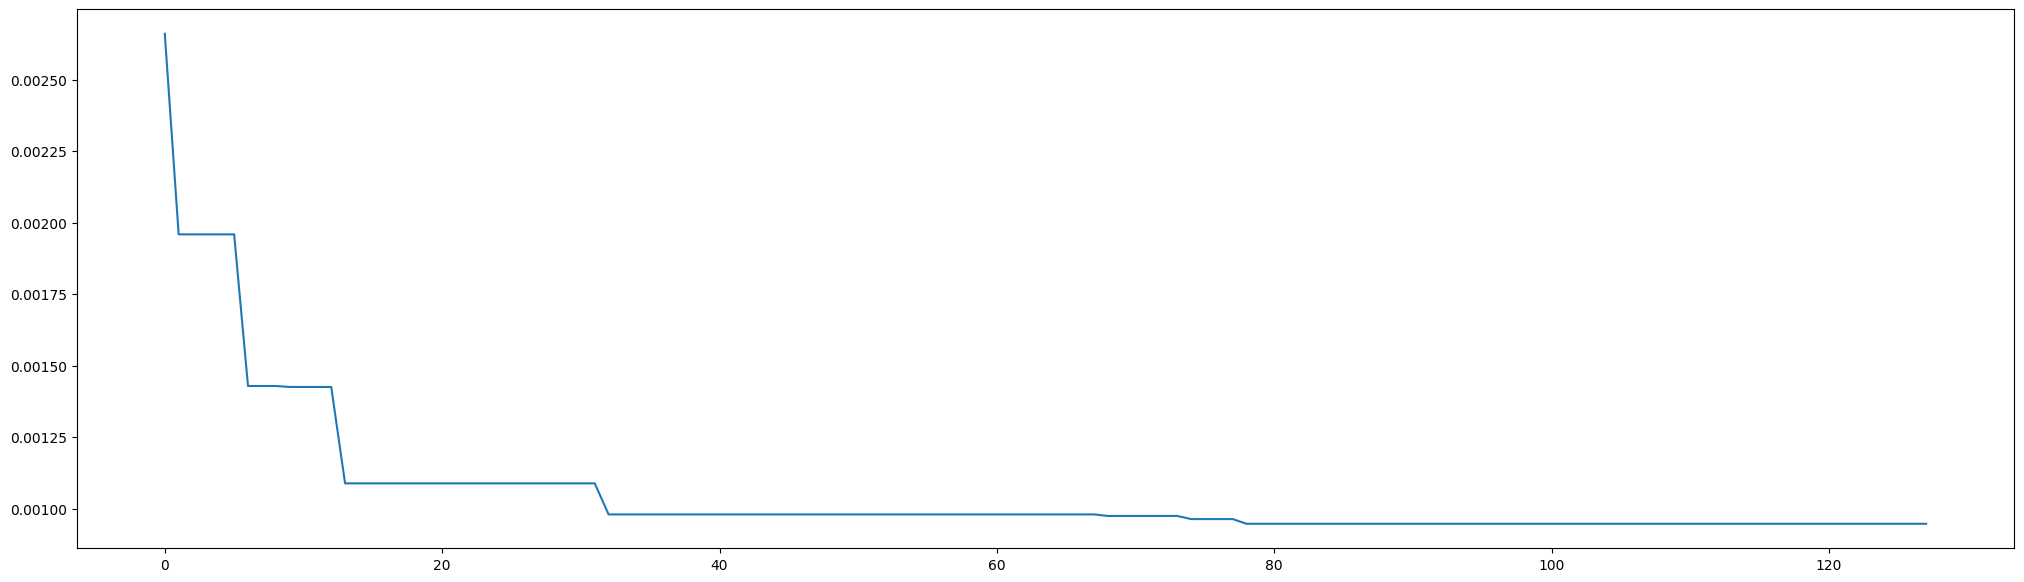

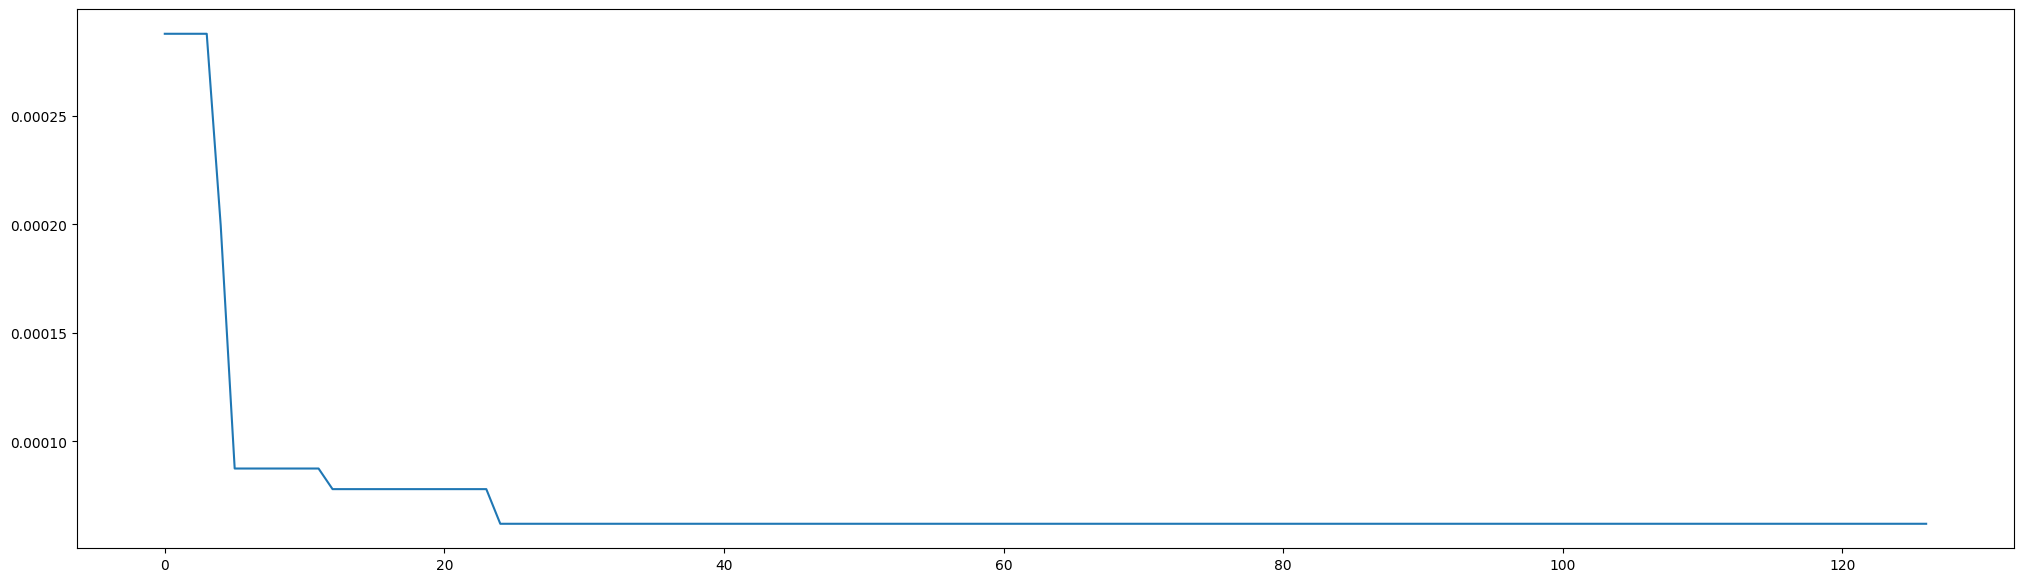

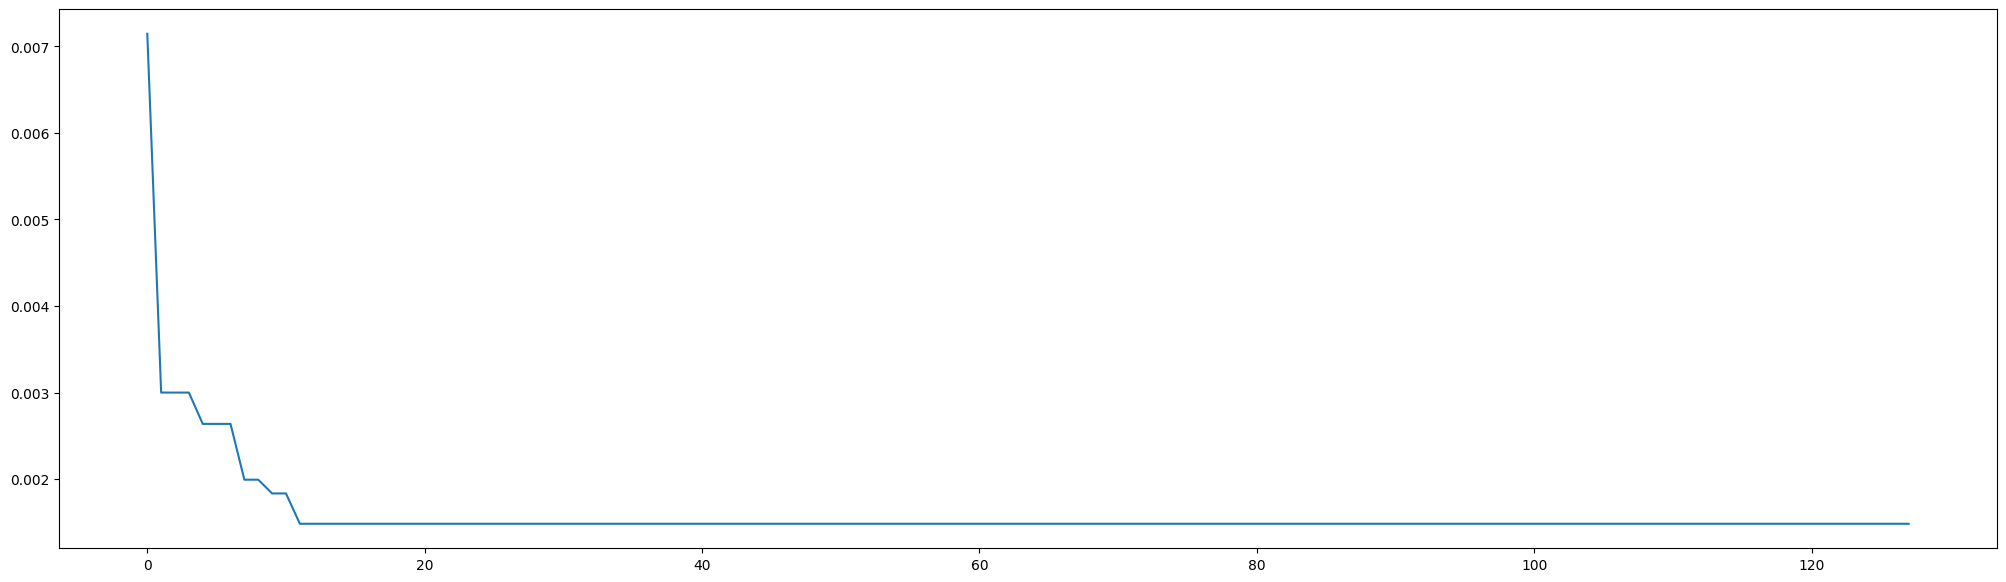

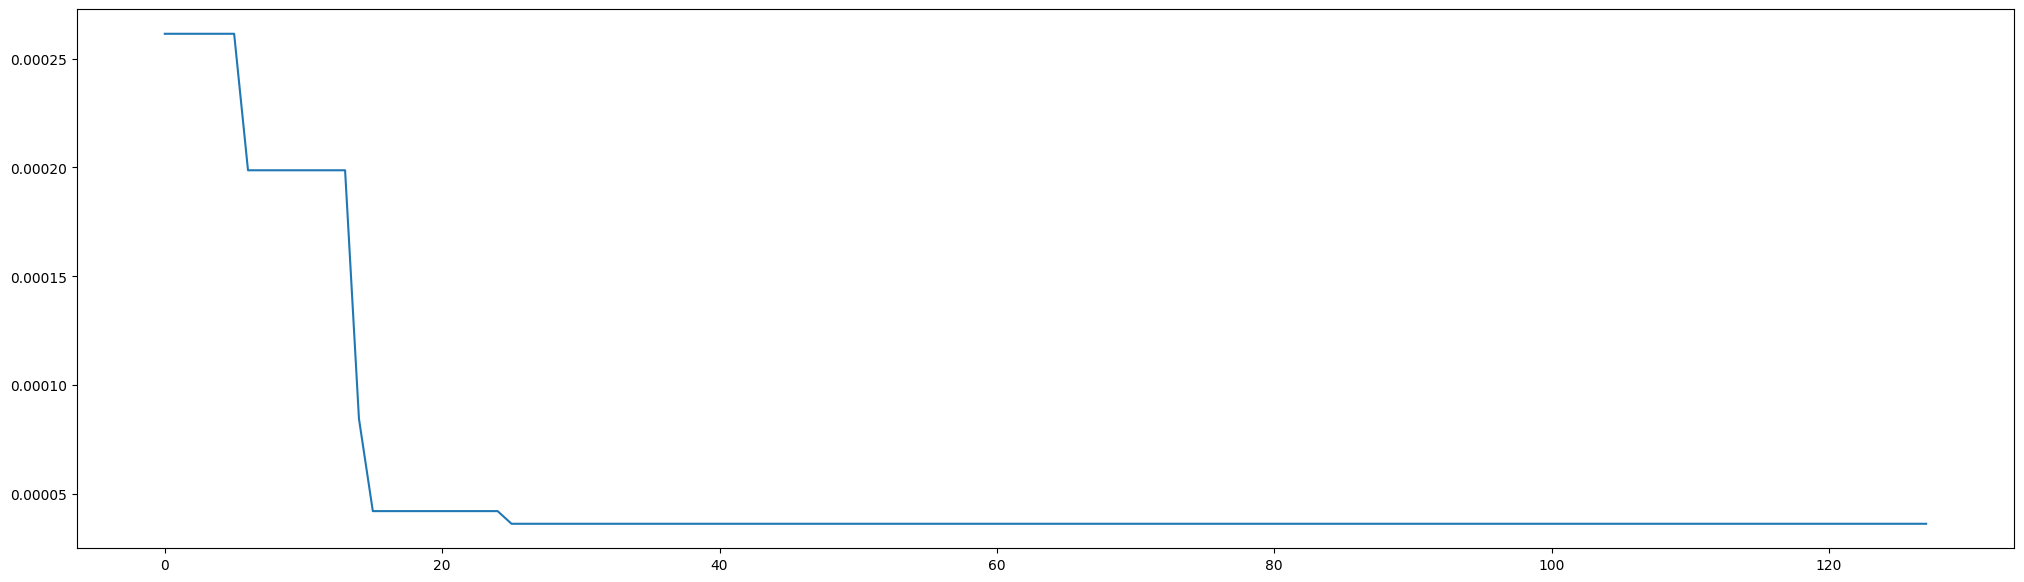

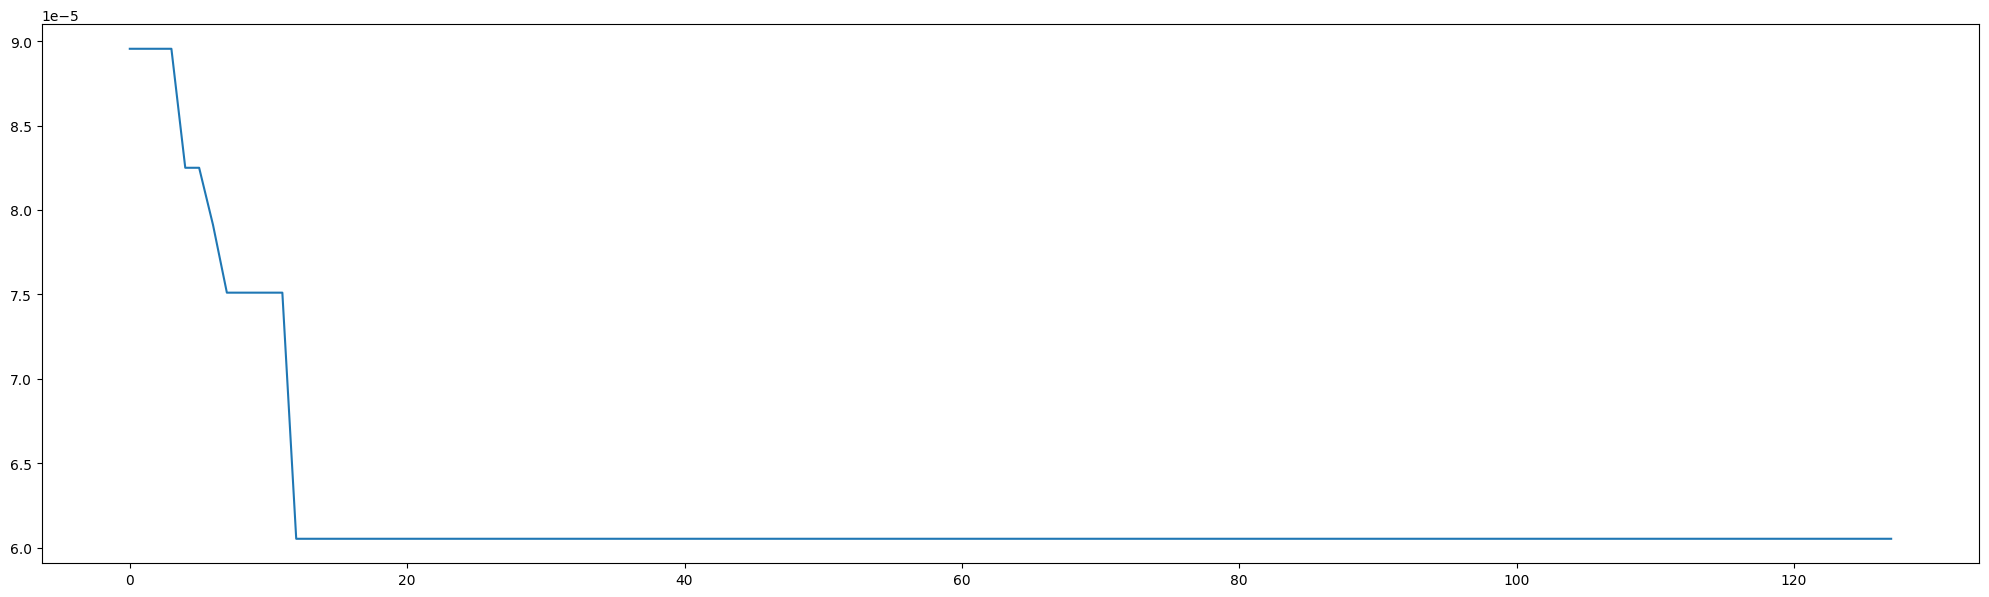

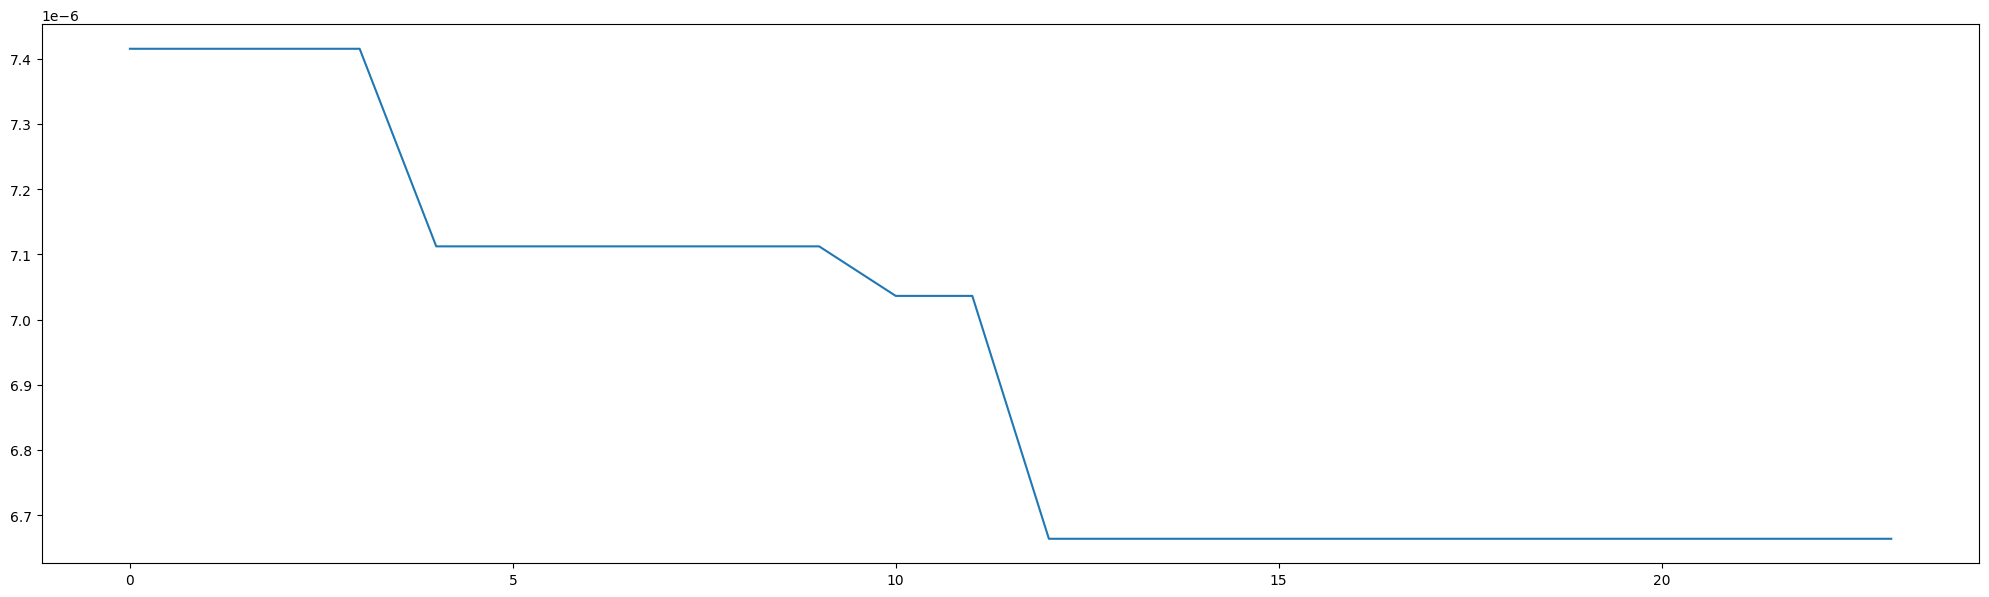

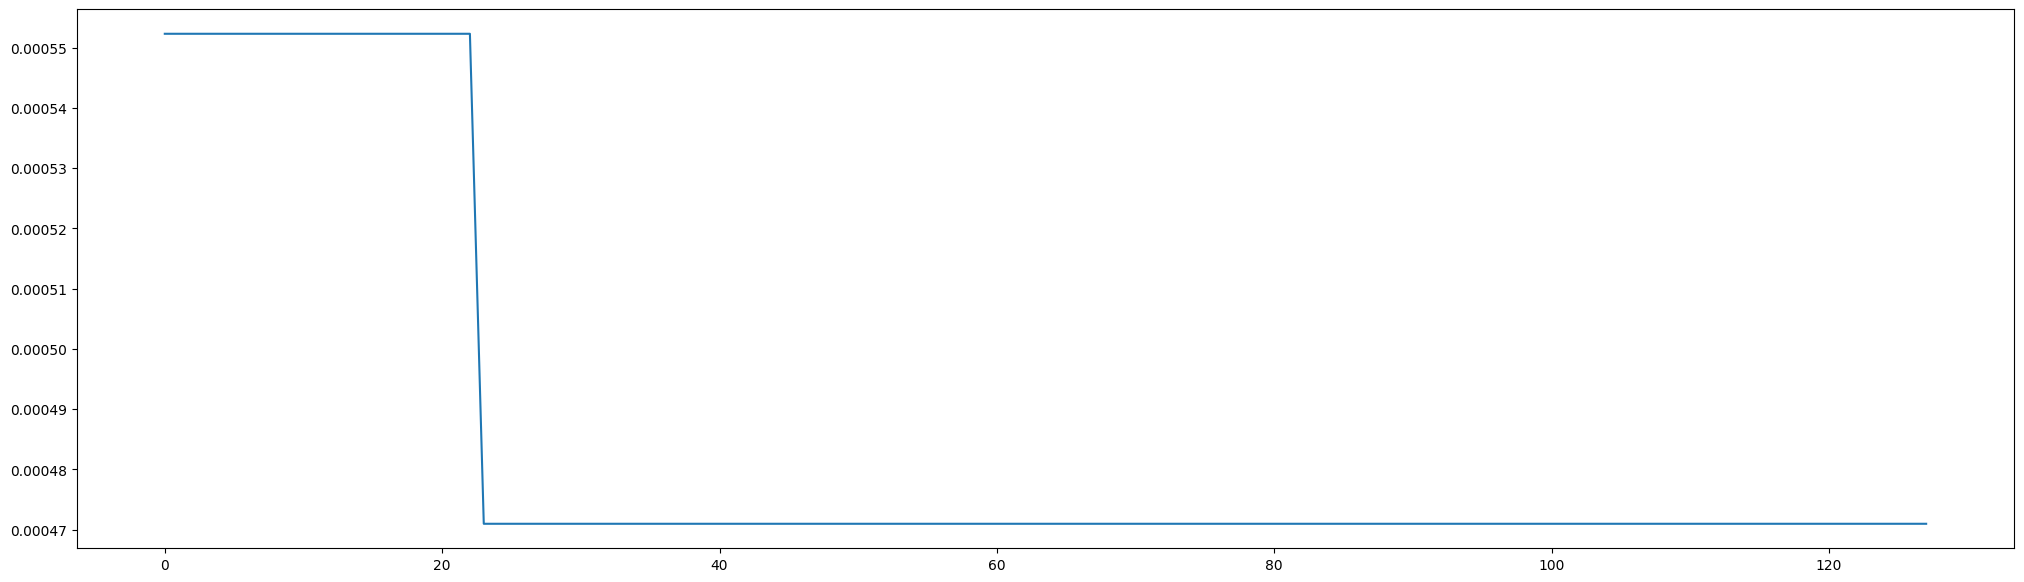

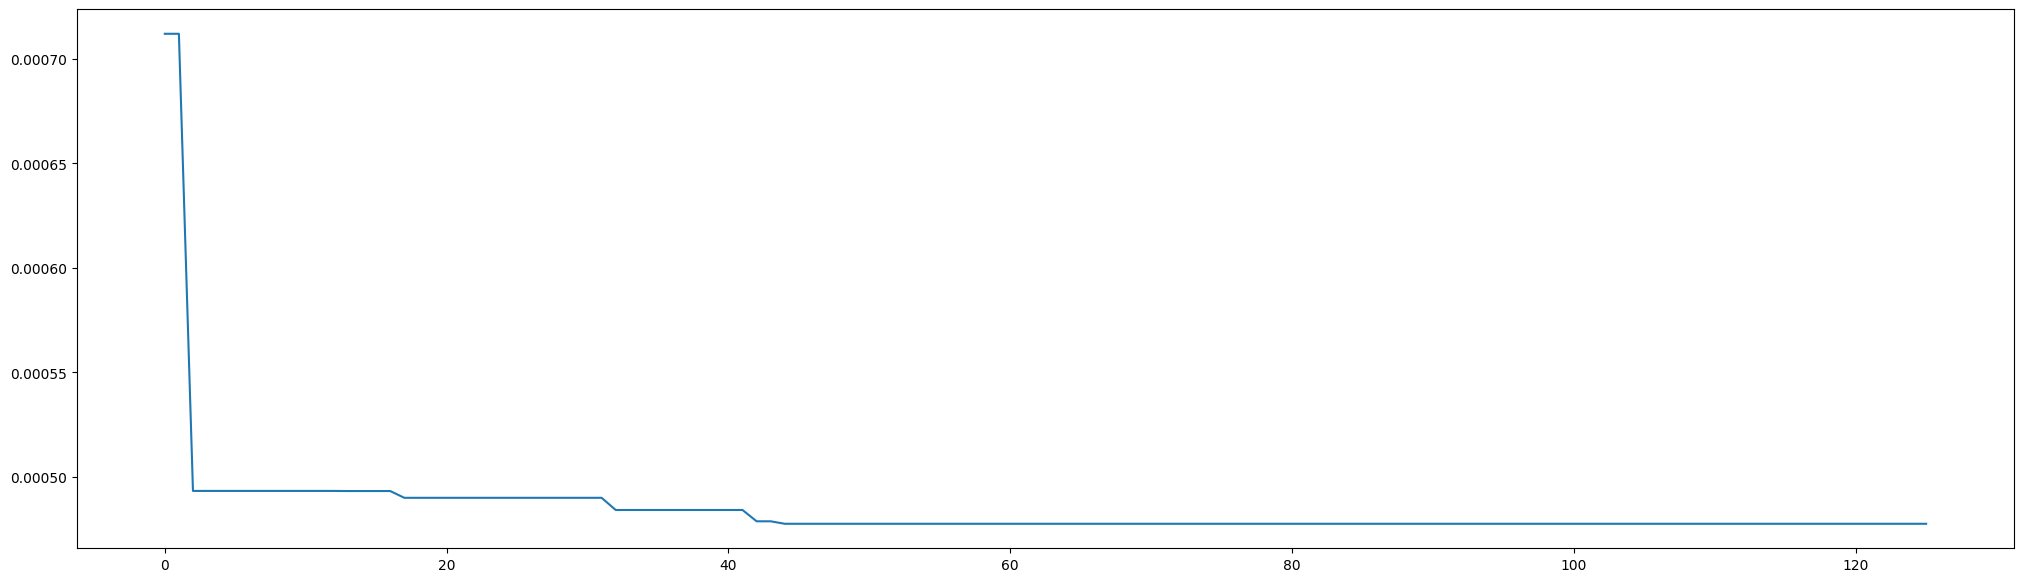

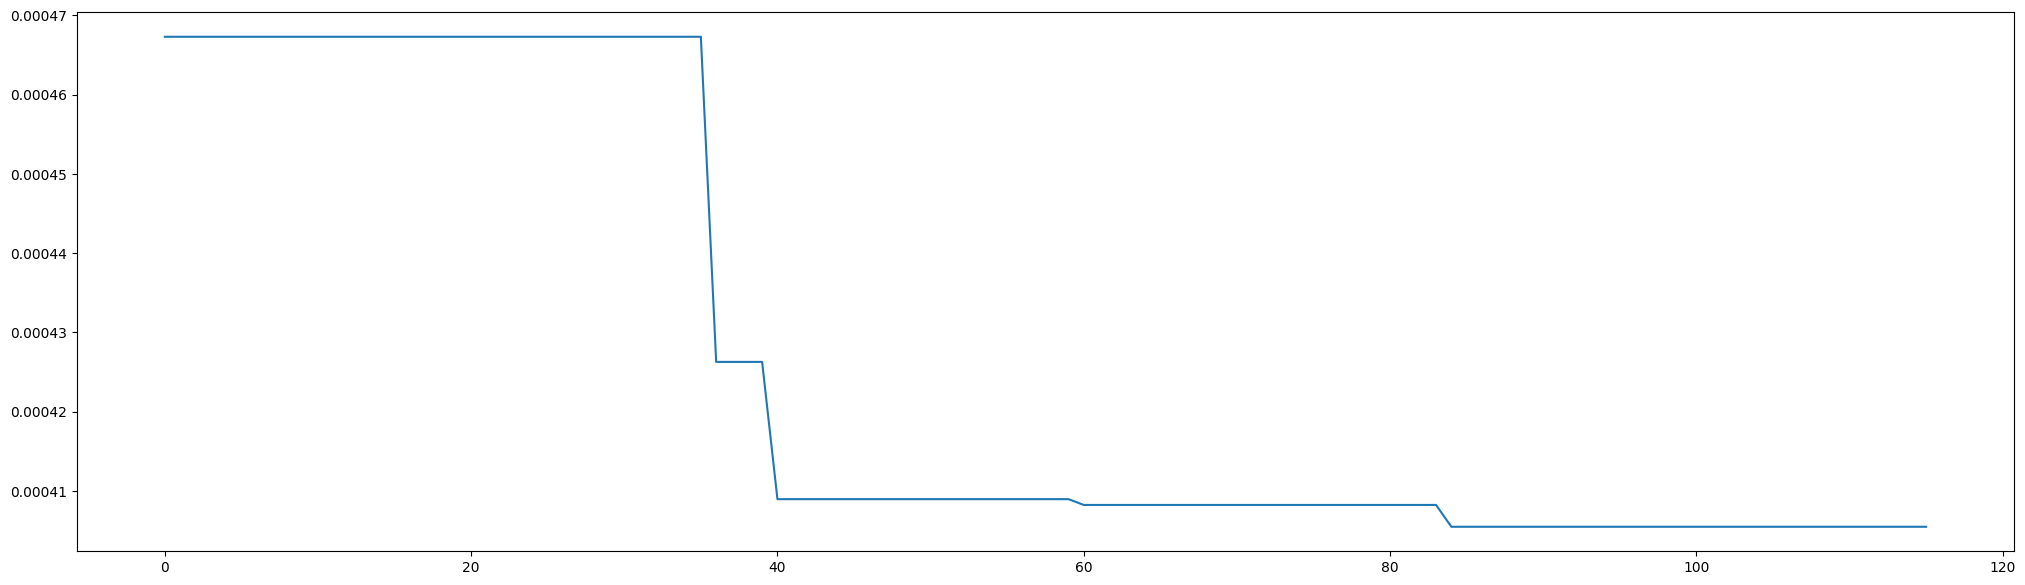

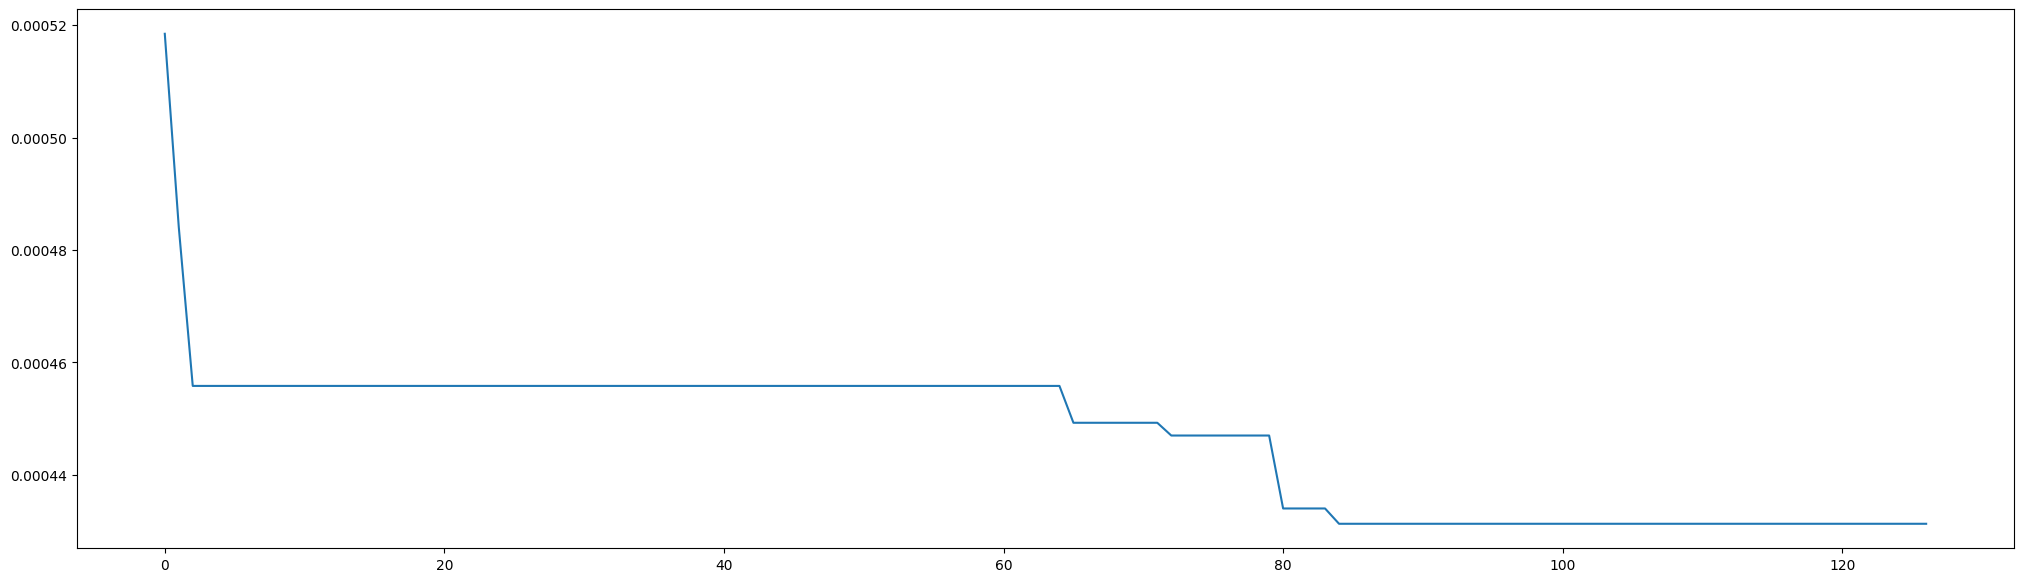

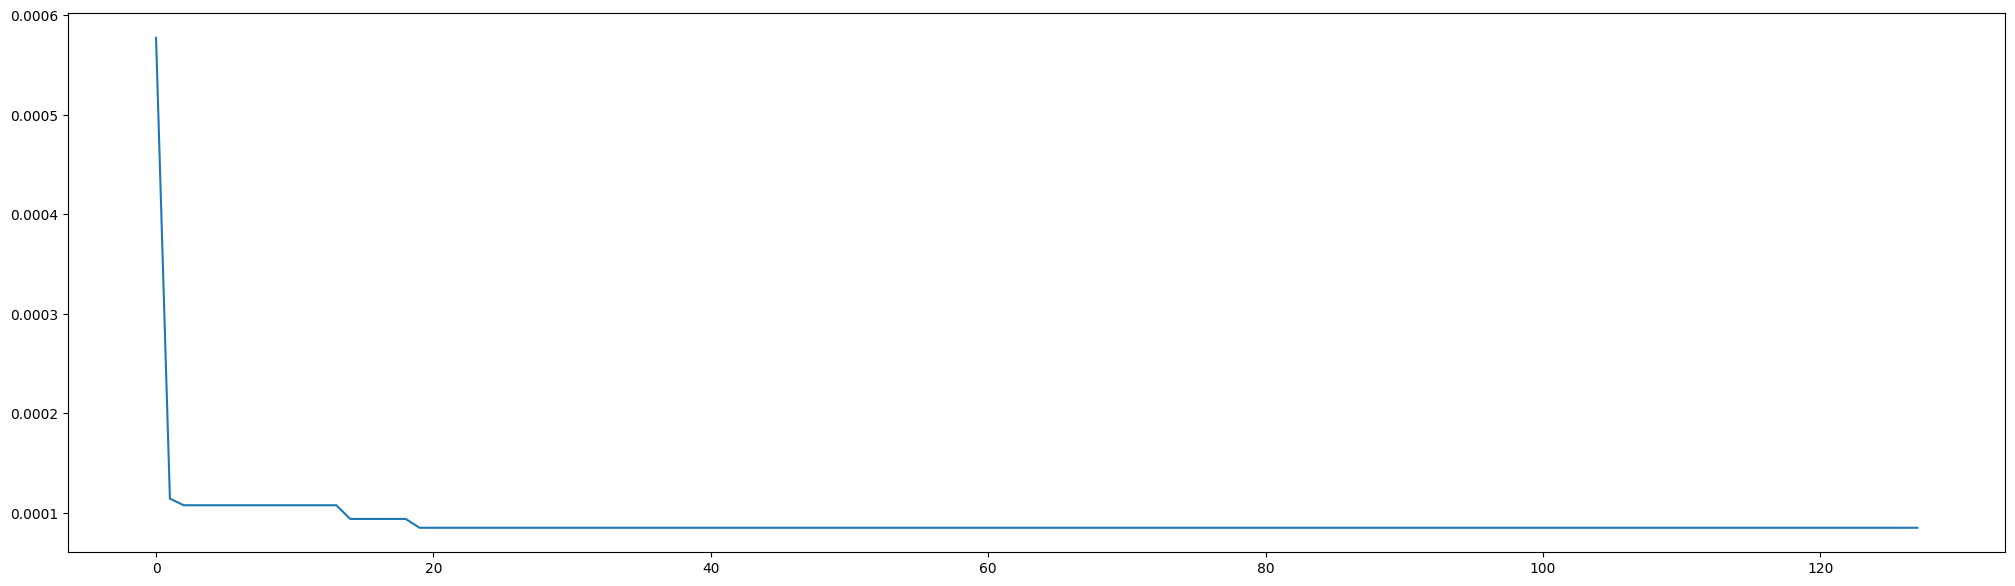

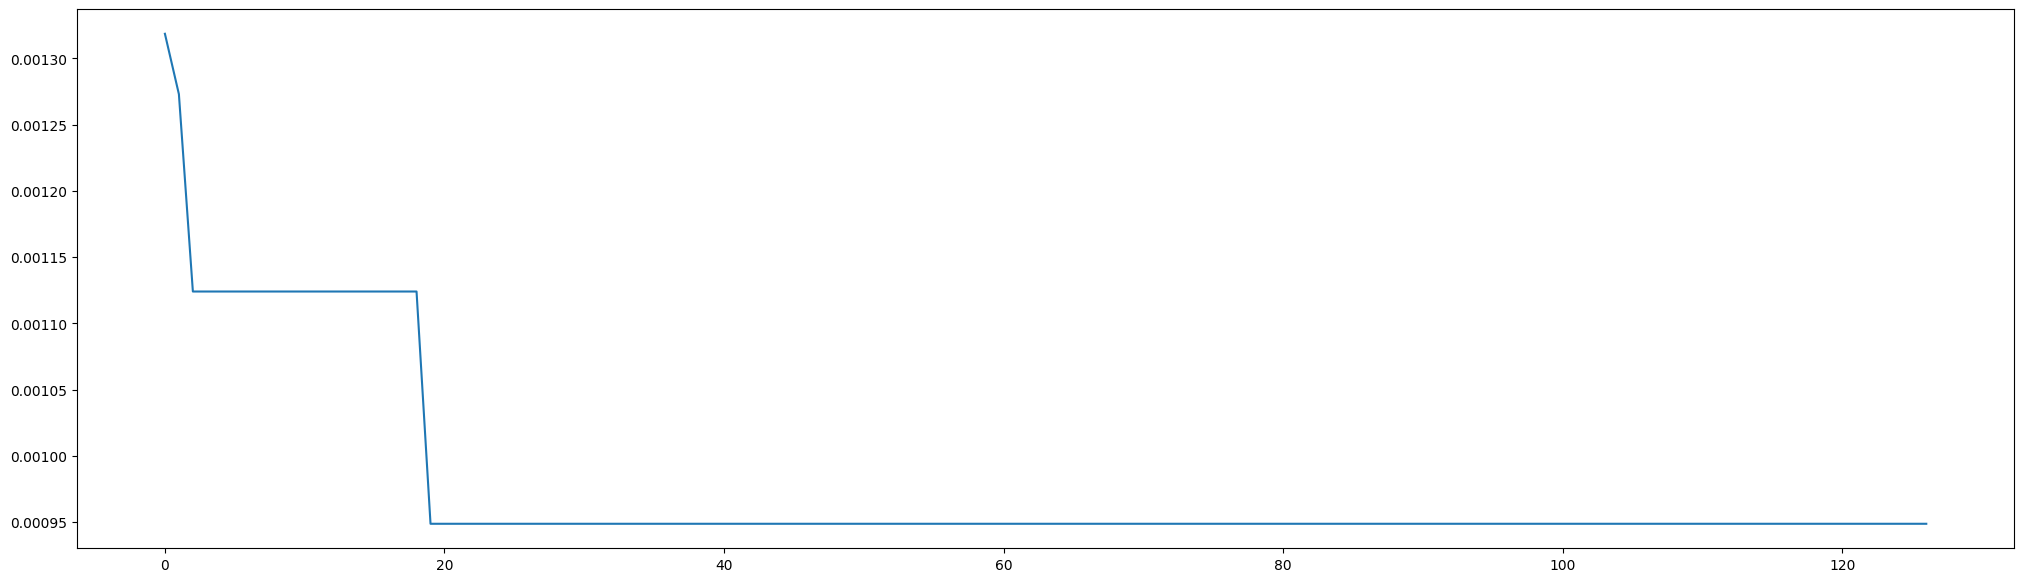

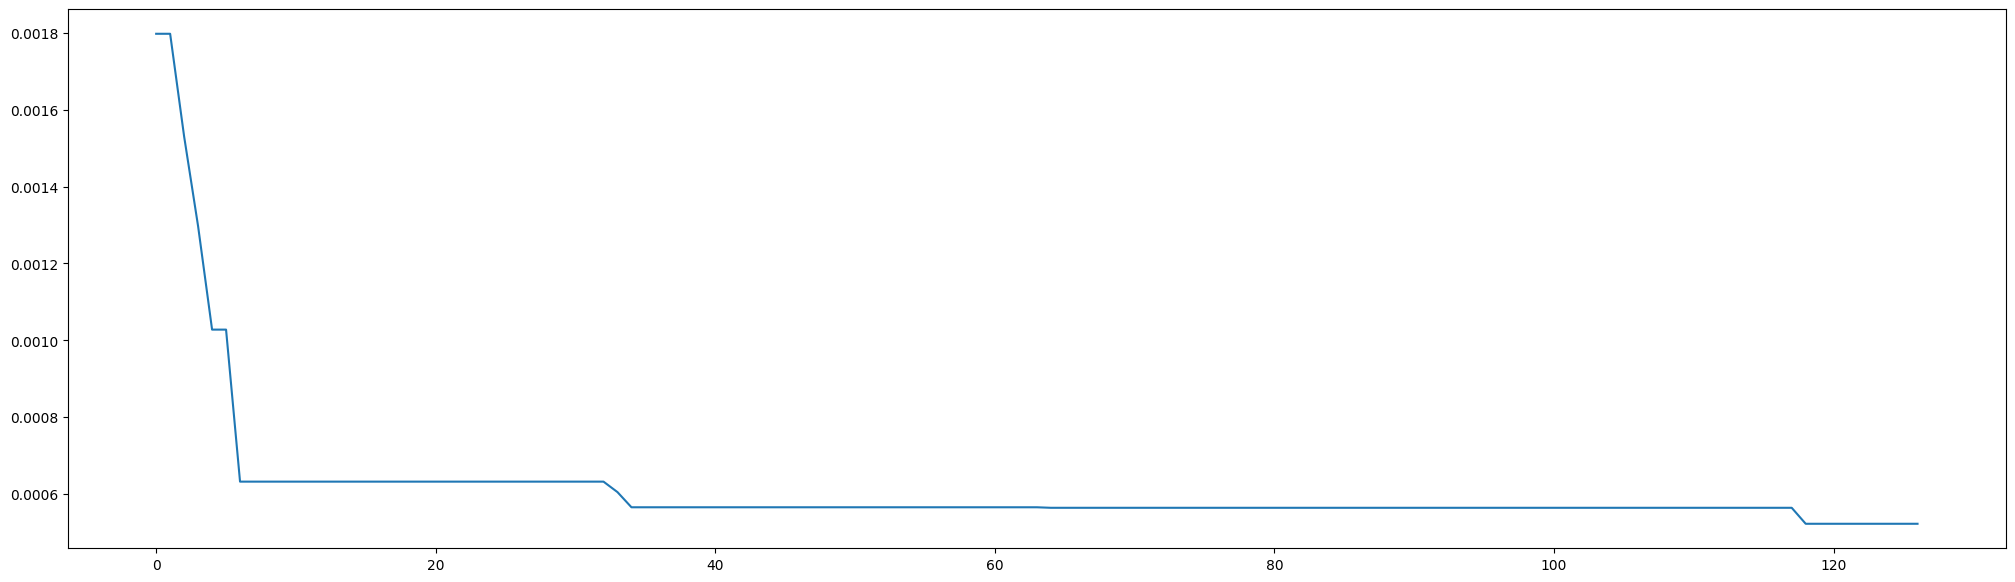

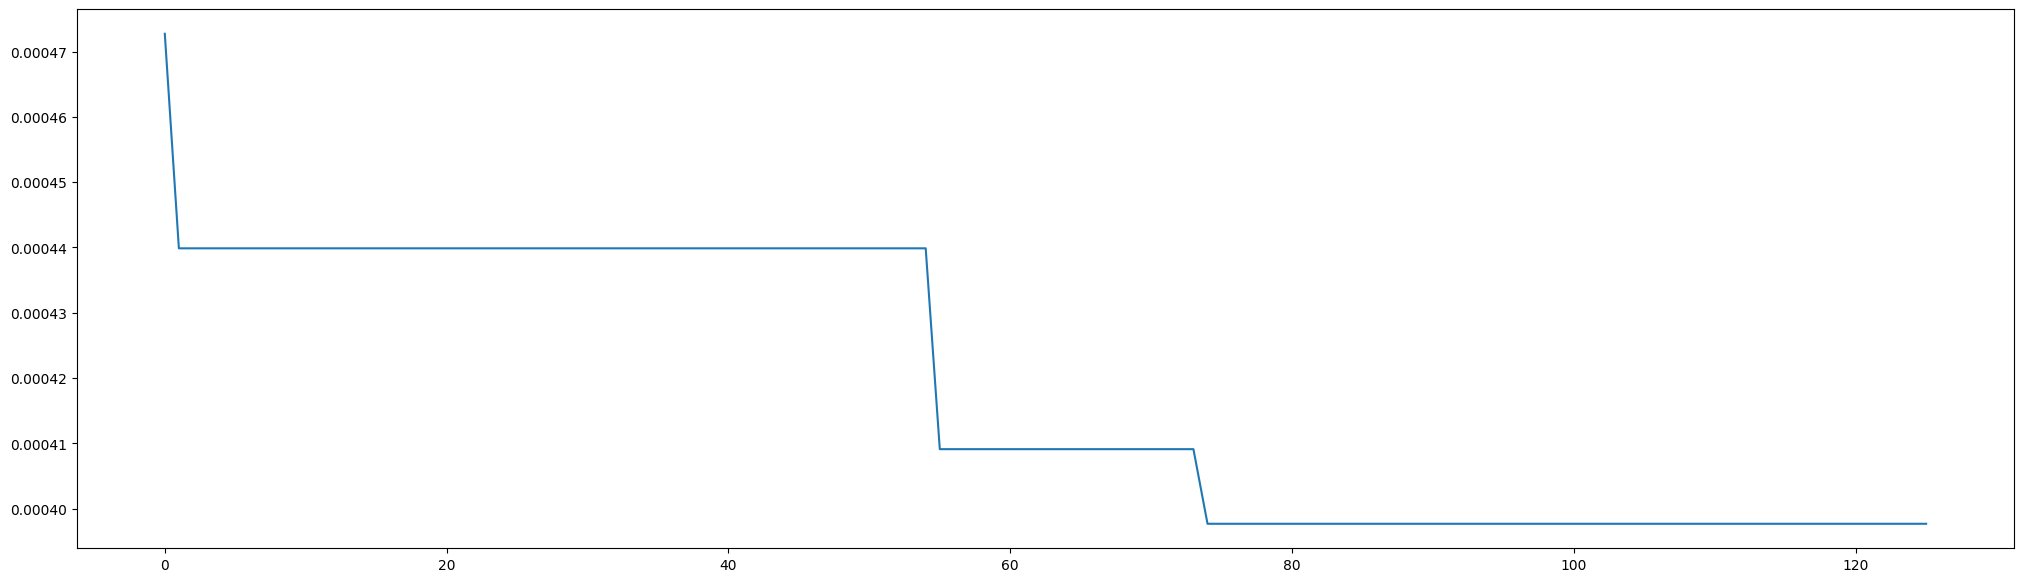

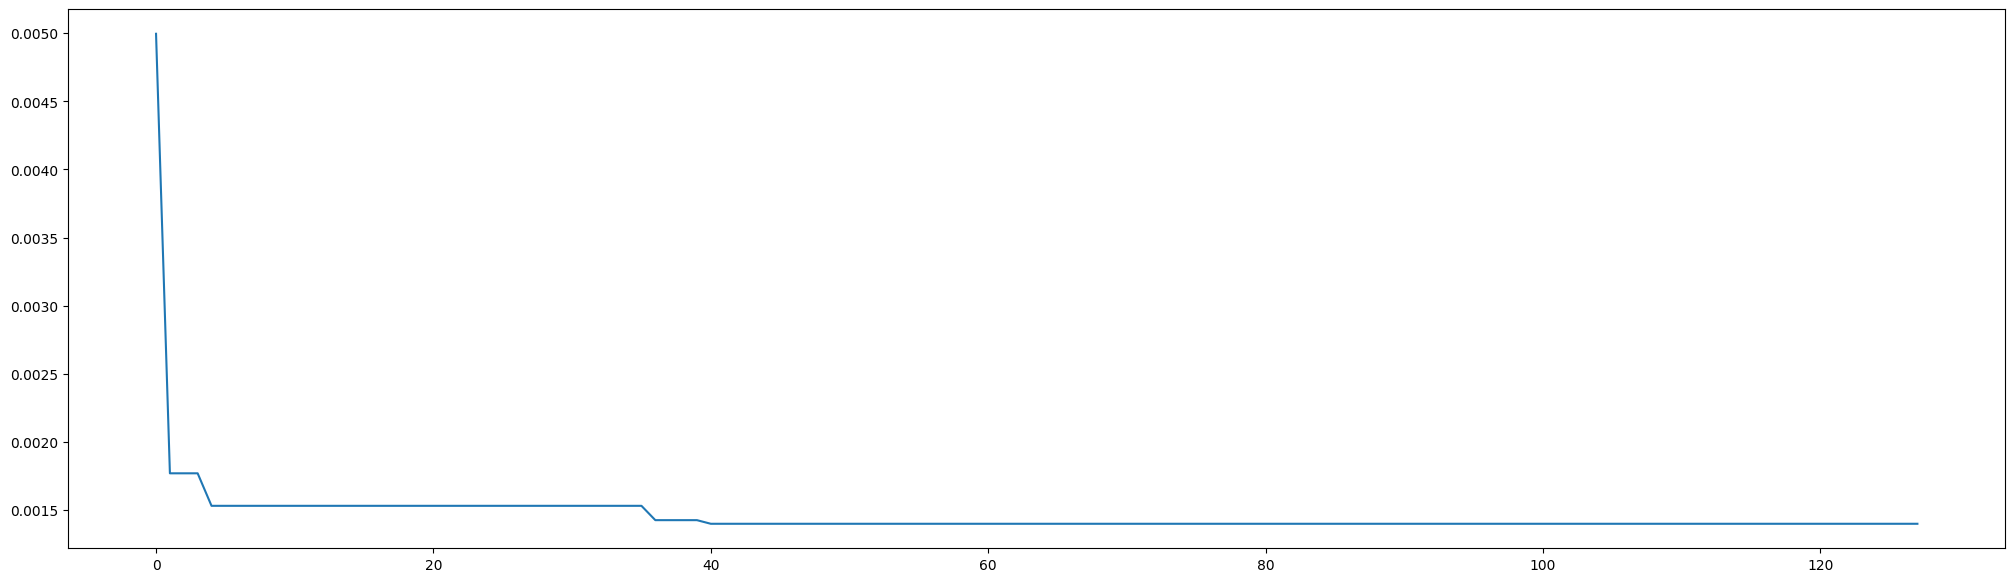

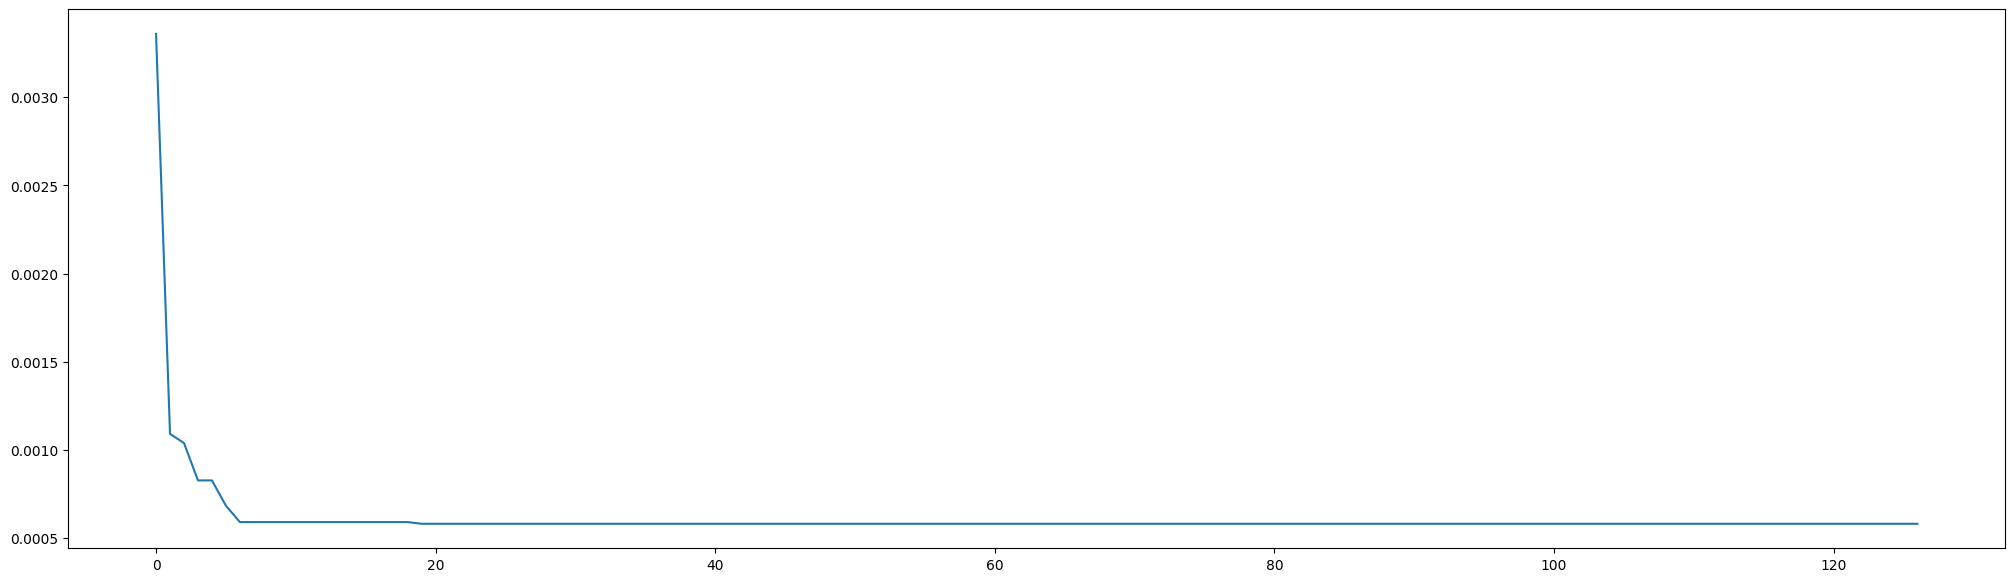

In [6]:
for task in values:
    if(len(values[task])):
        plt.figure(figsize=(25, 7))
        plt.plot(values[task])
        plt.show()

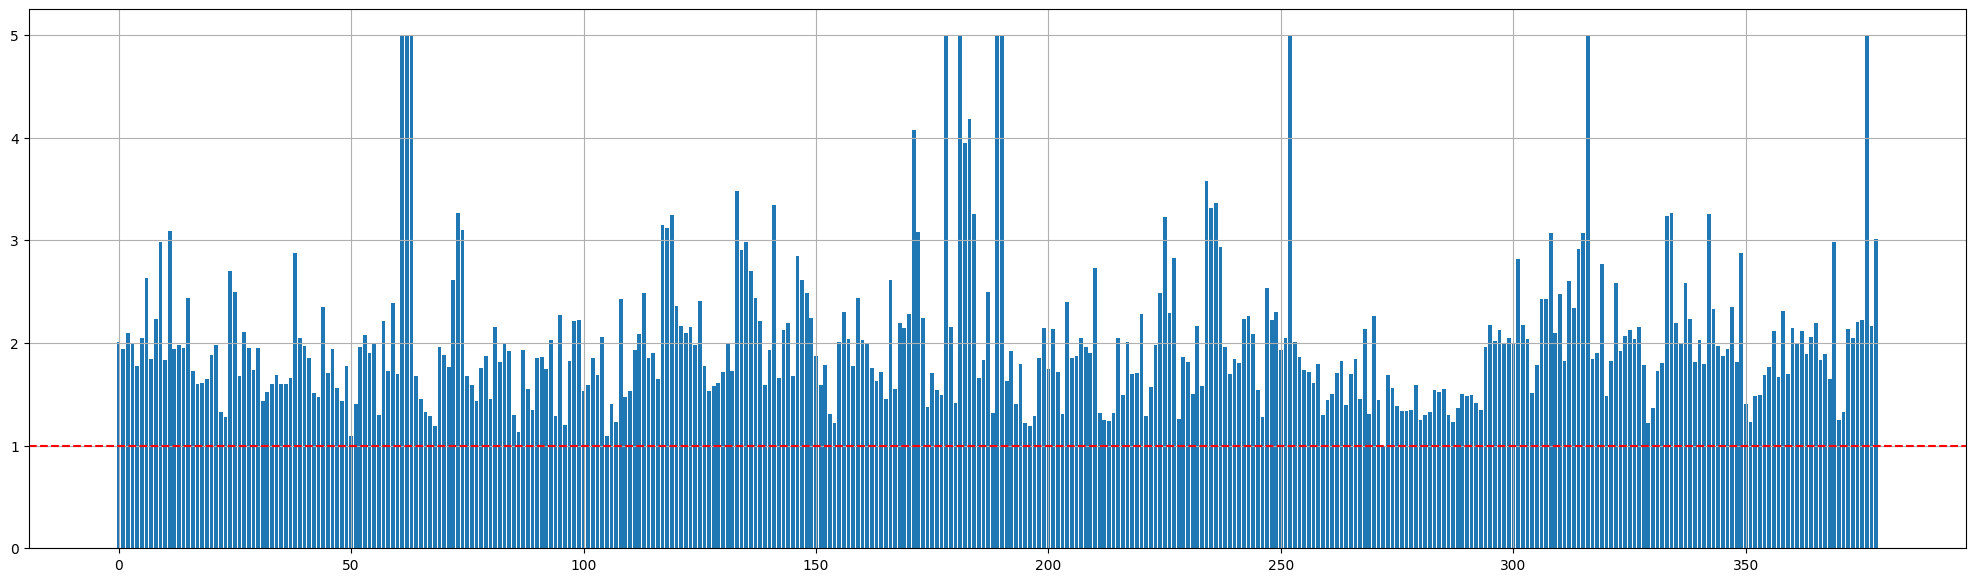

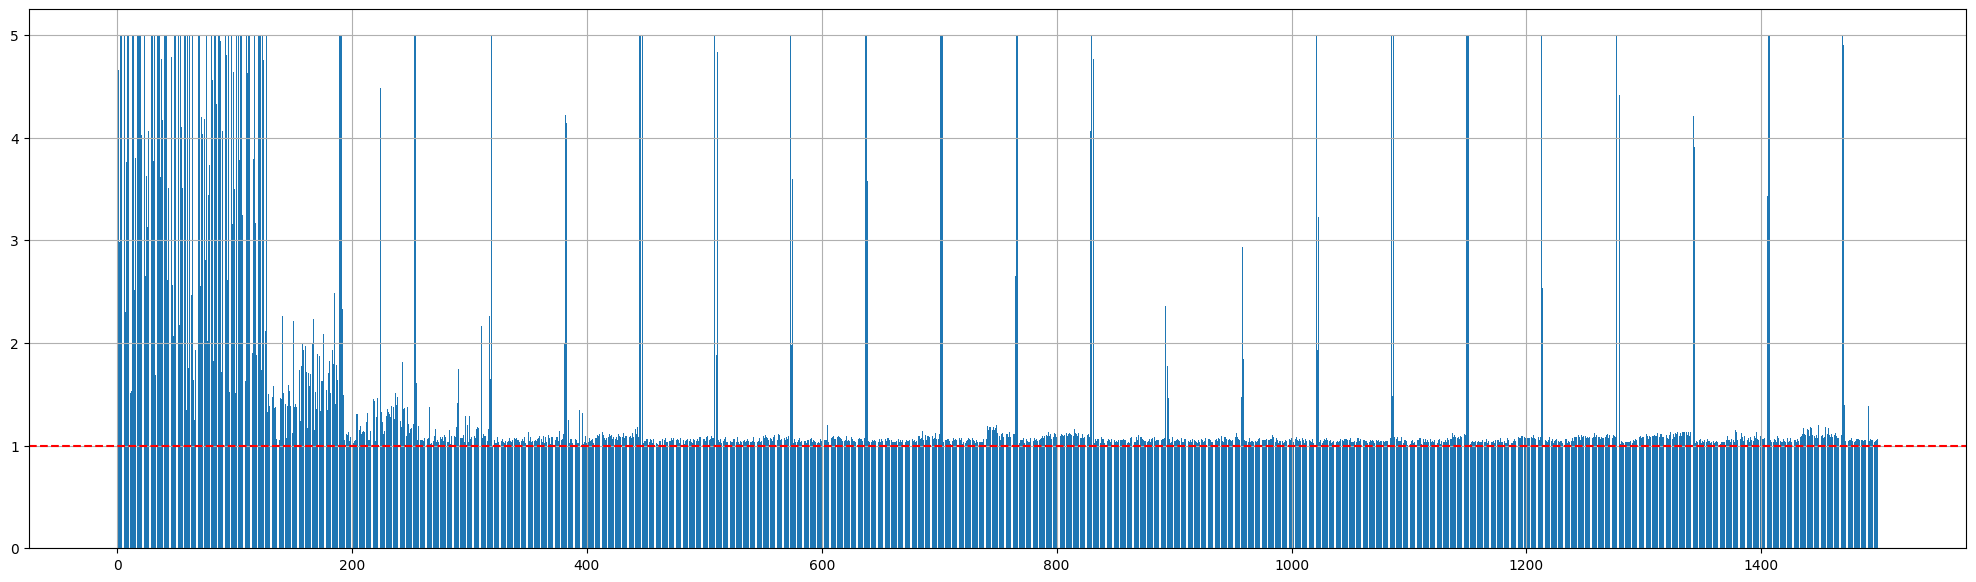

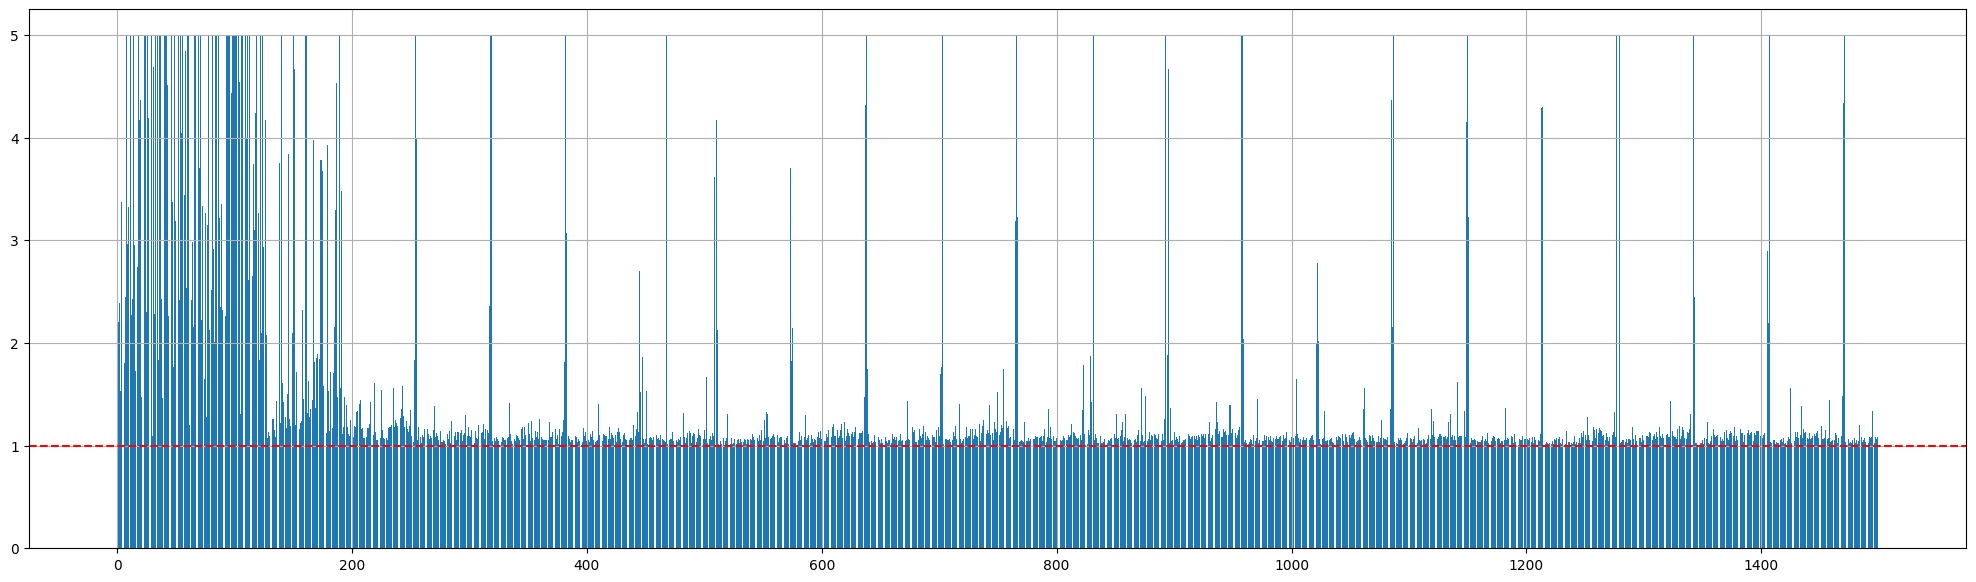

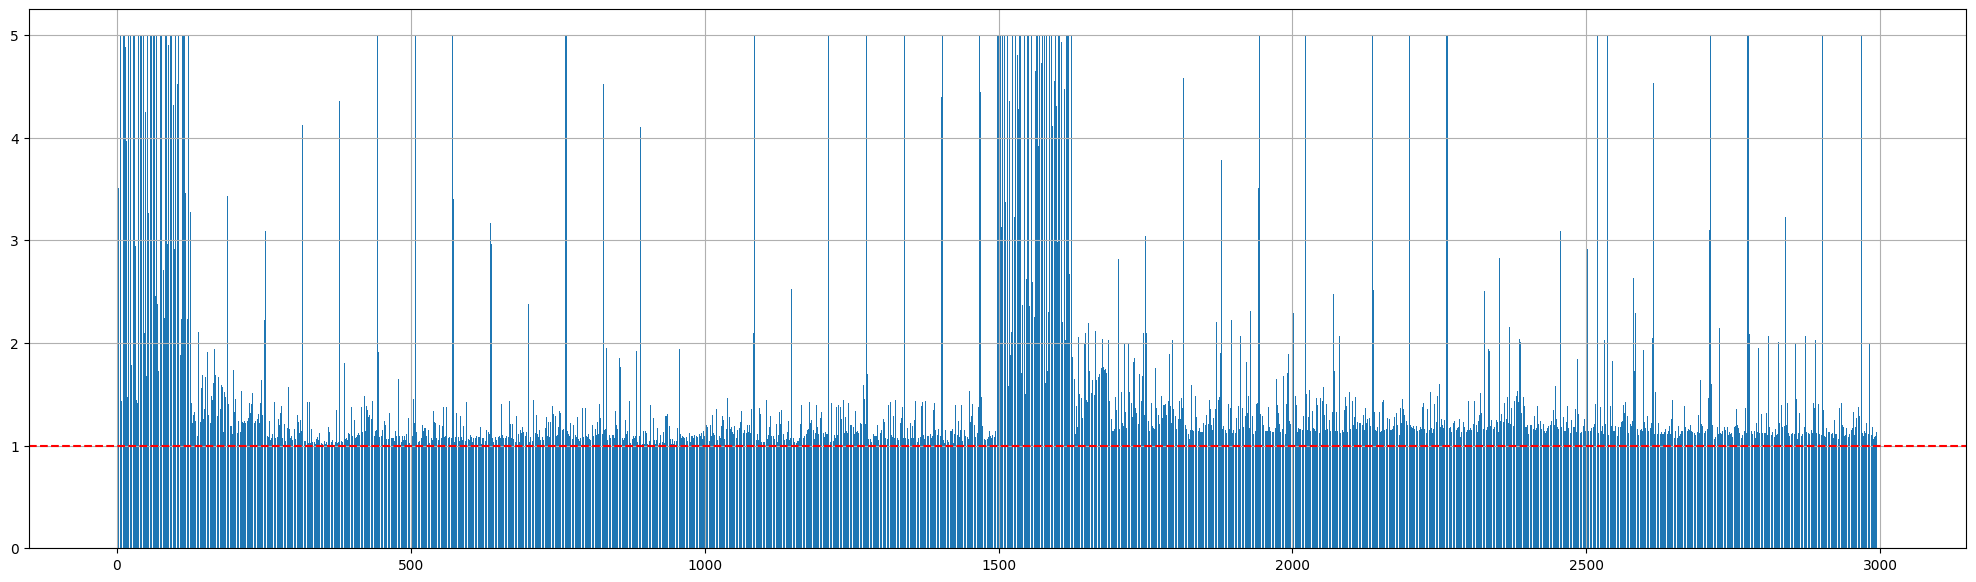

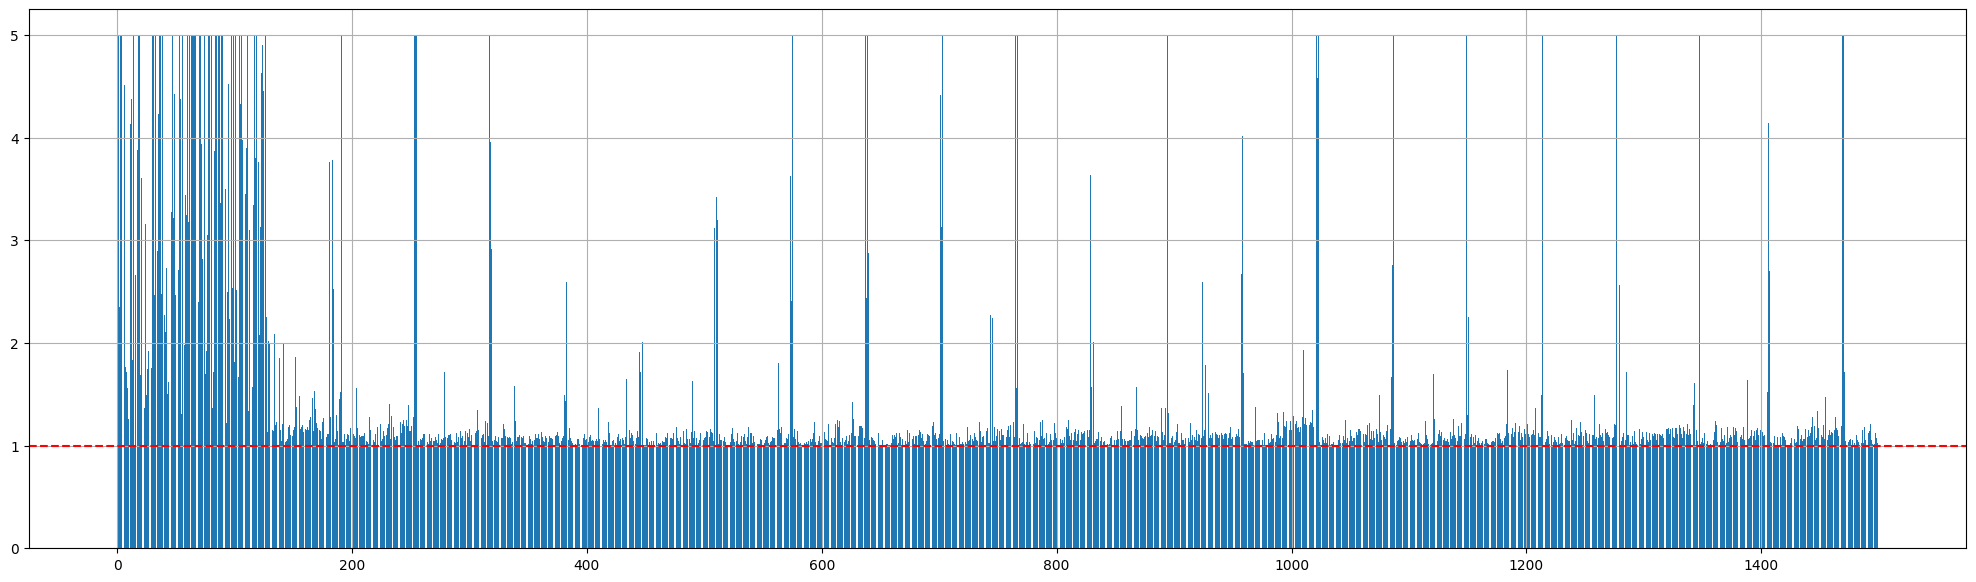

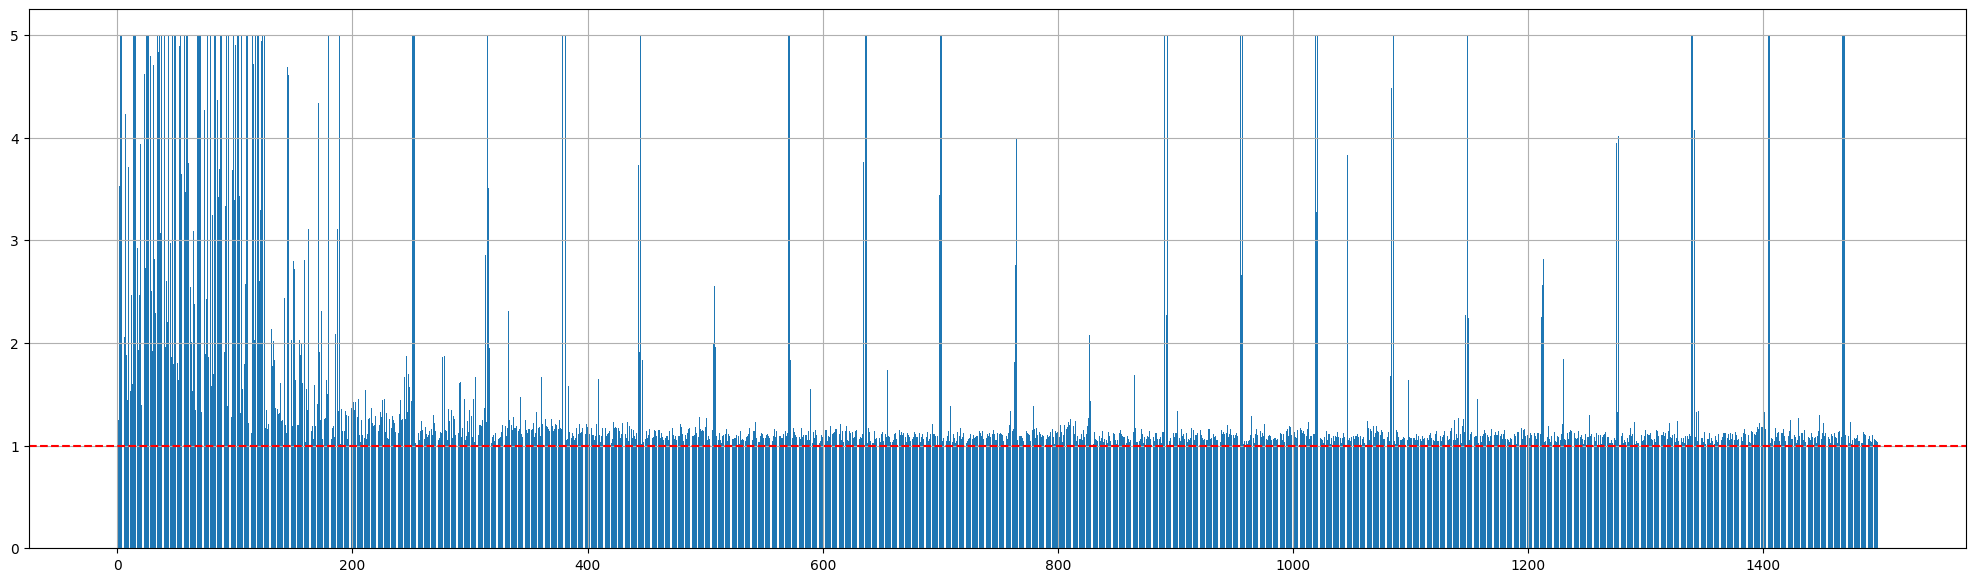

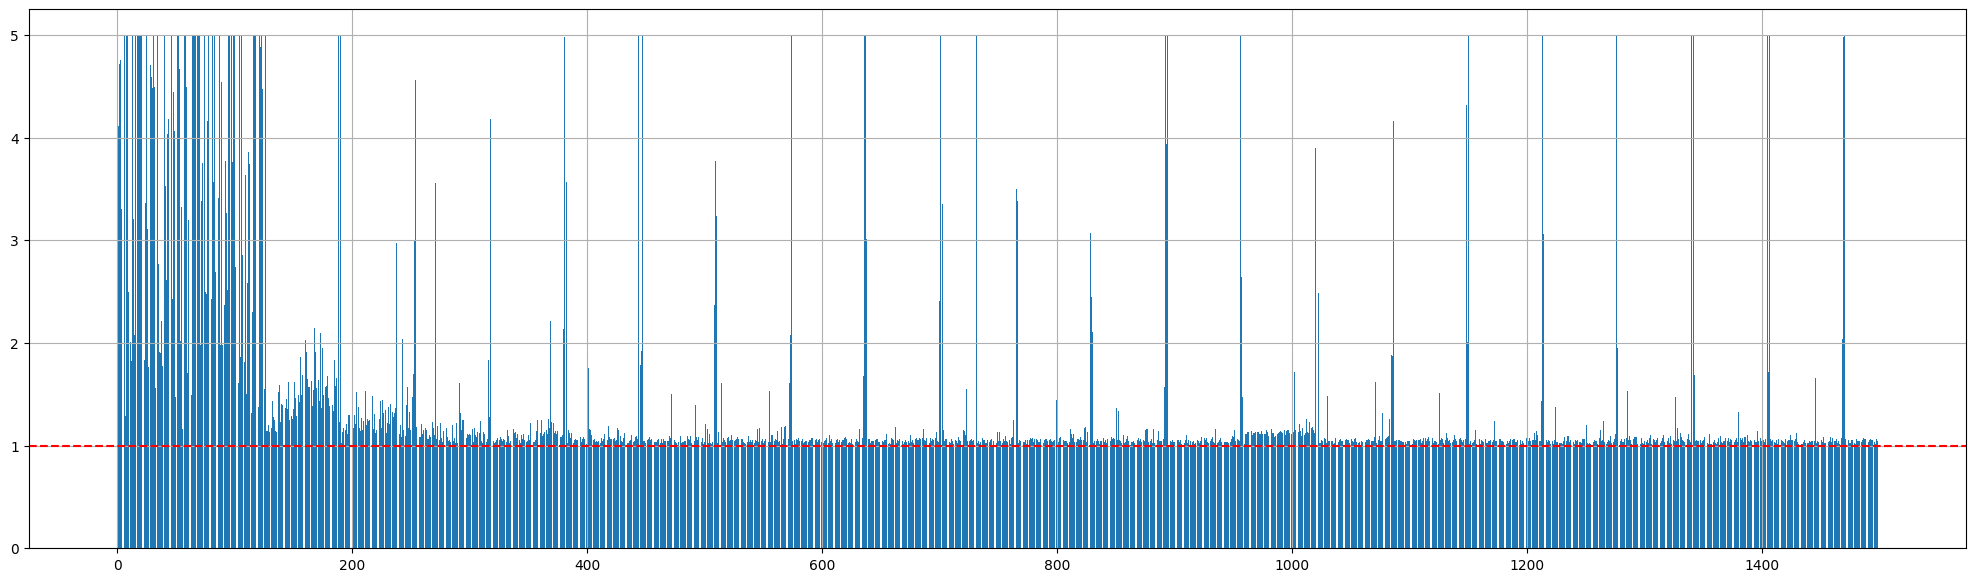

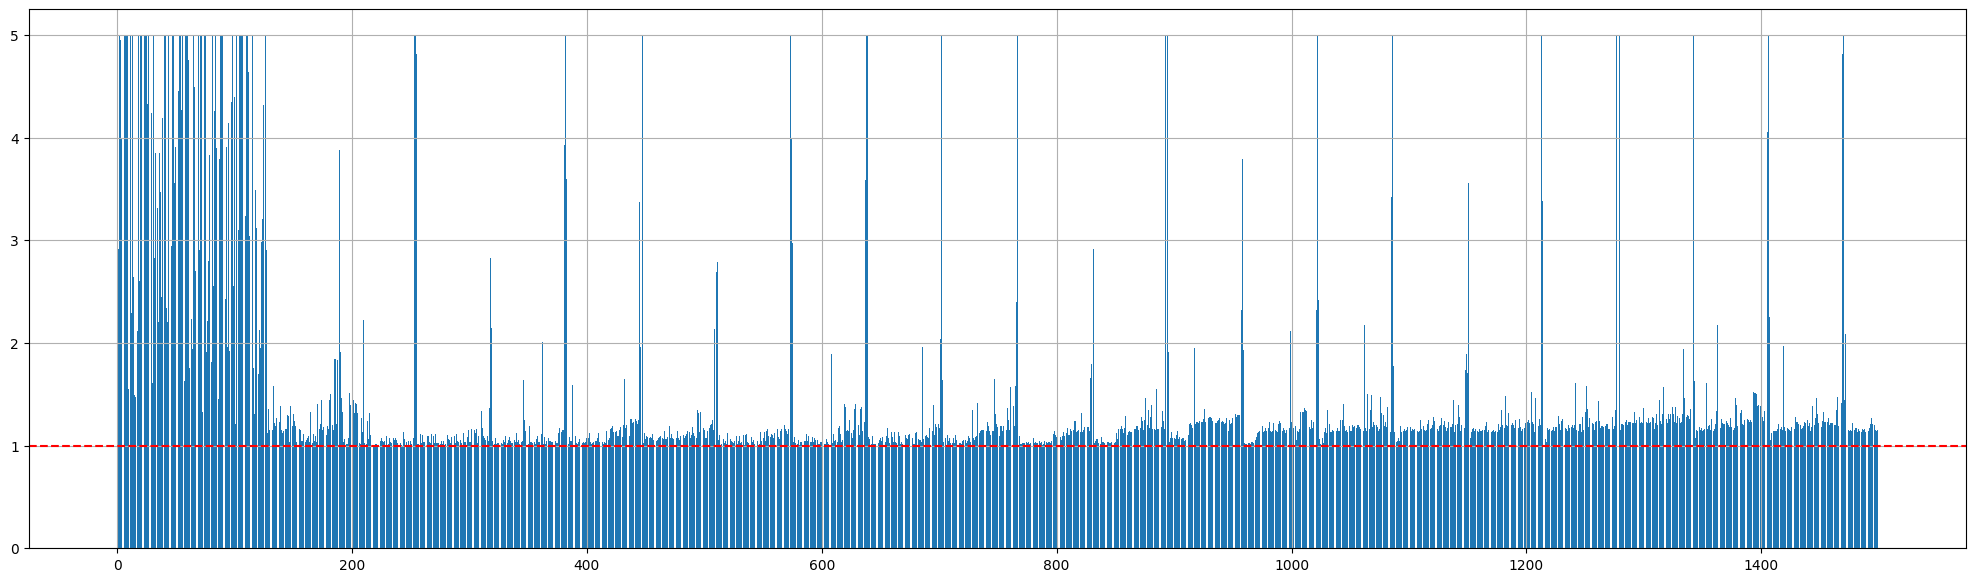

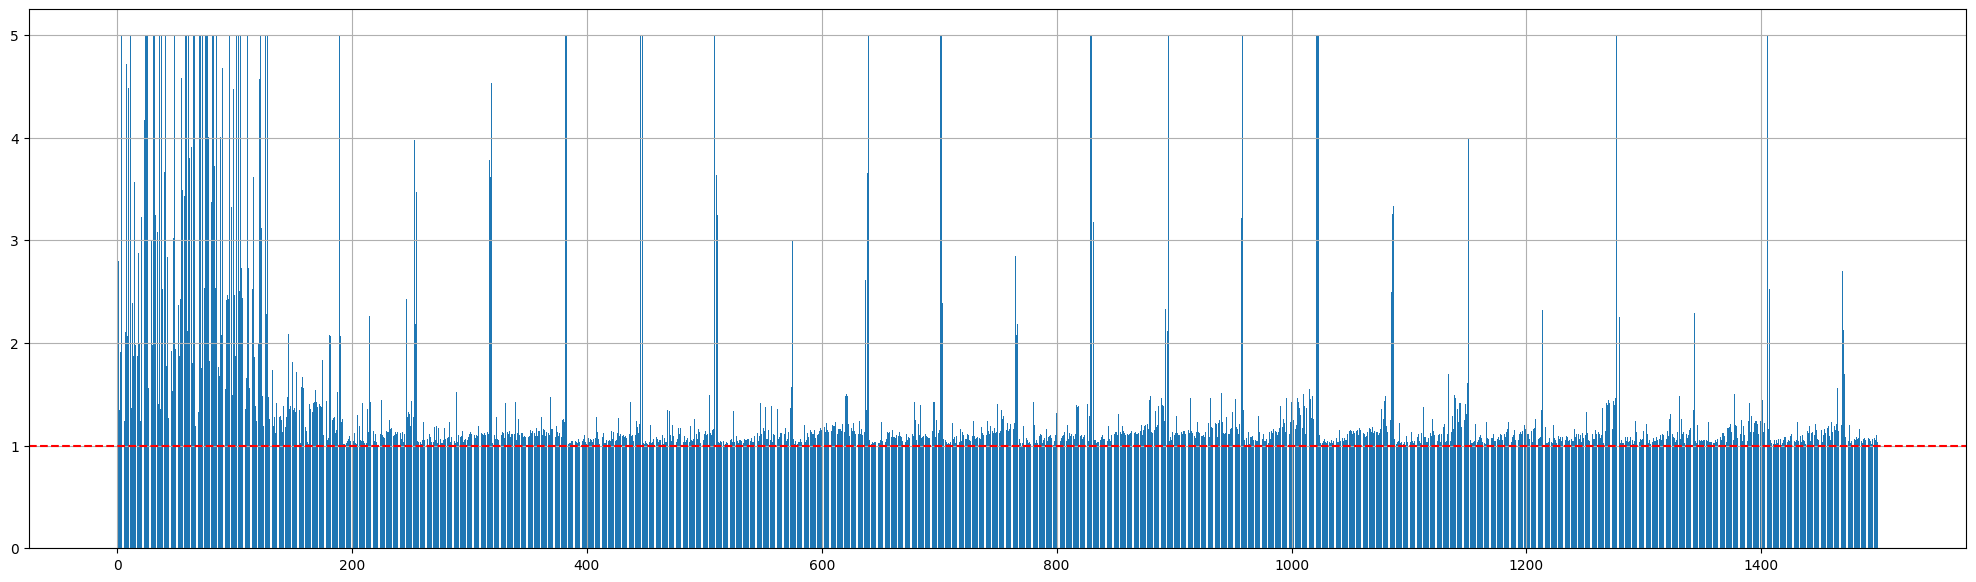

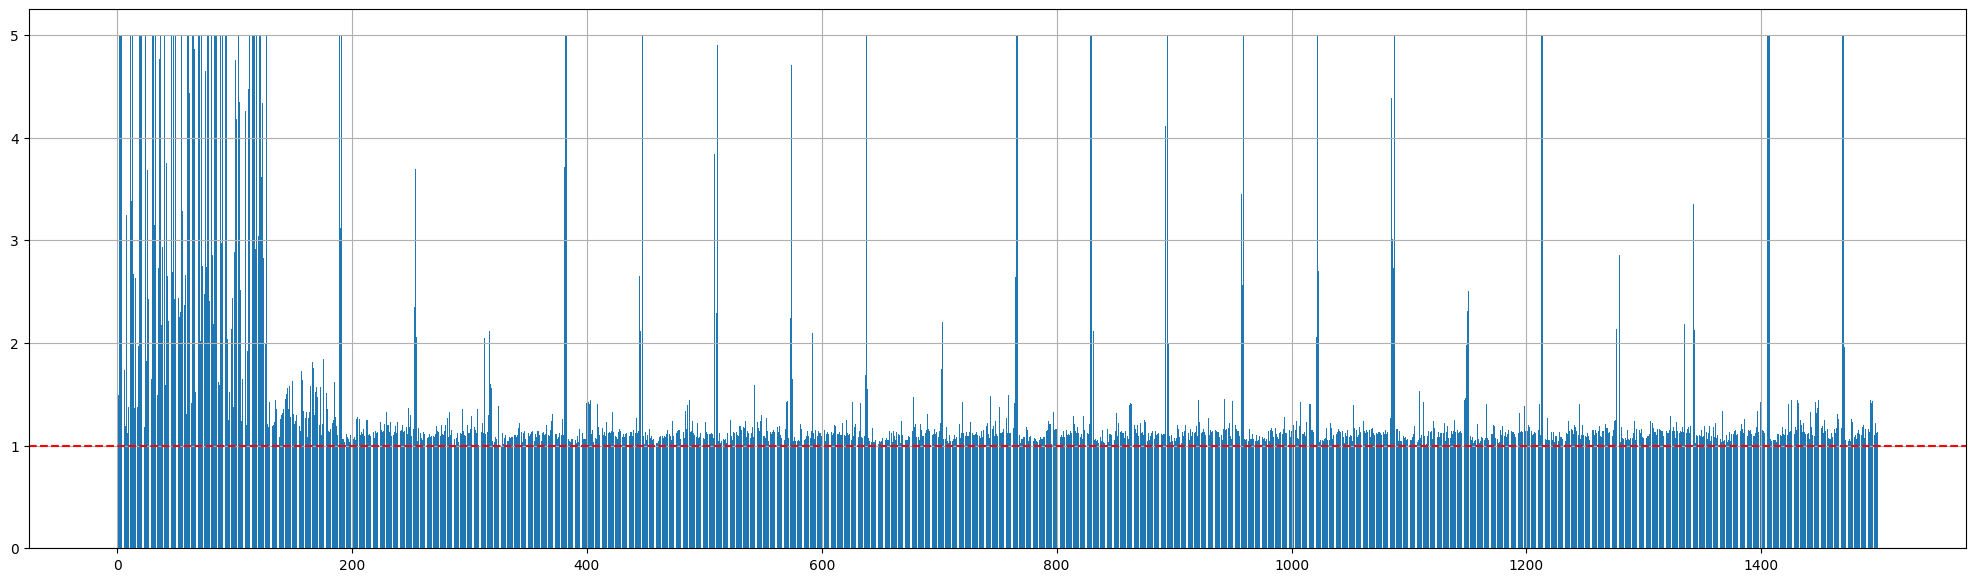

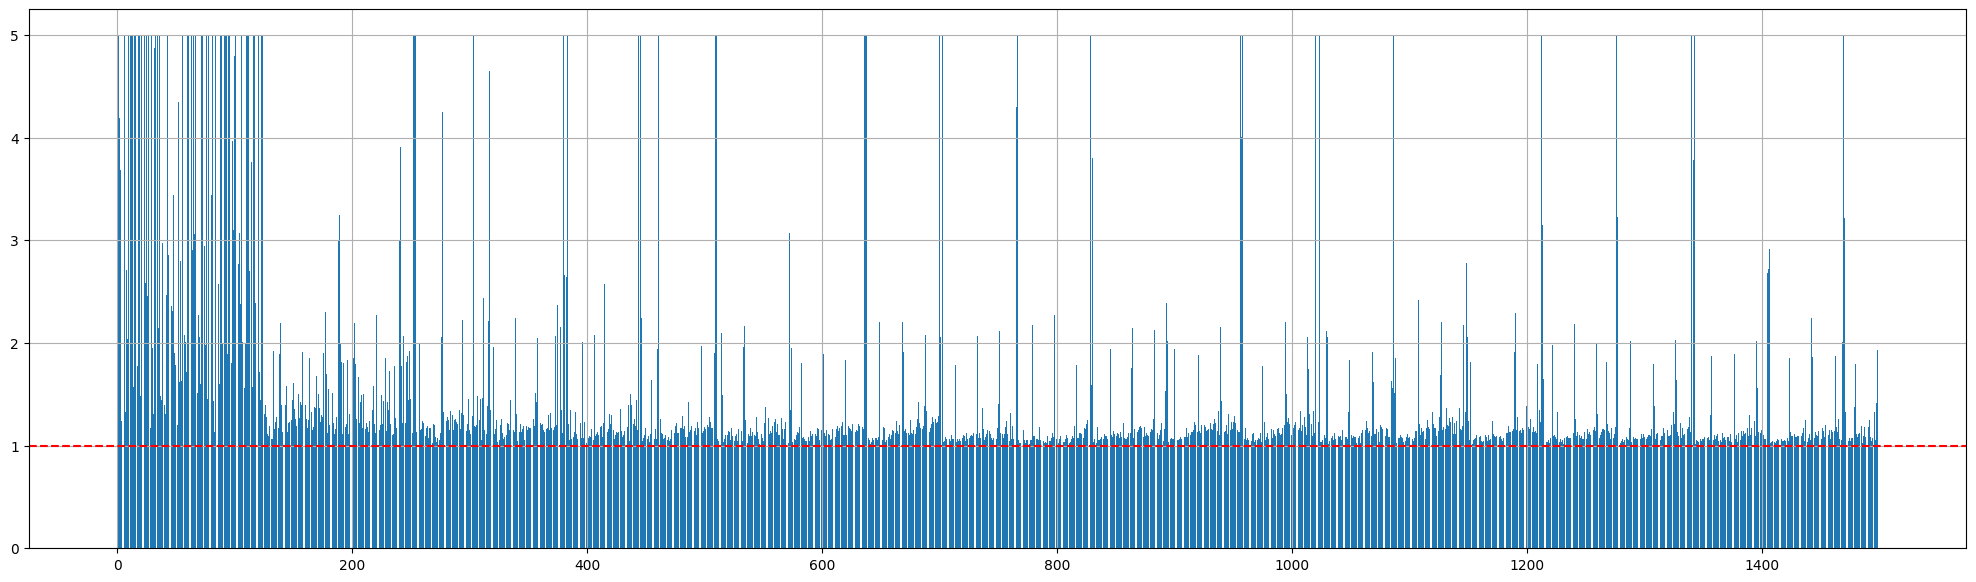

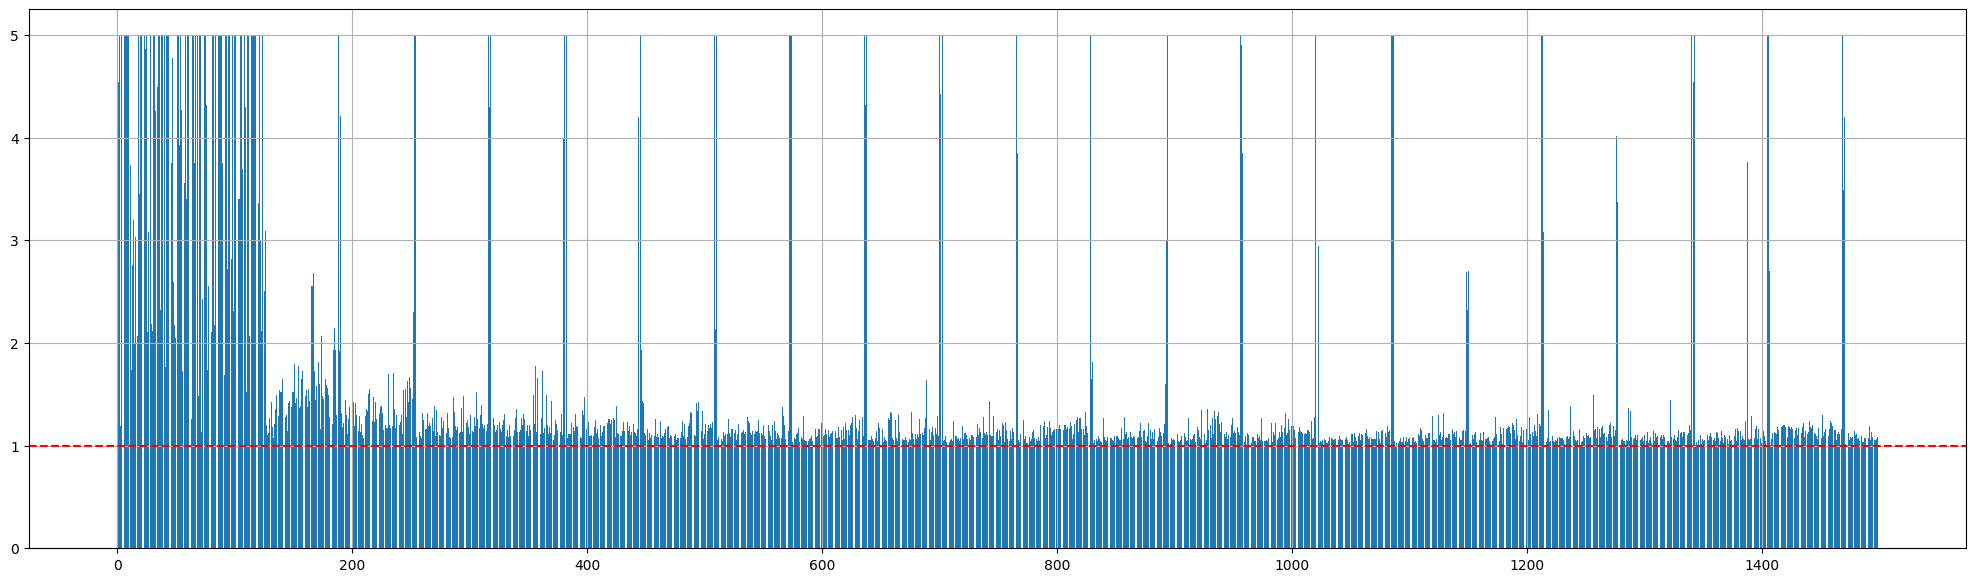

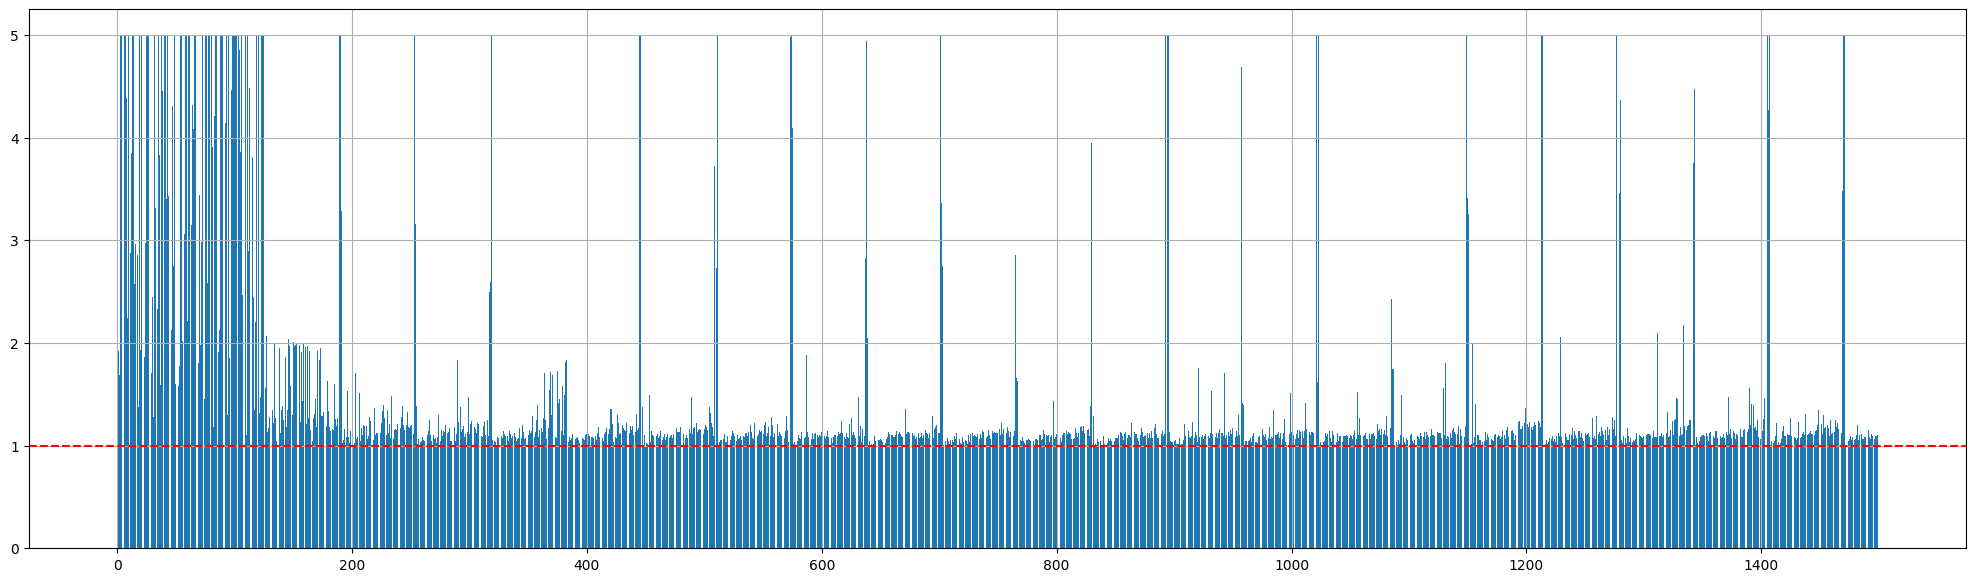

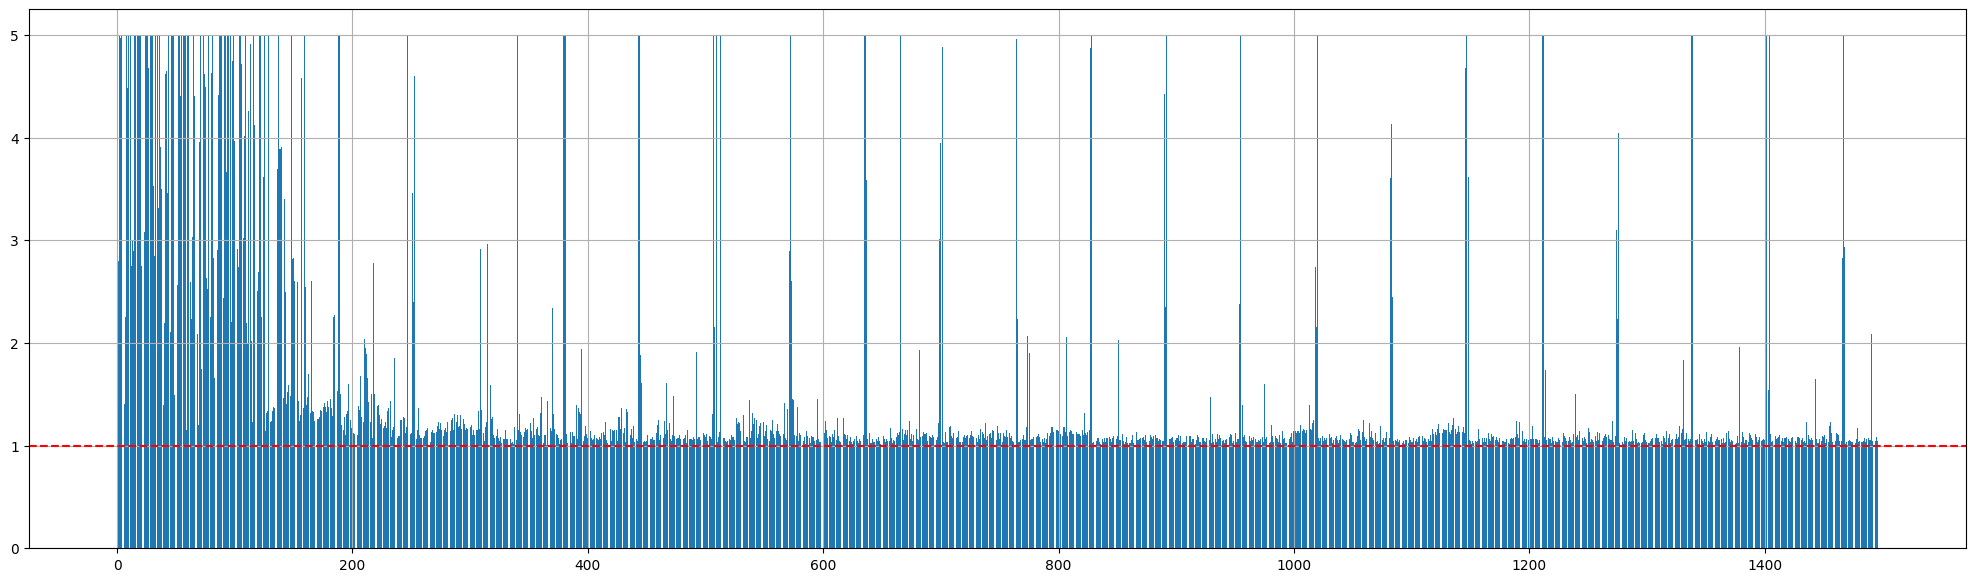

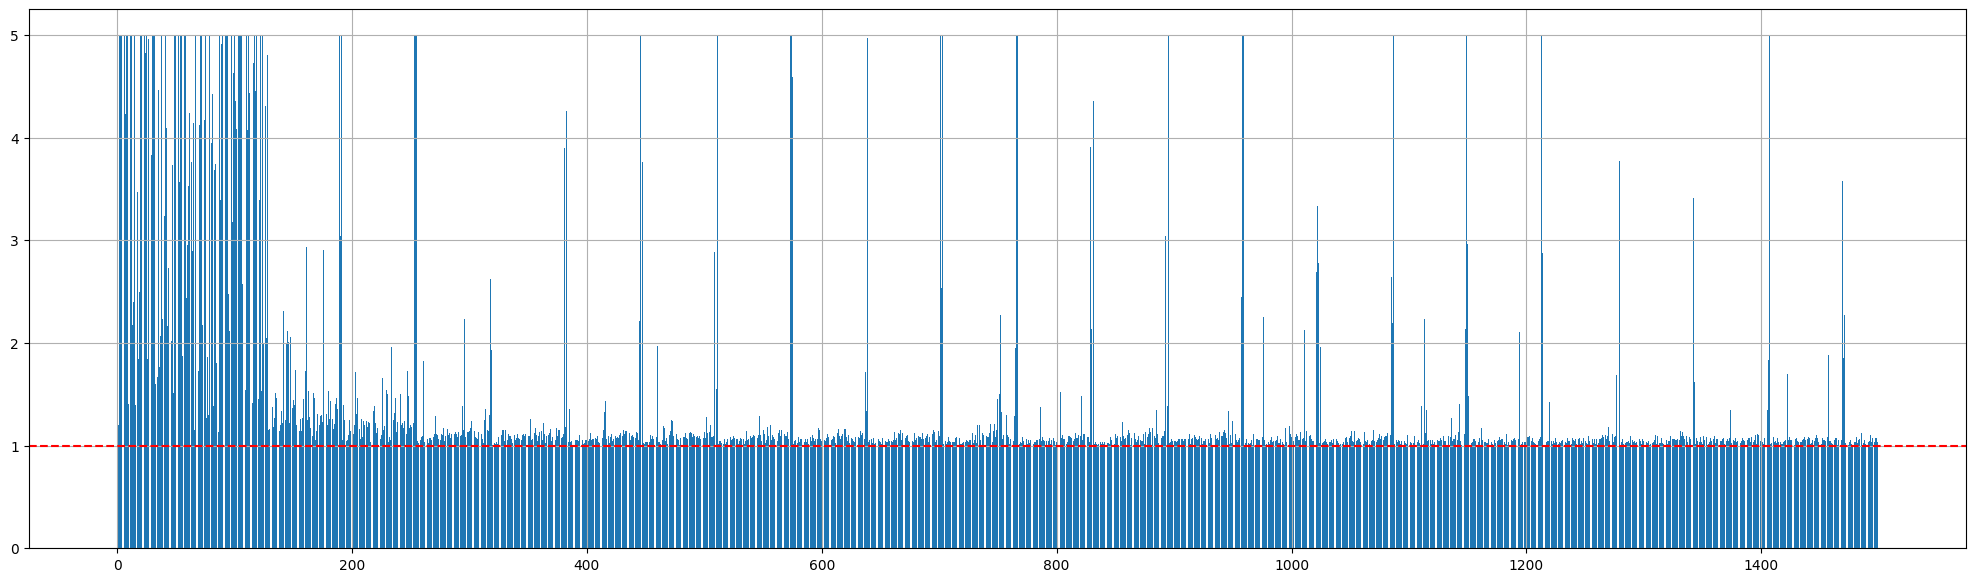

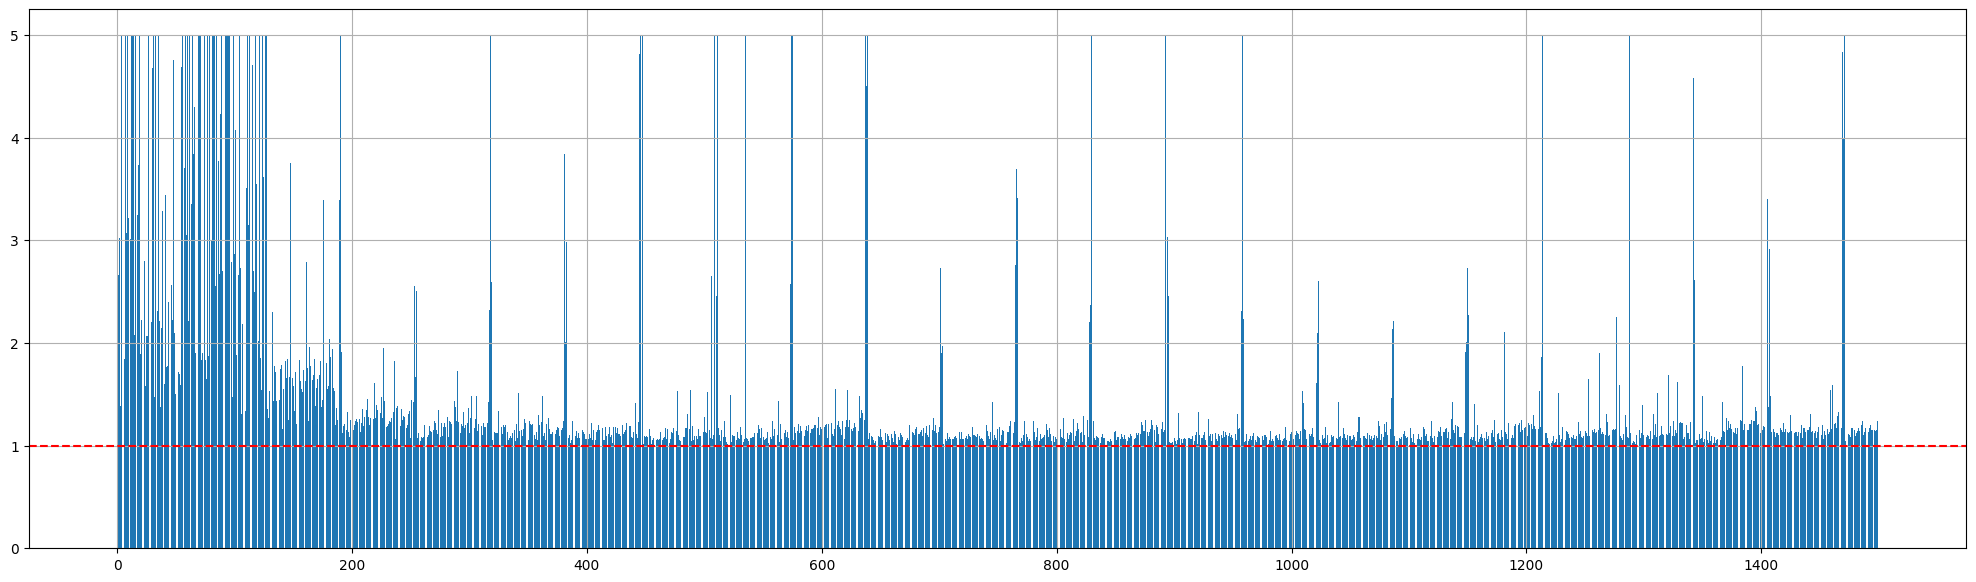

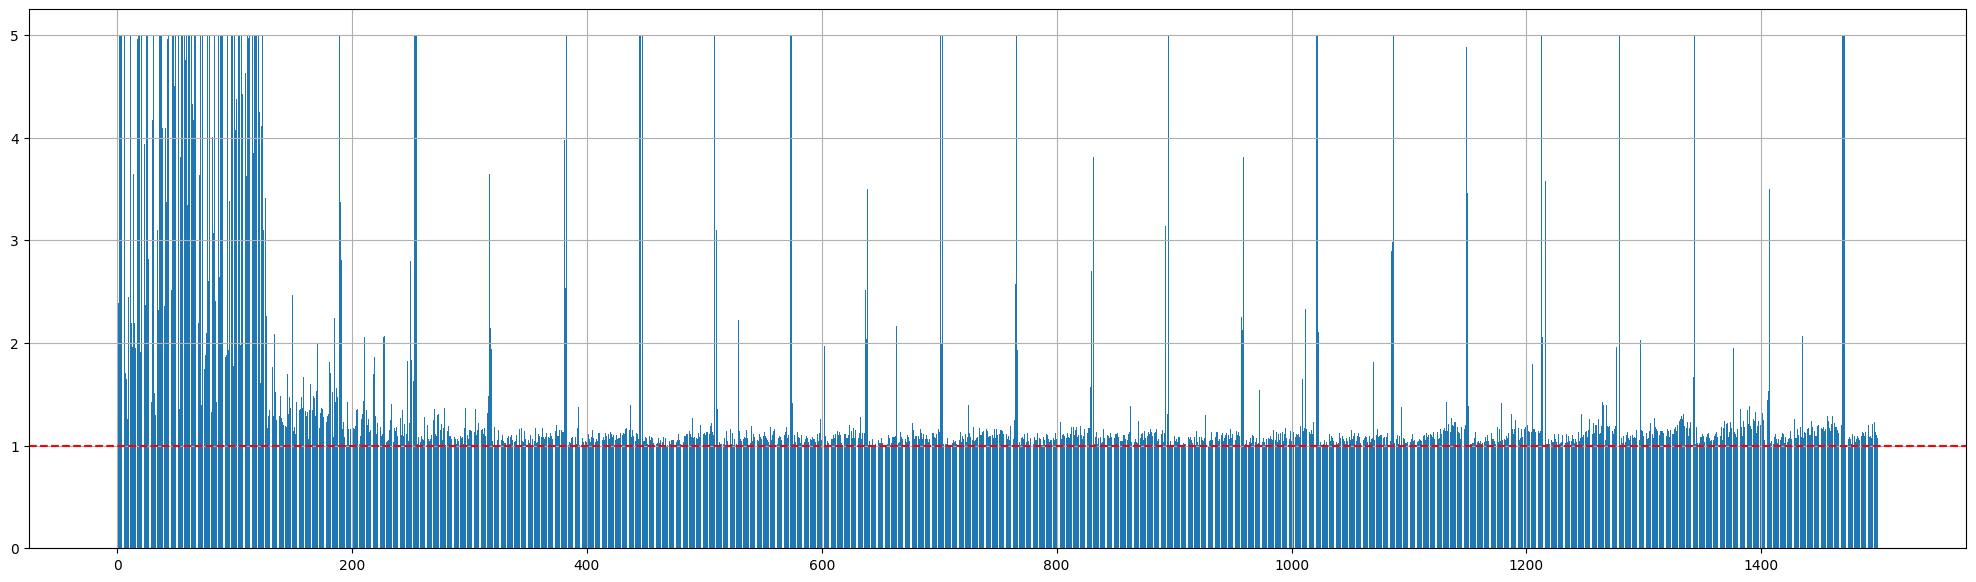

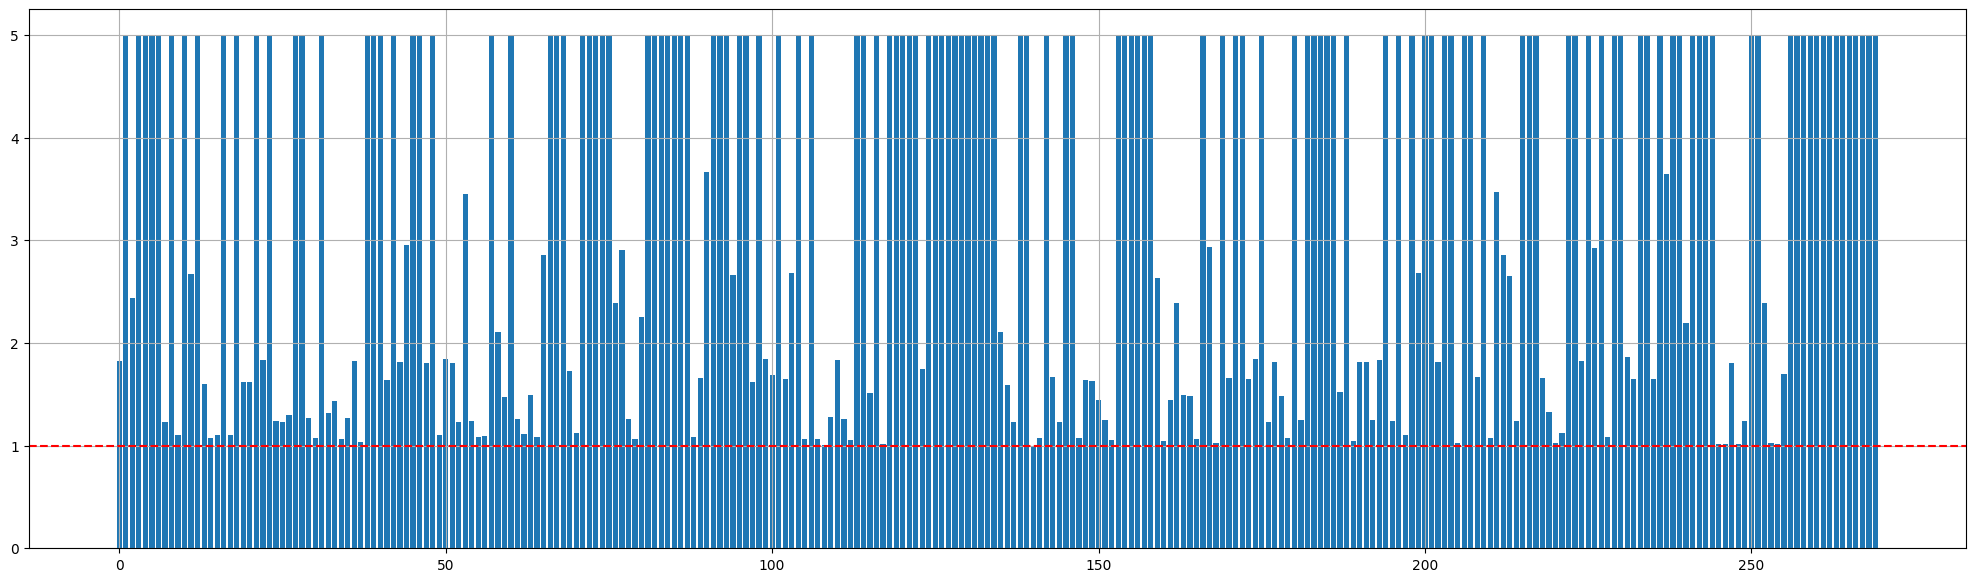

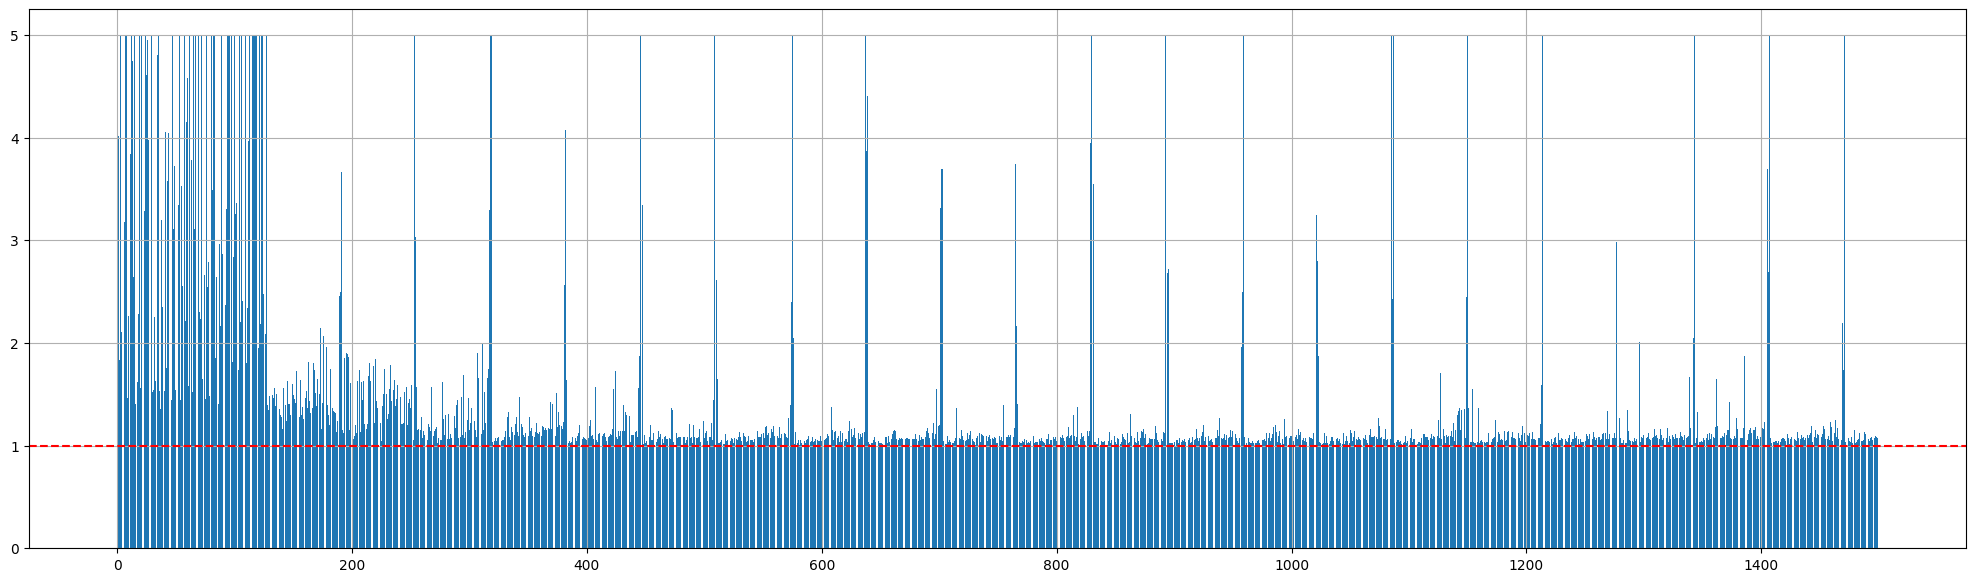

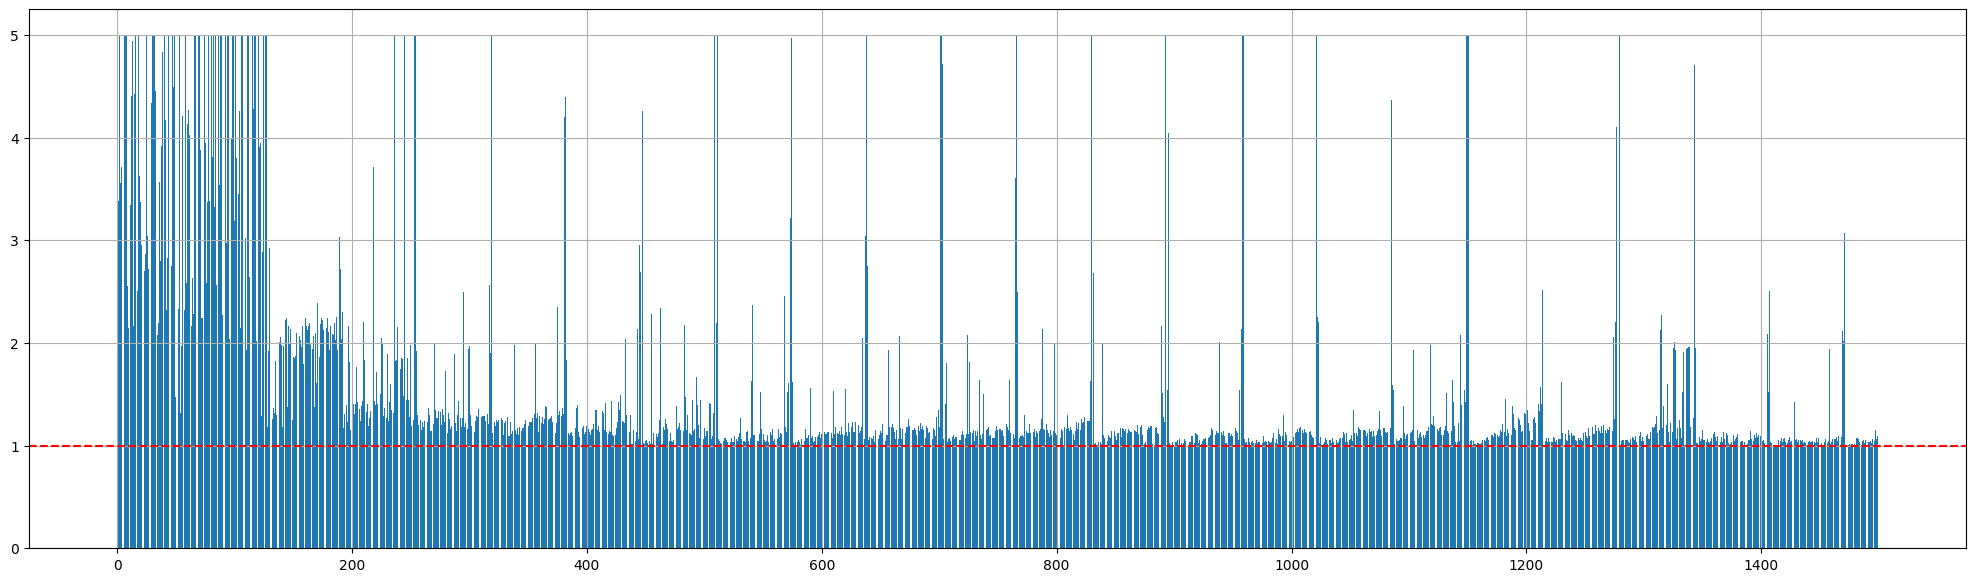

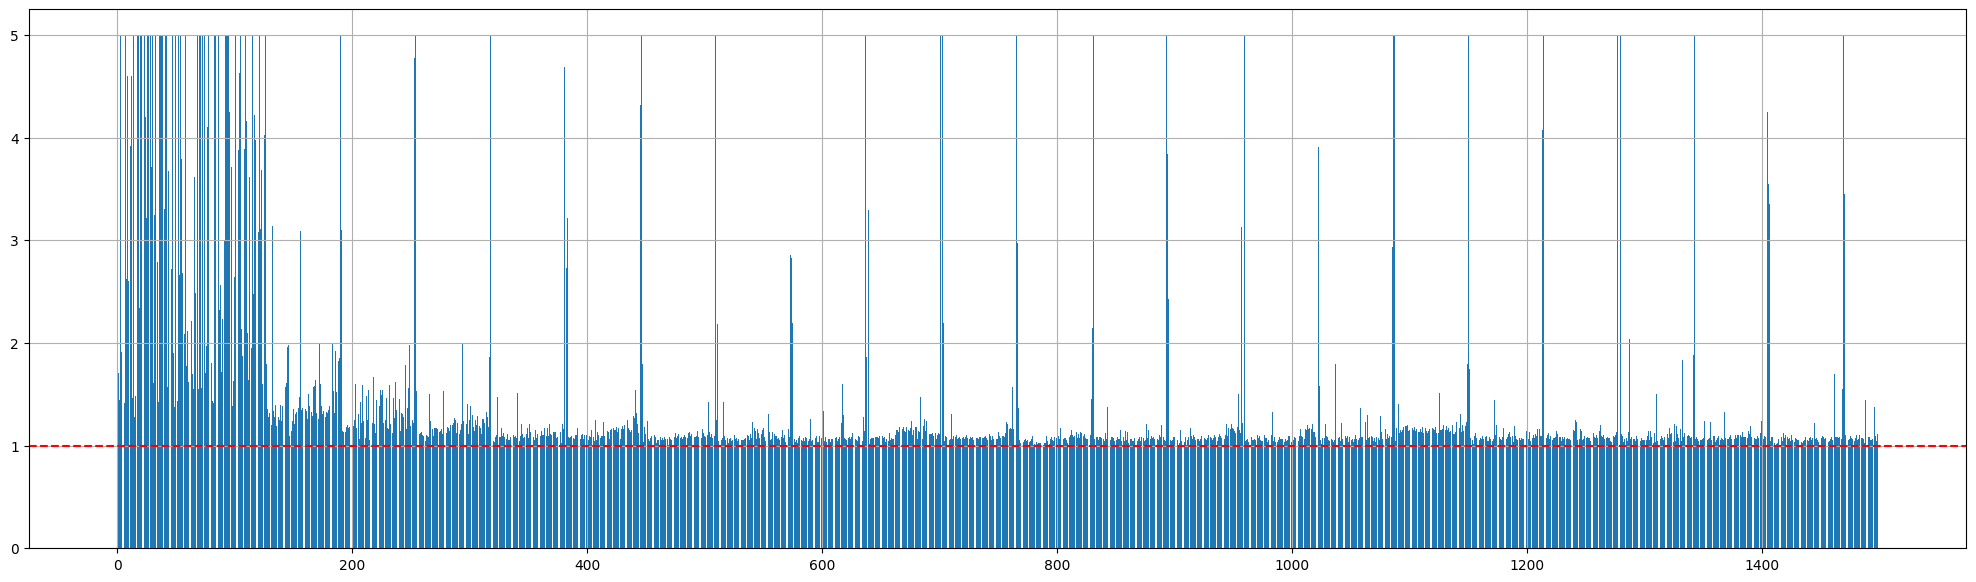

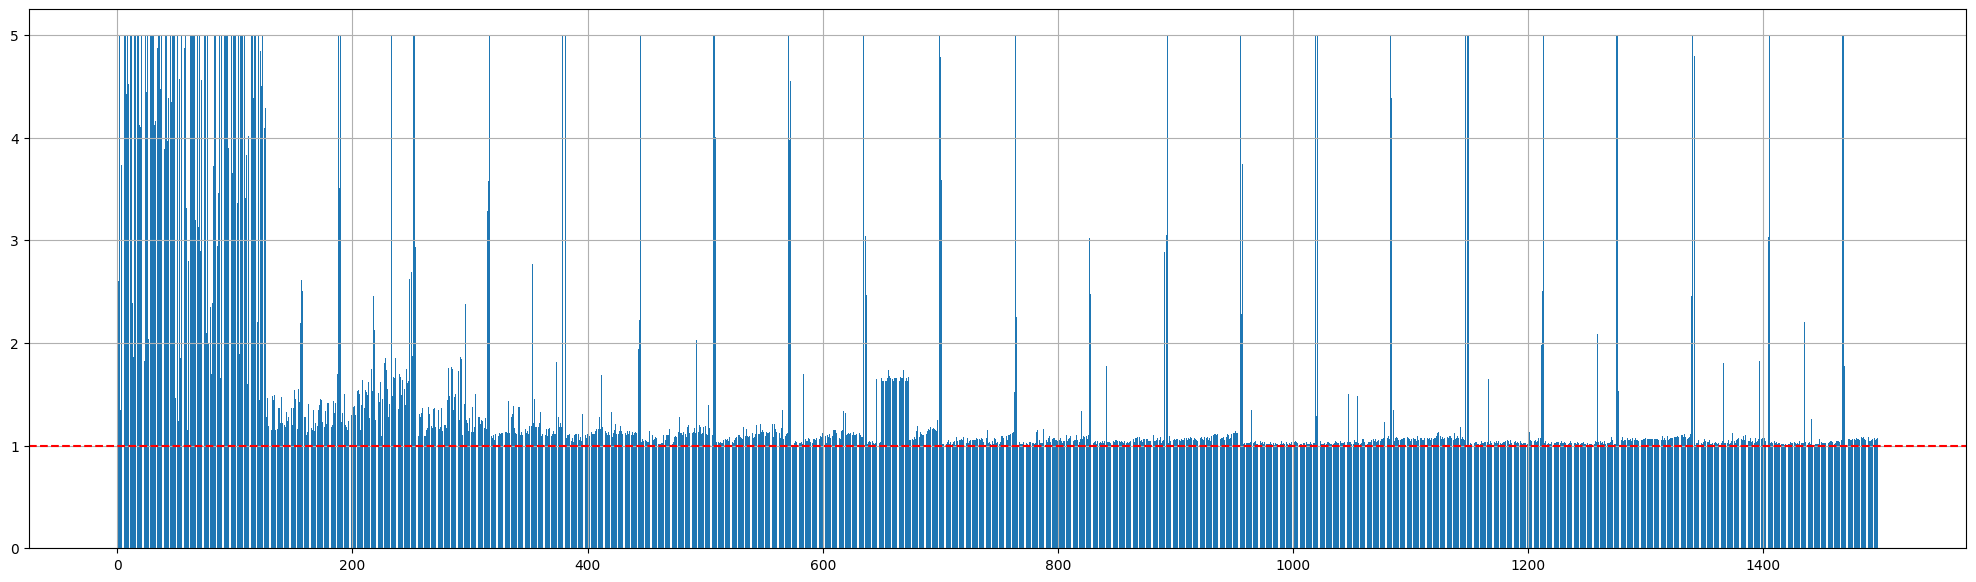

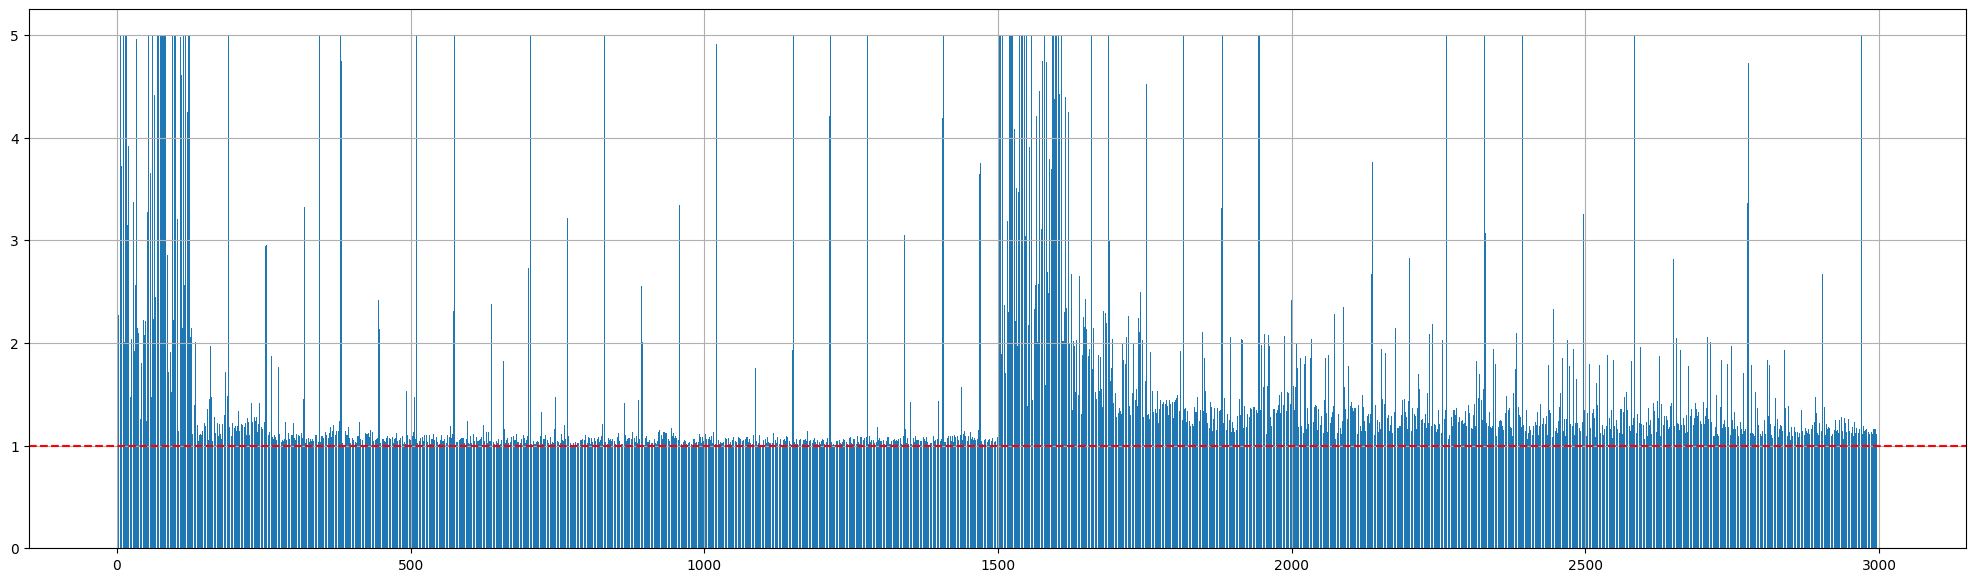

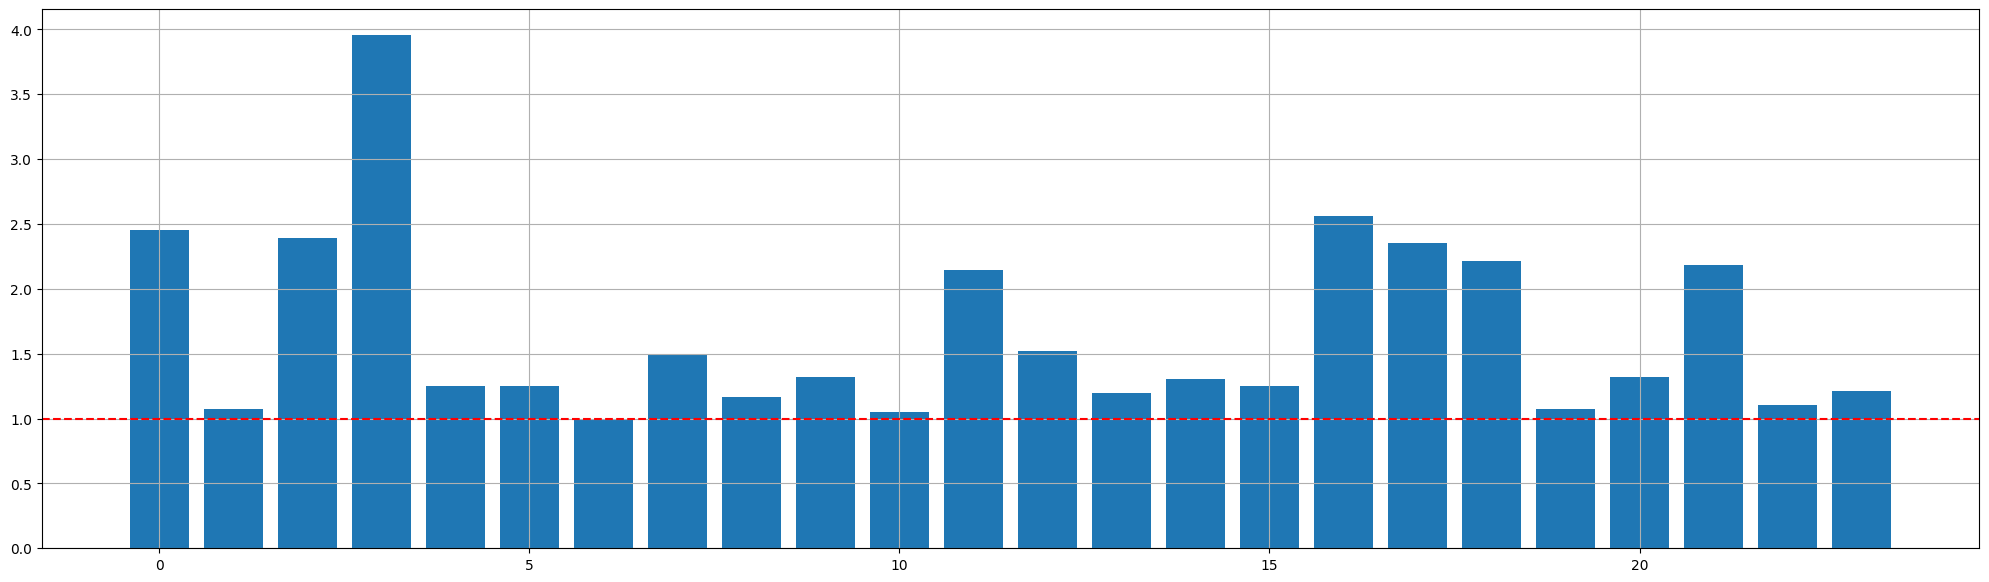

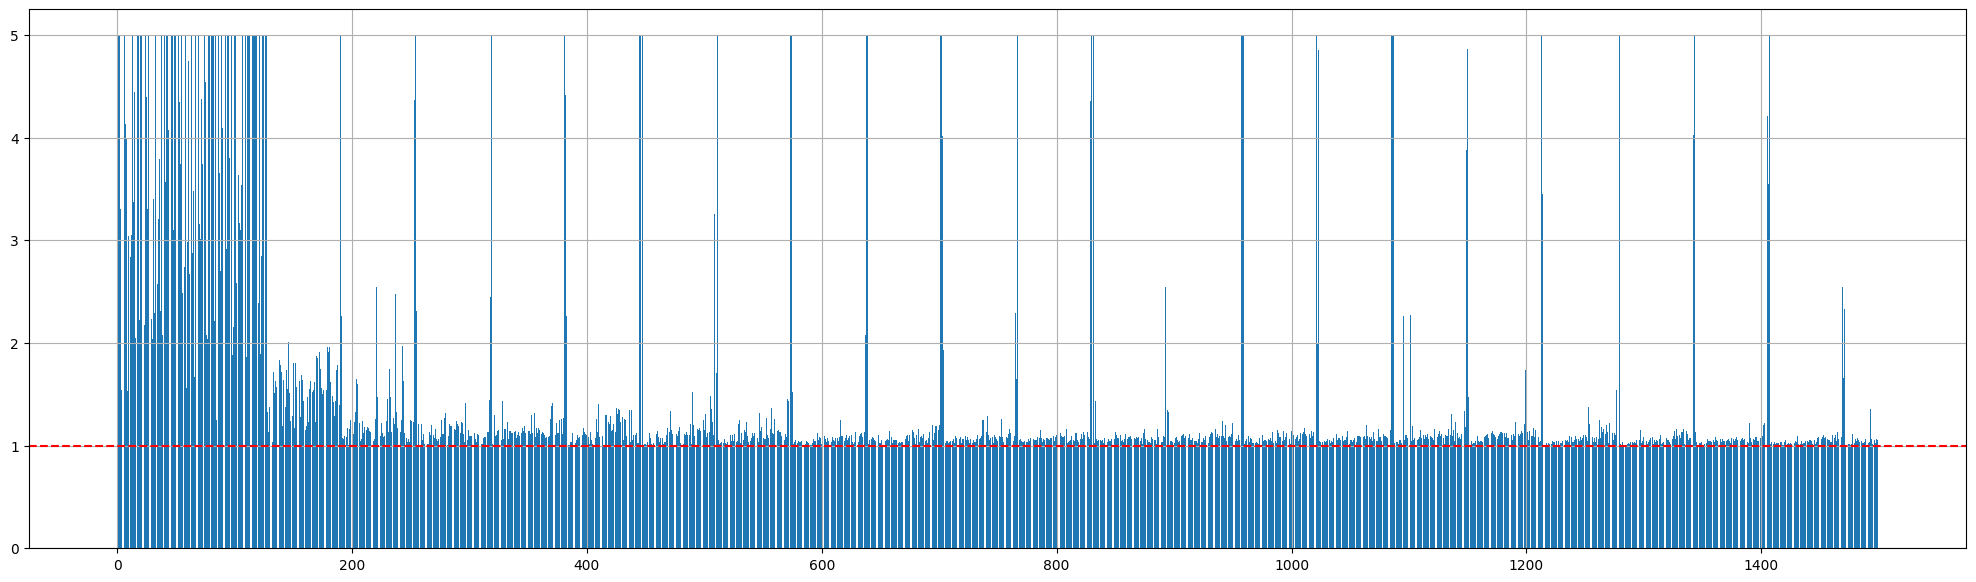

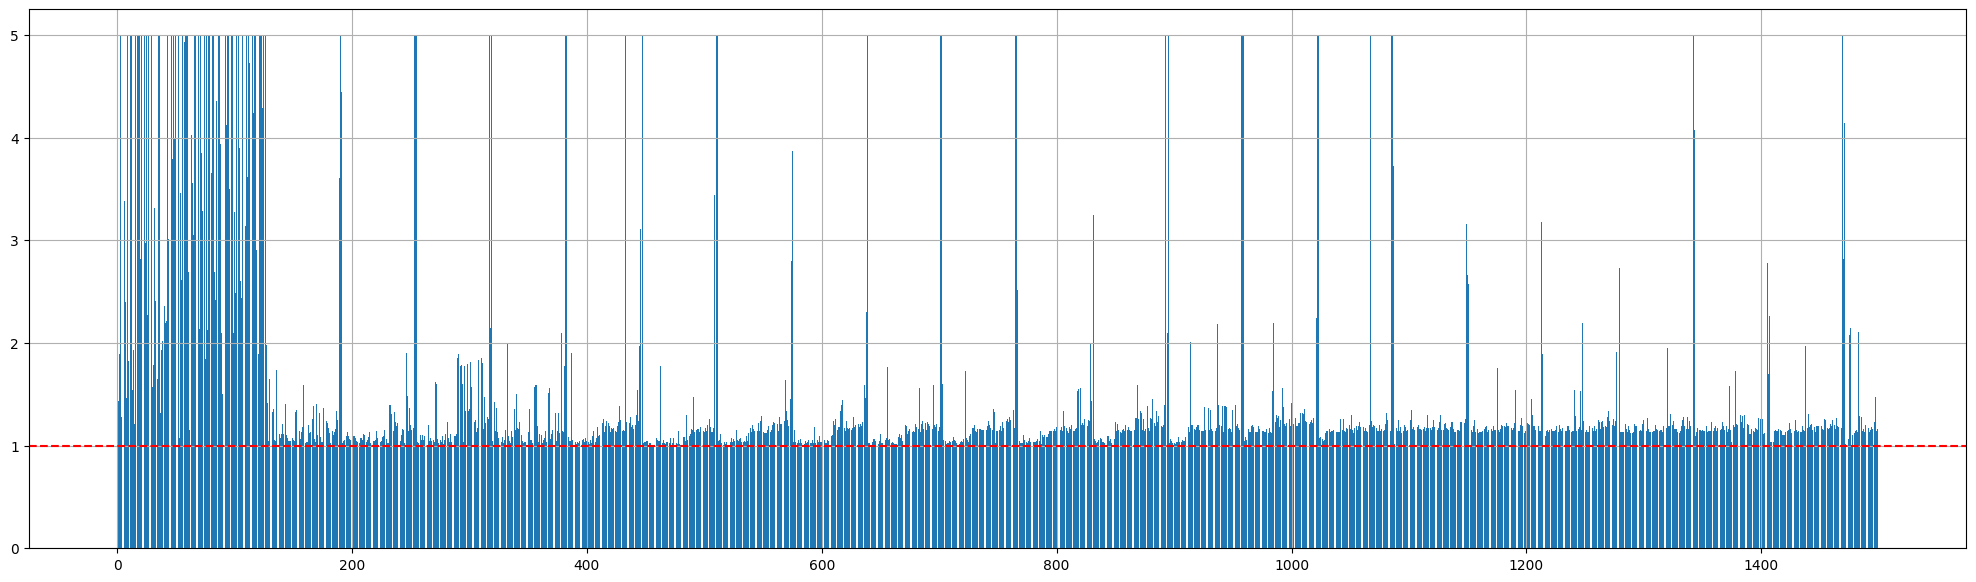

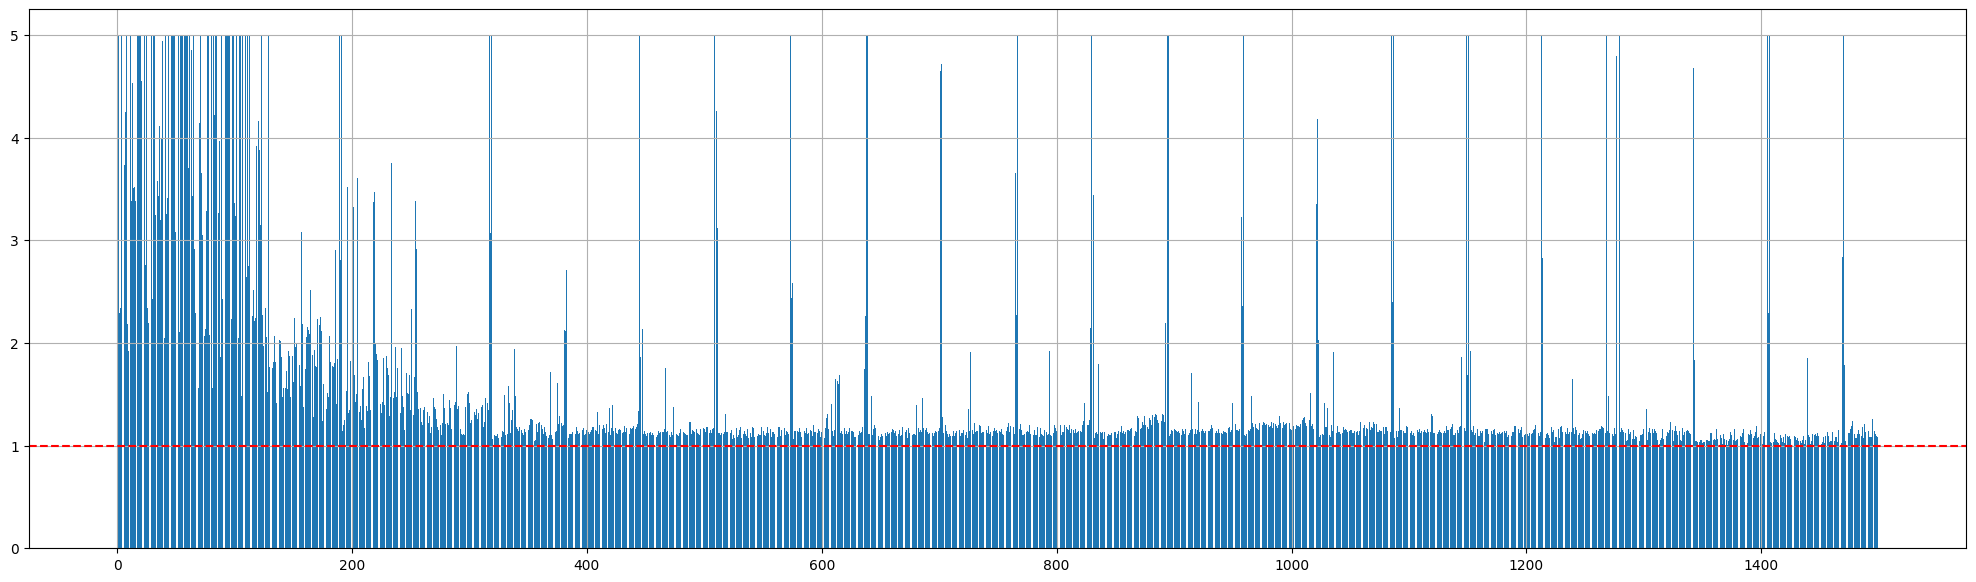

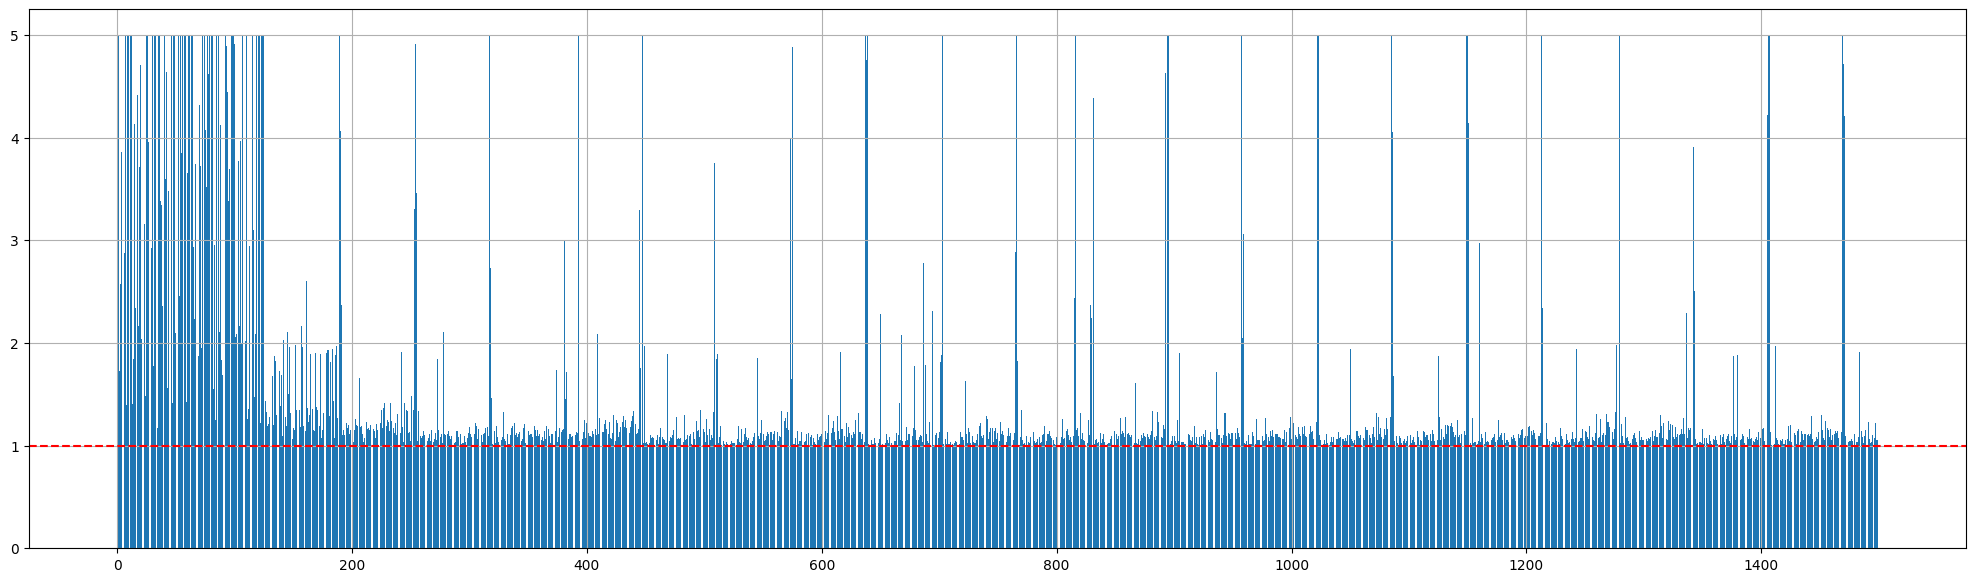

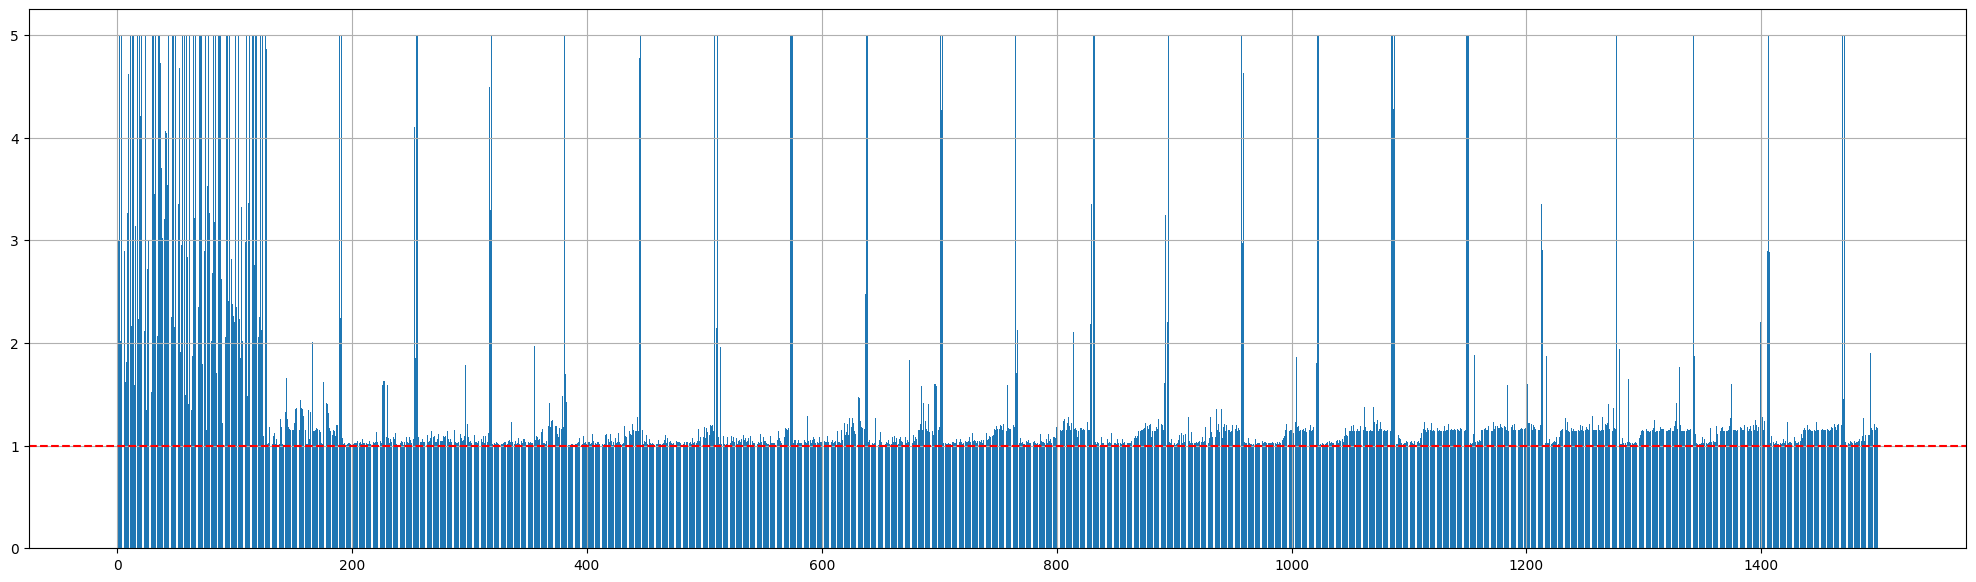

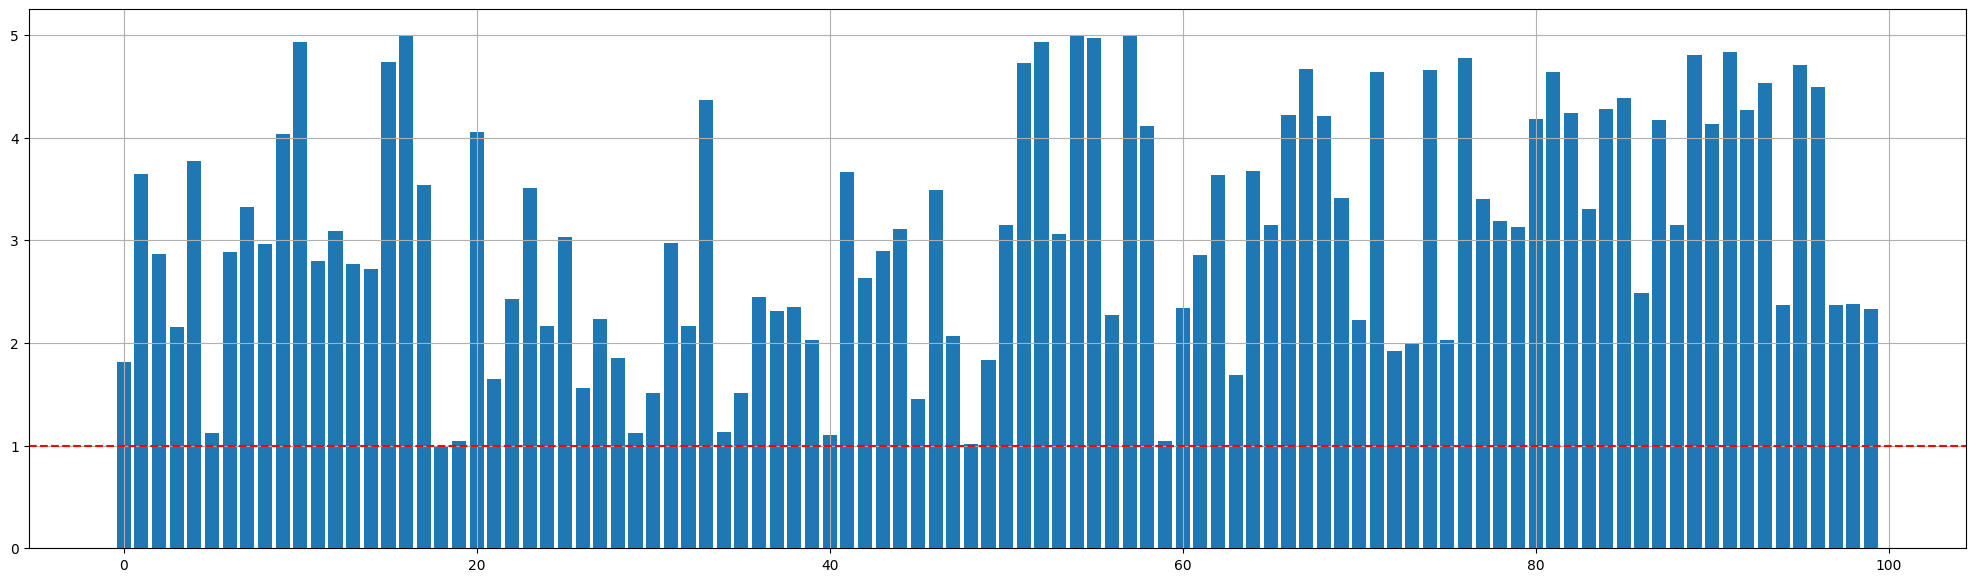

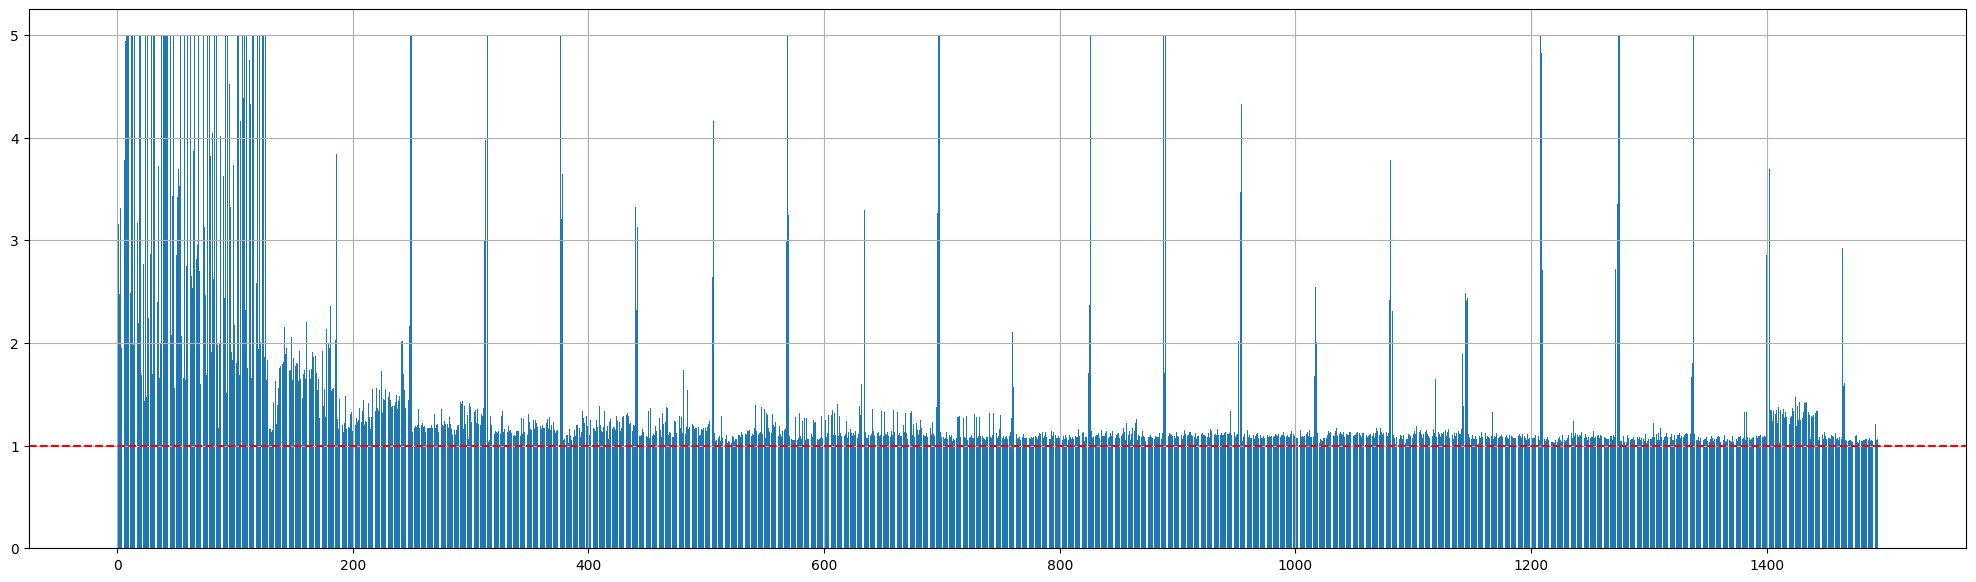

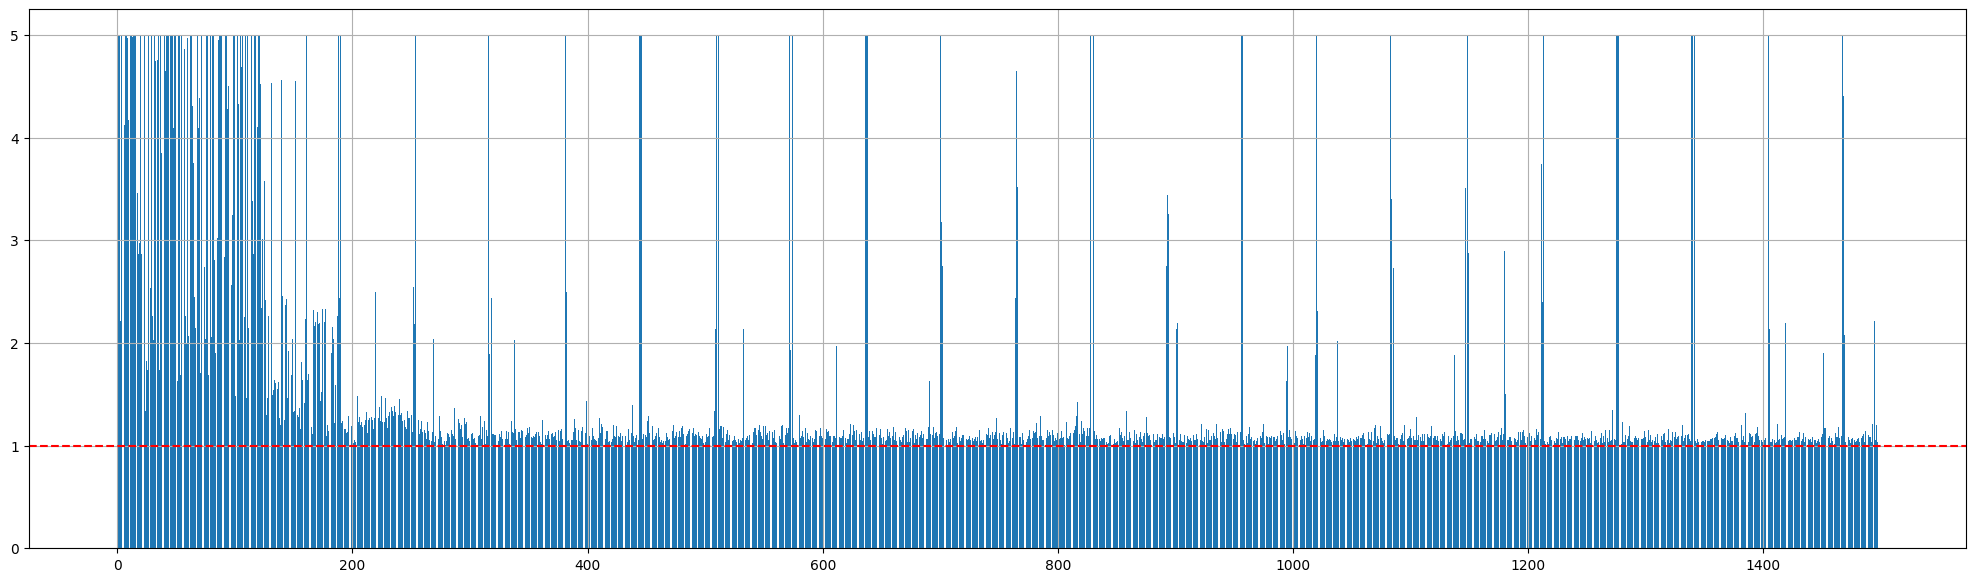

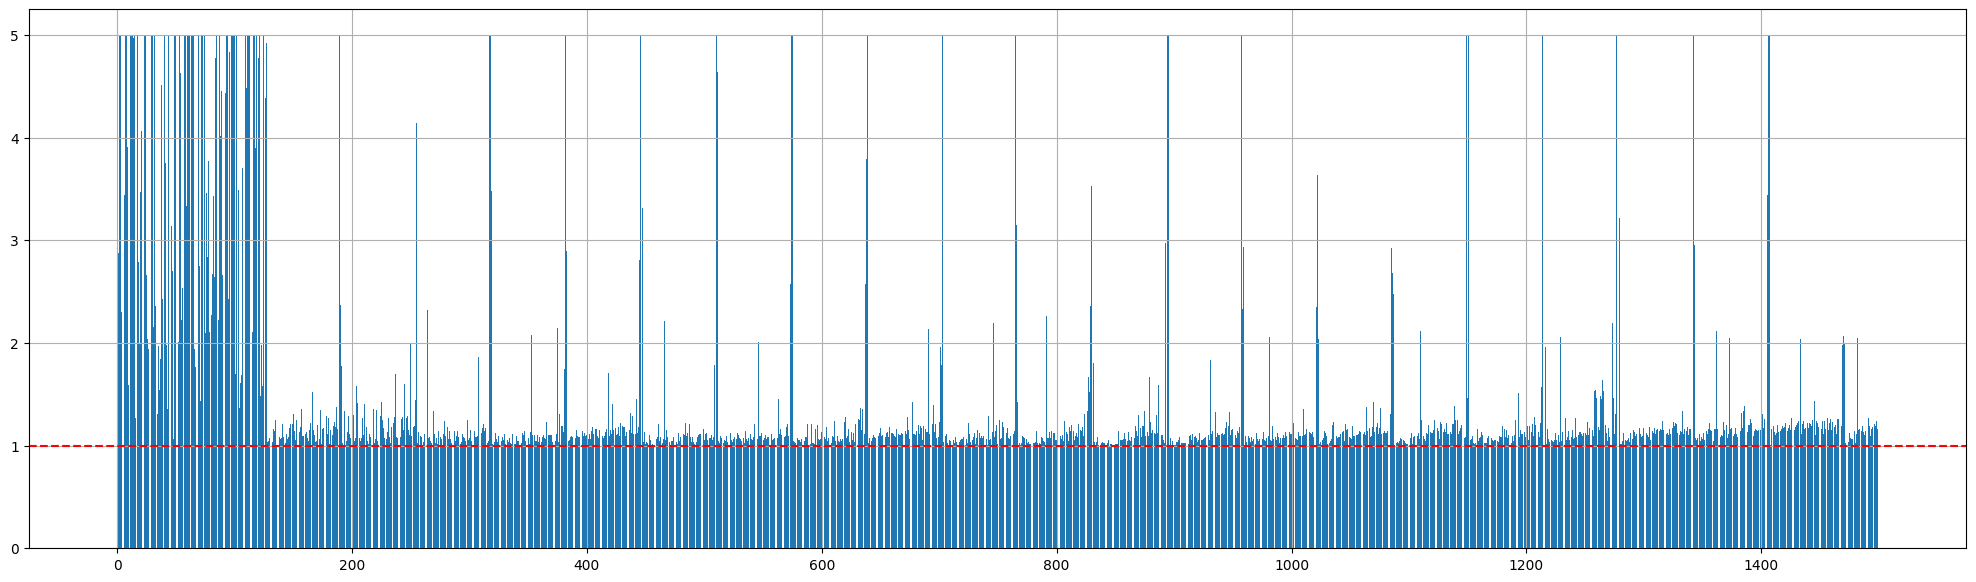

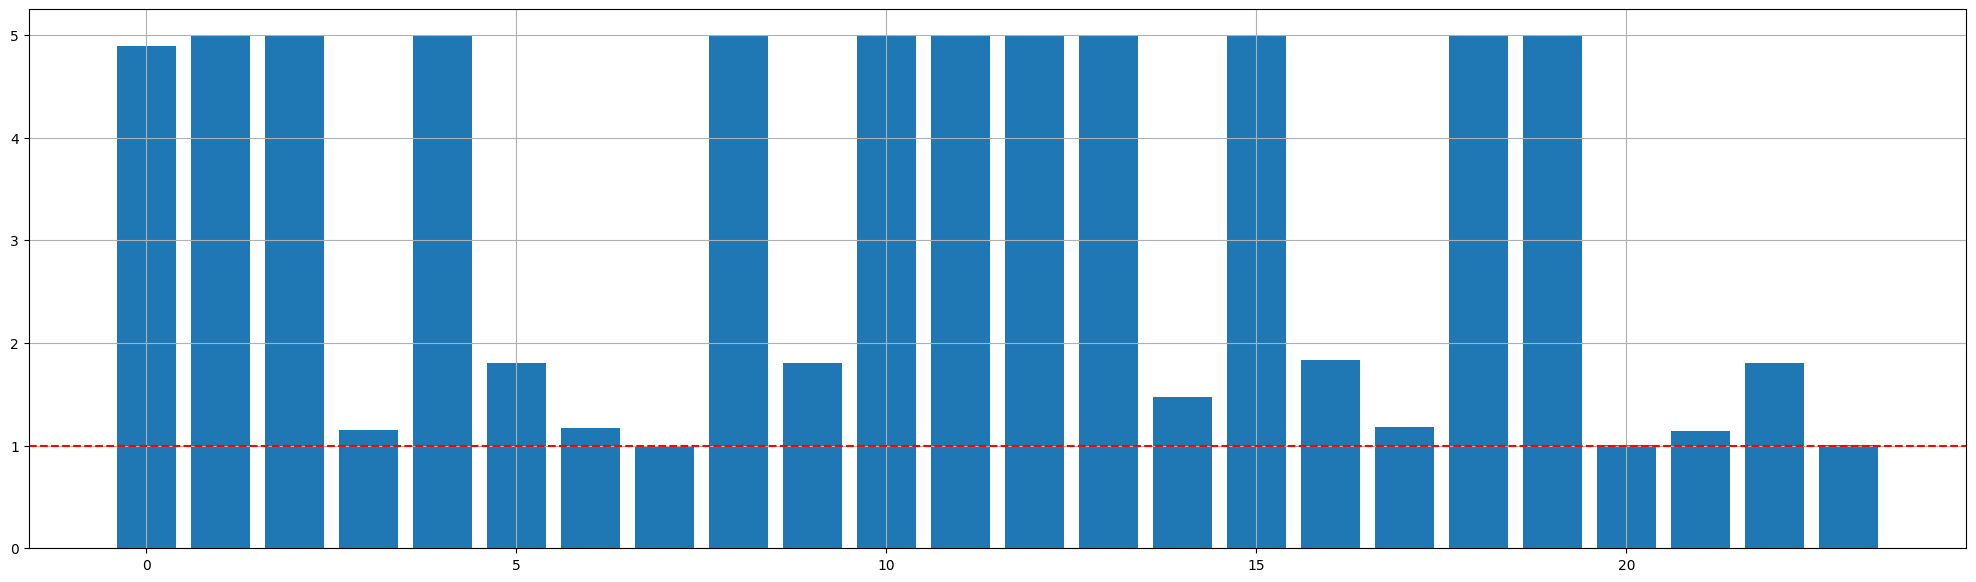

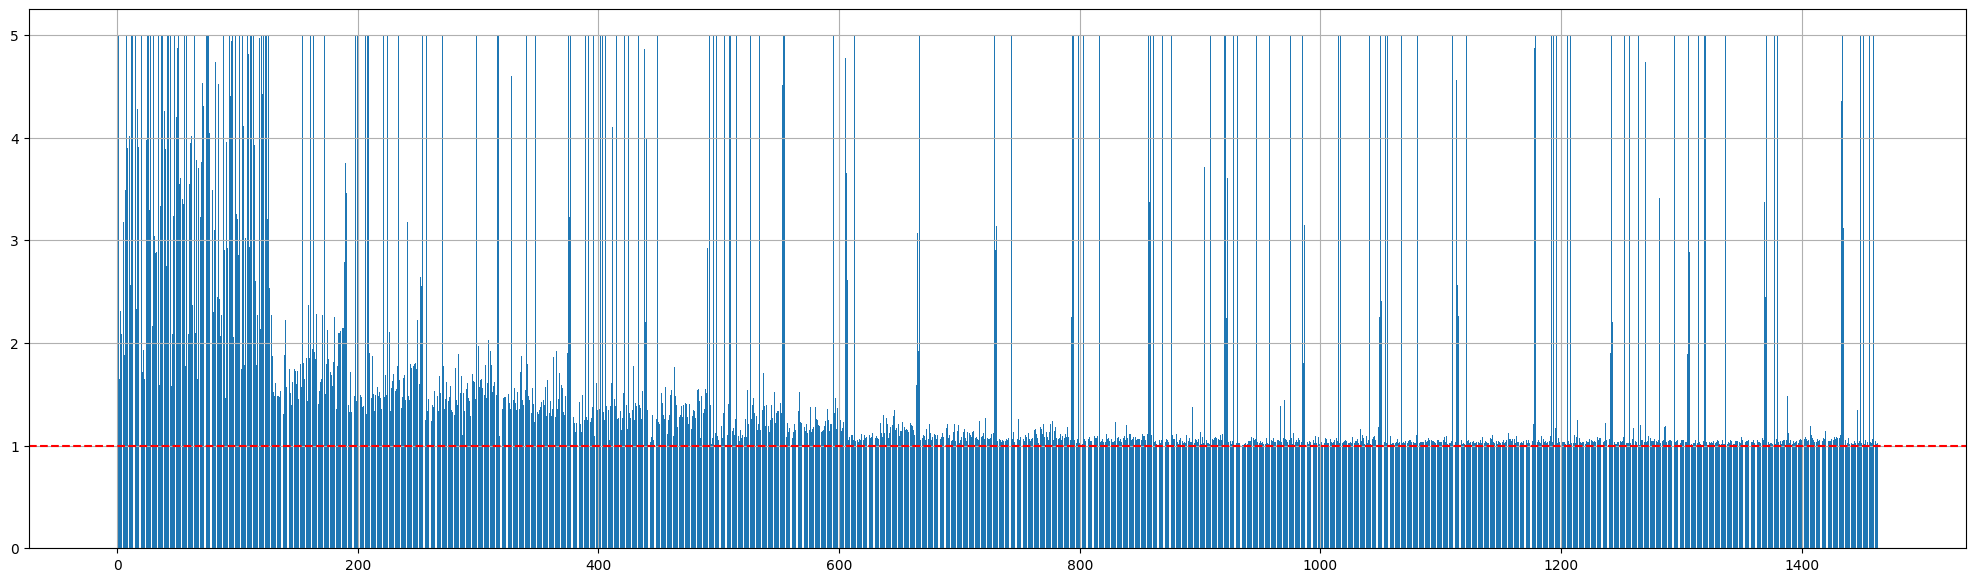

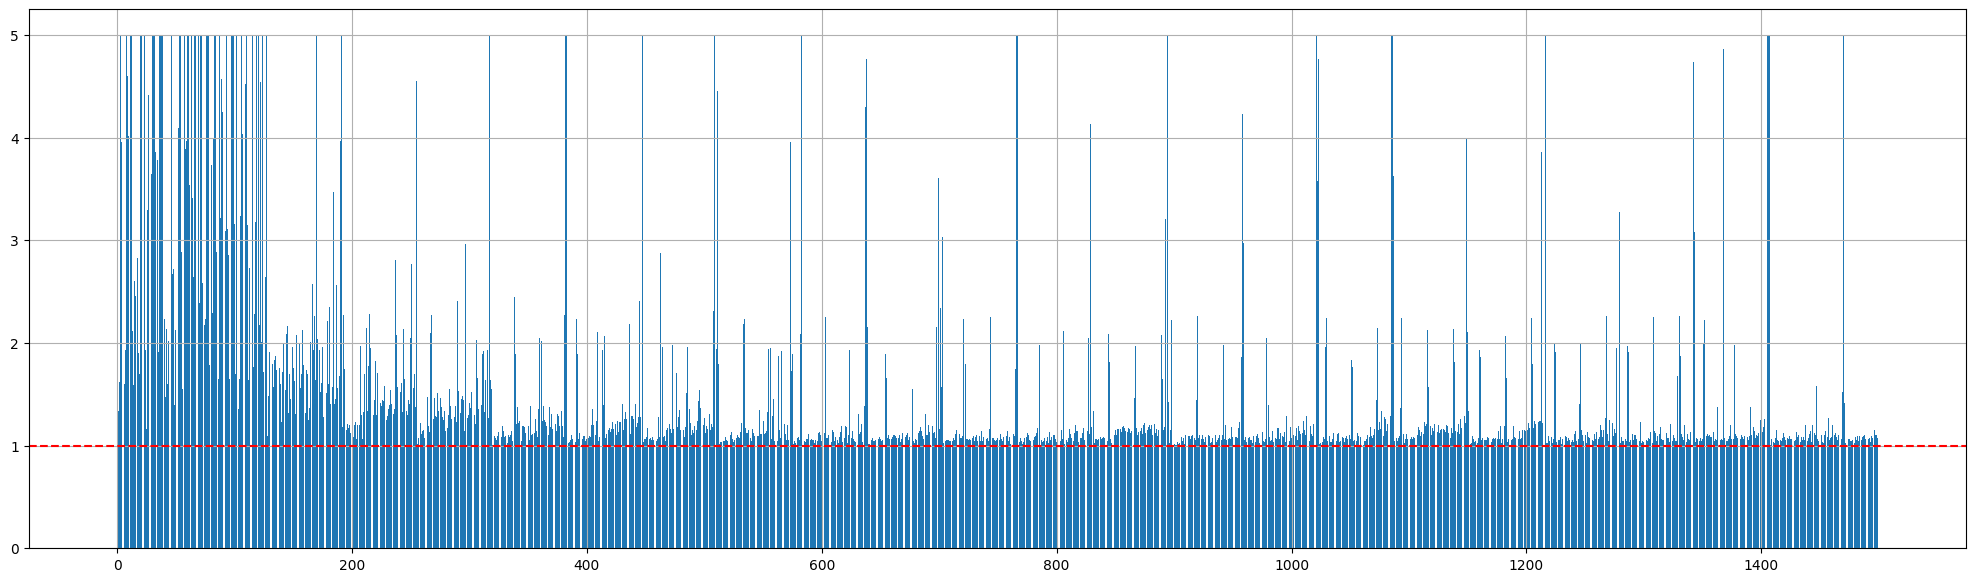

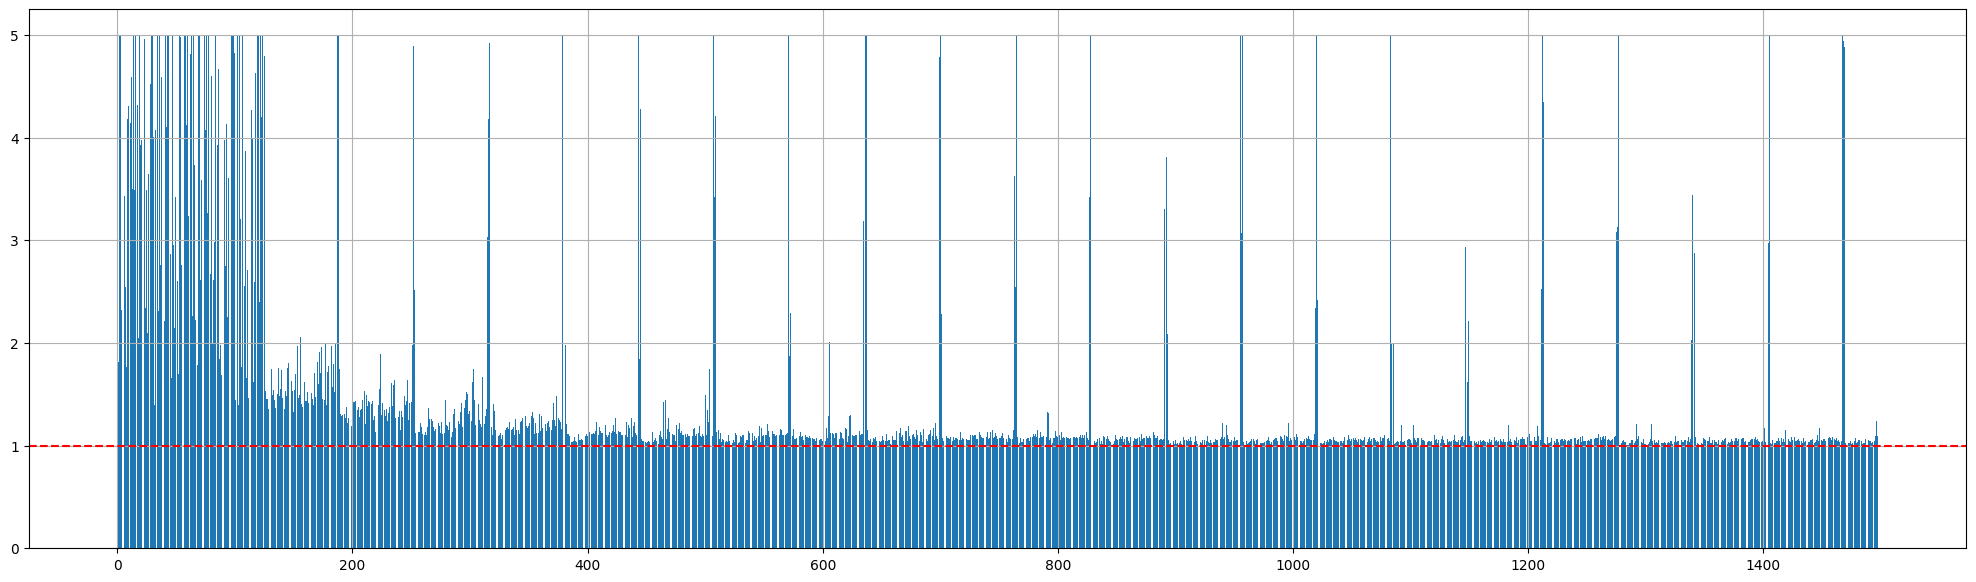

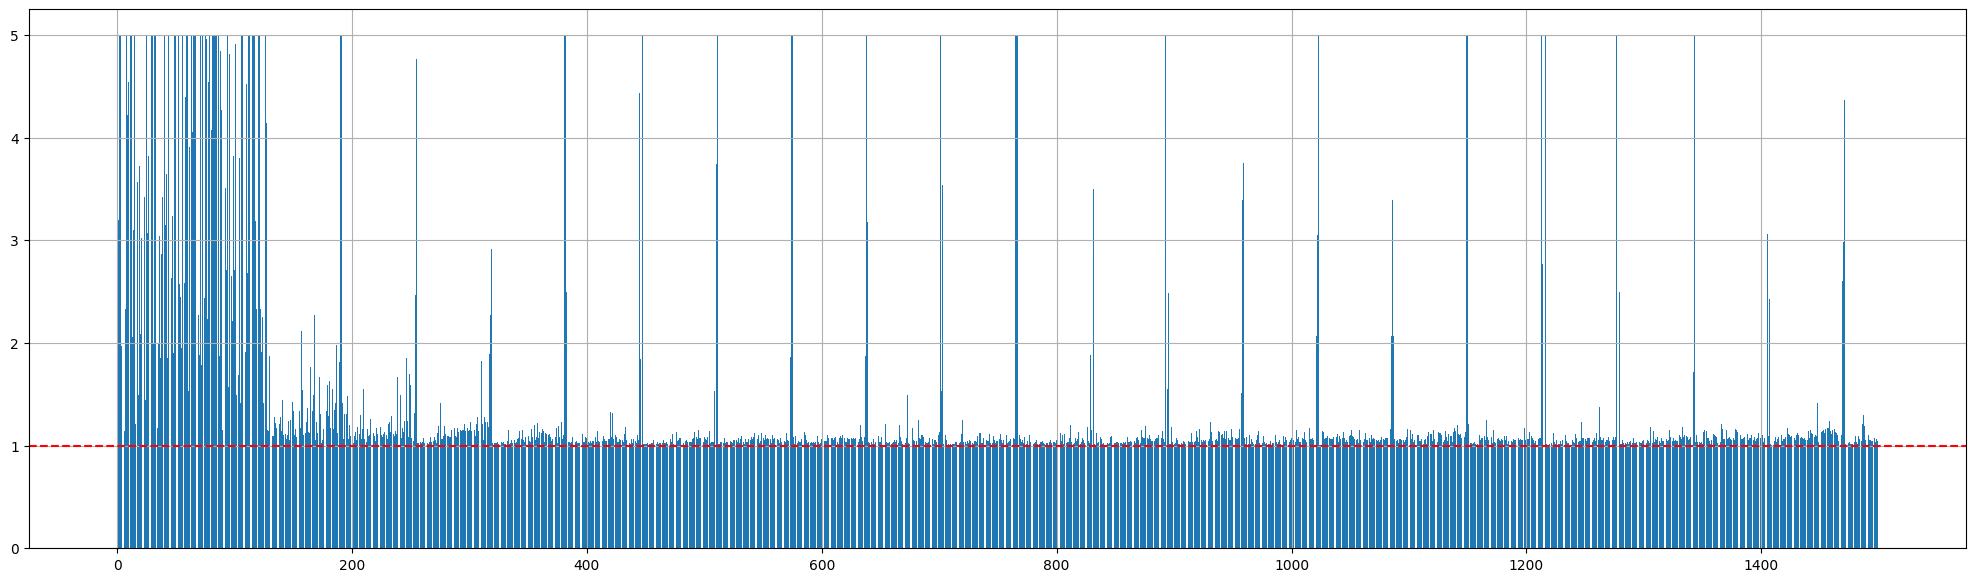

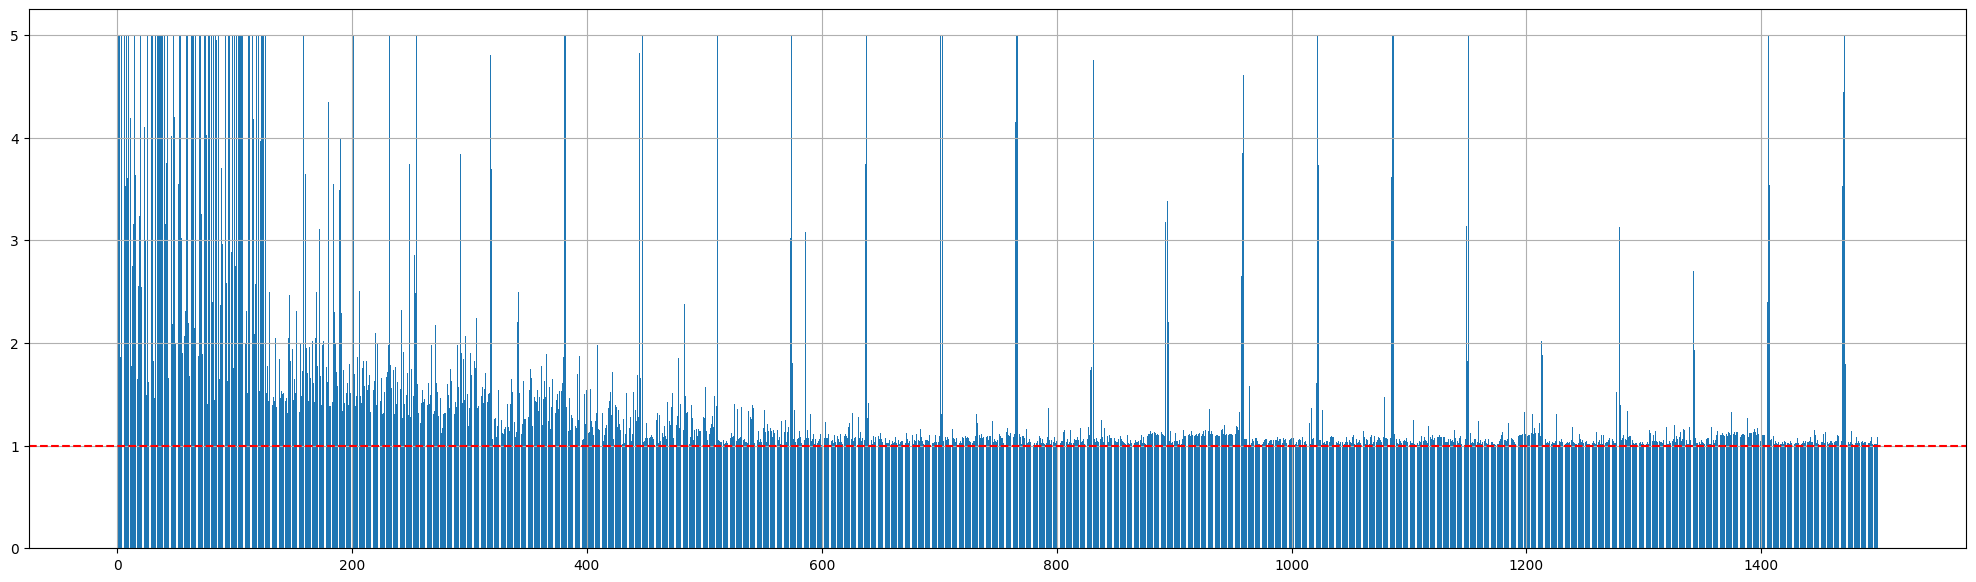

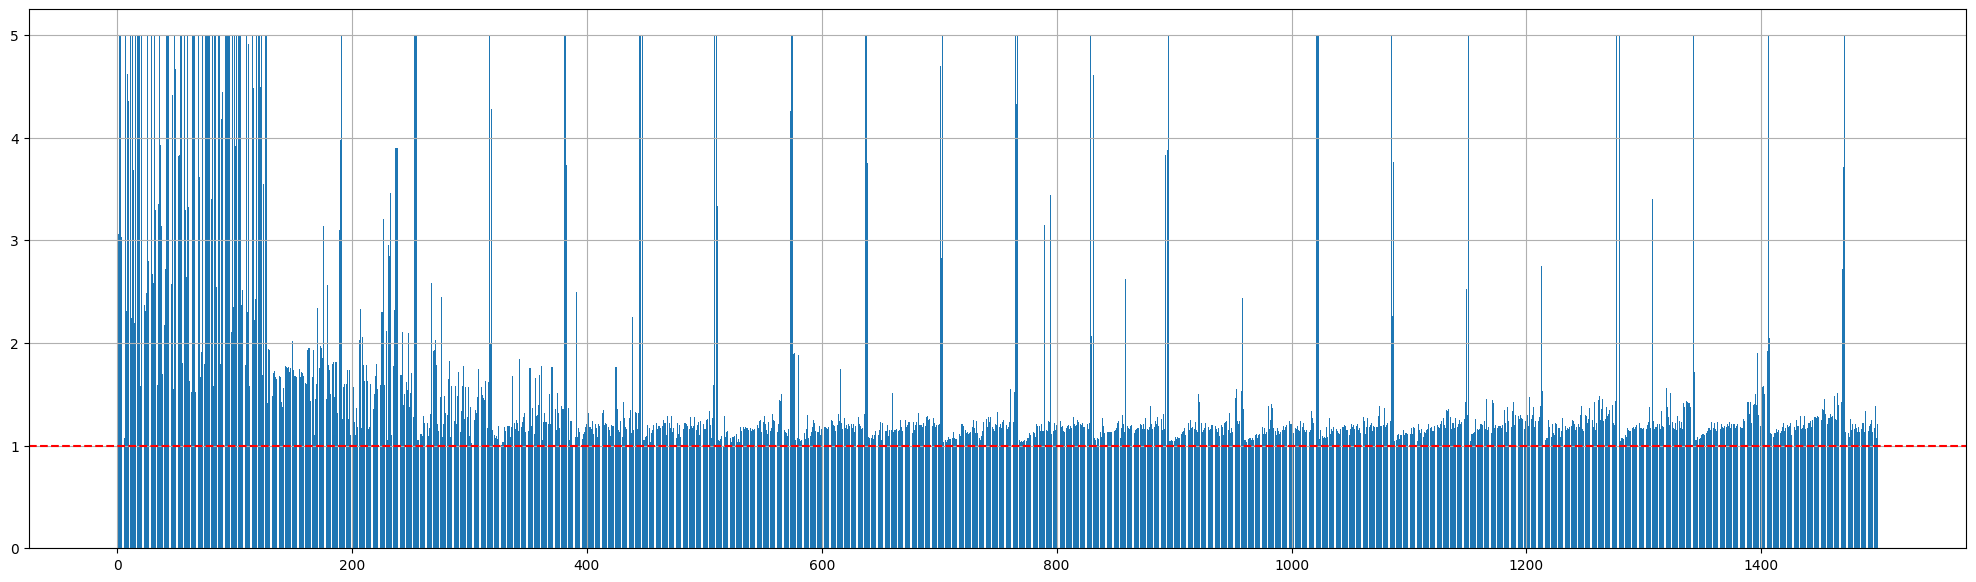

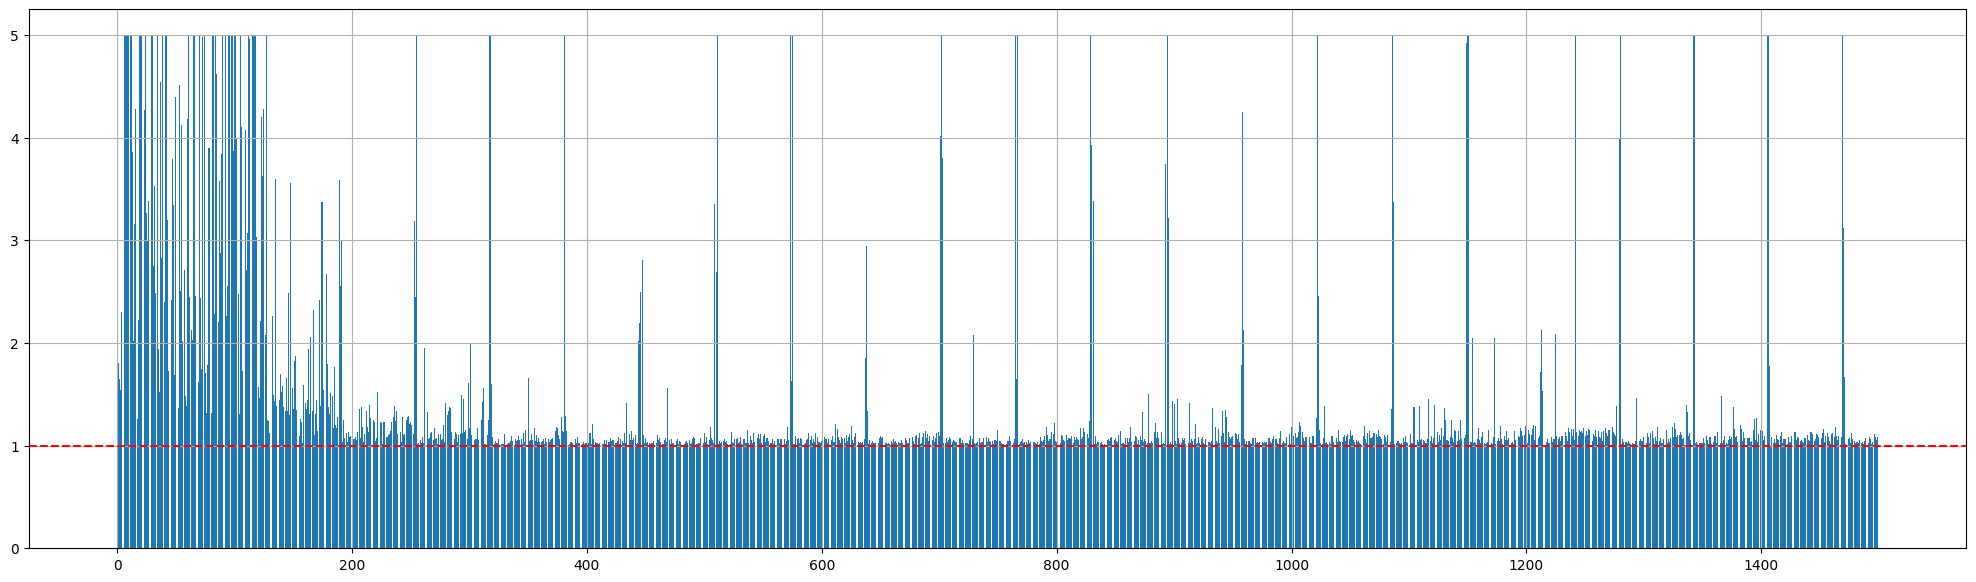

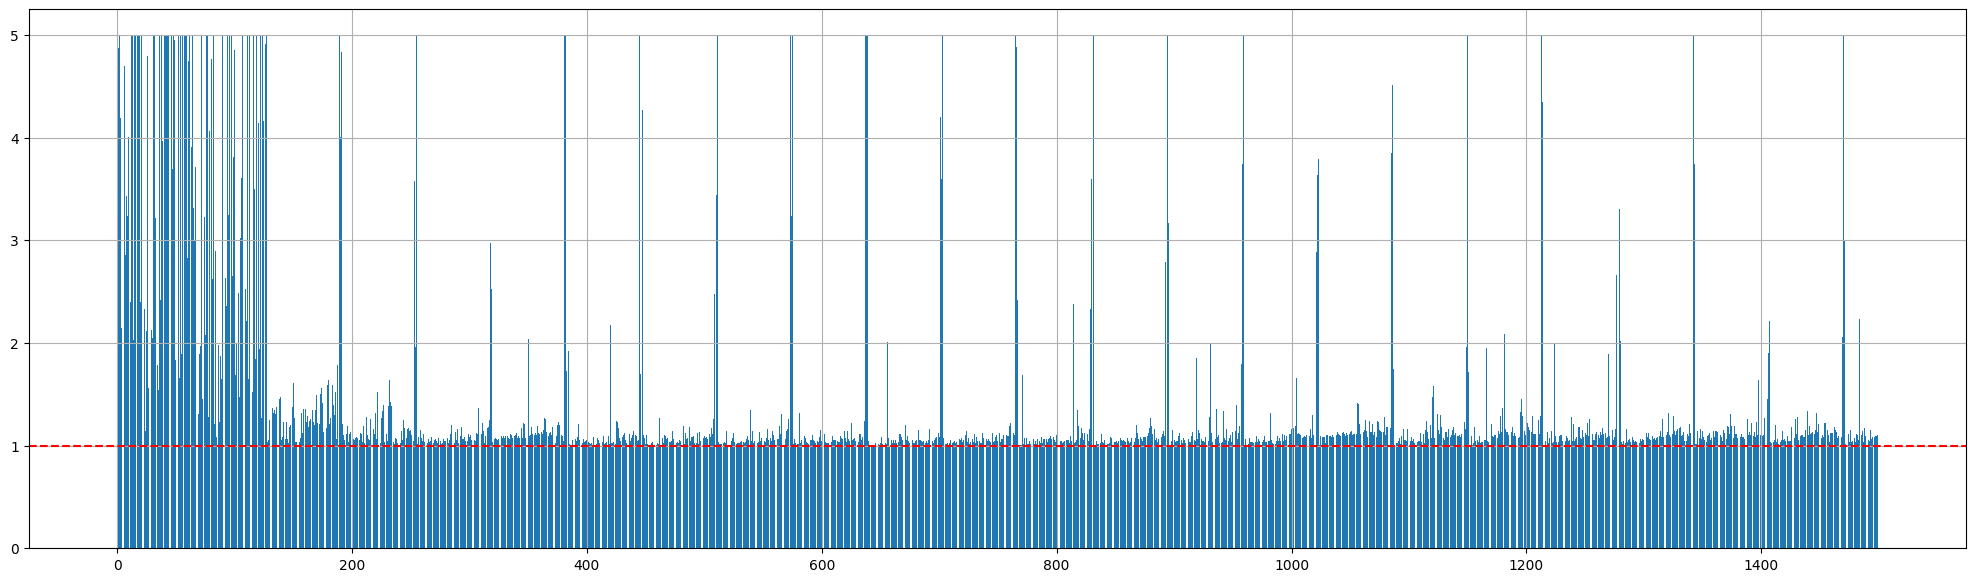

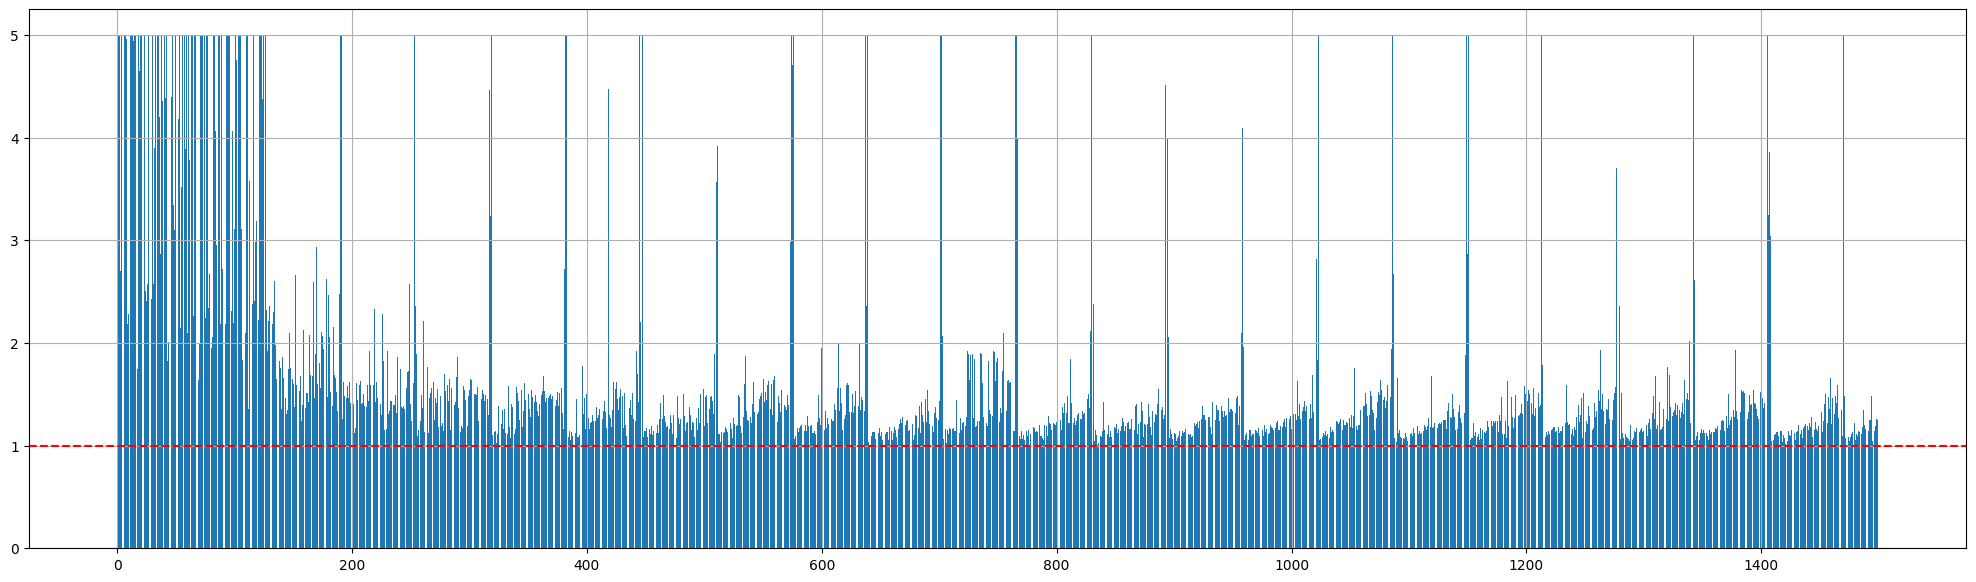

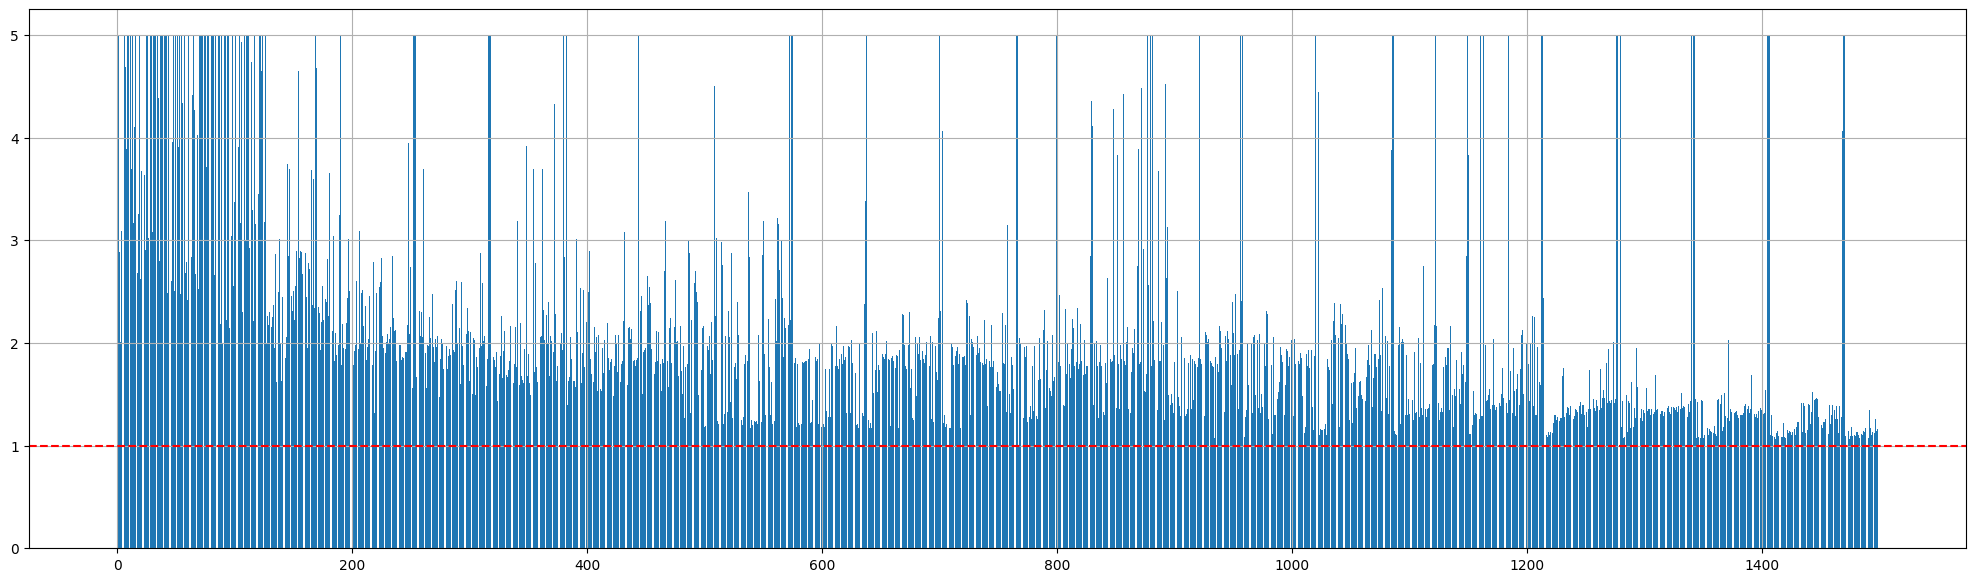

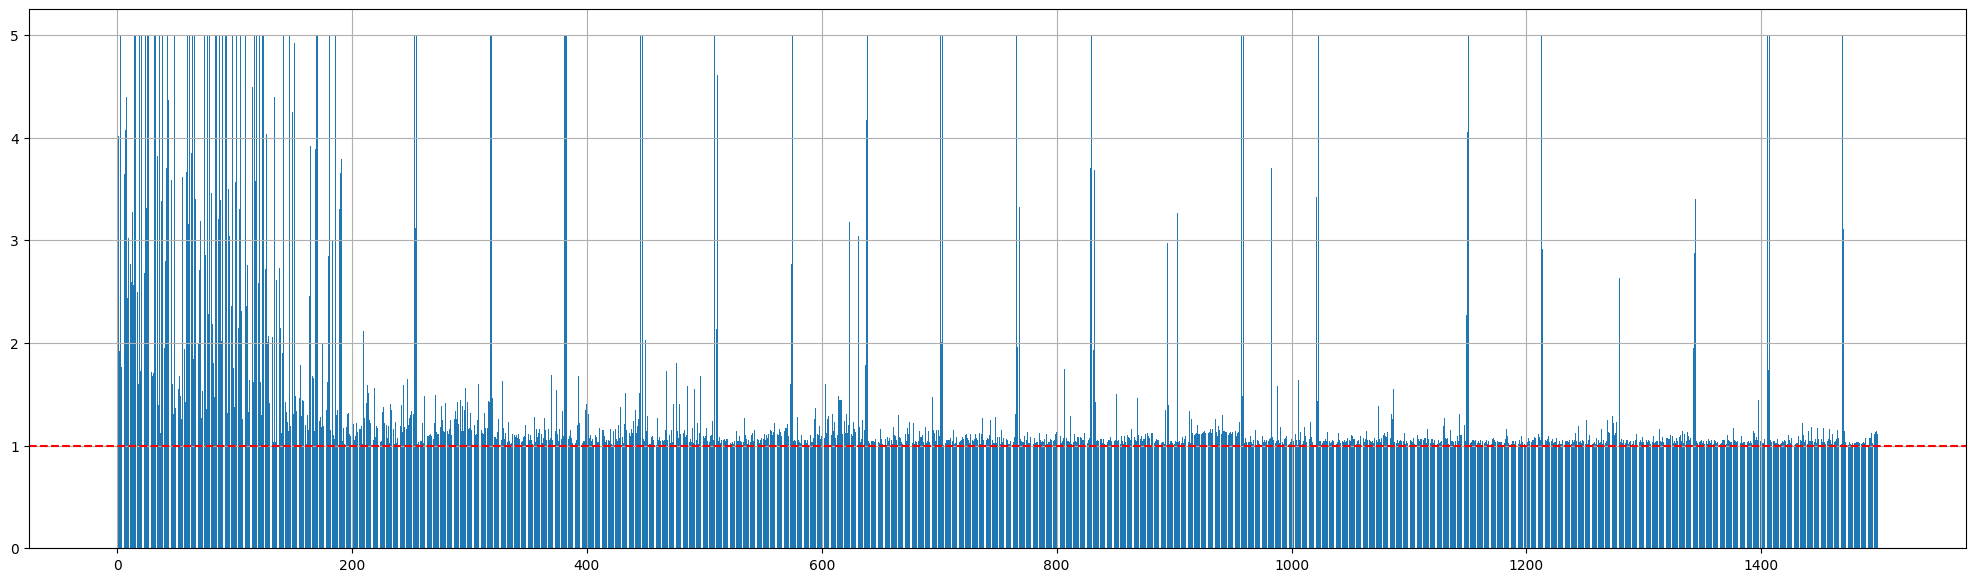

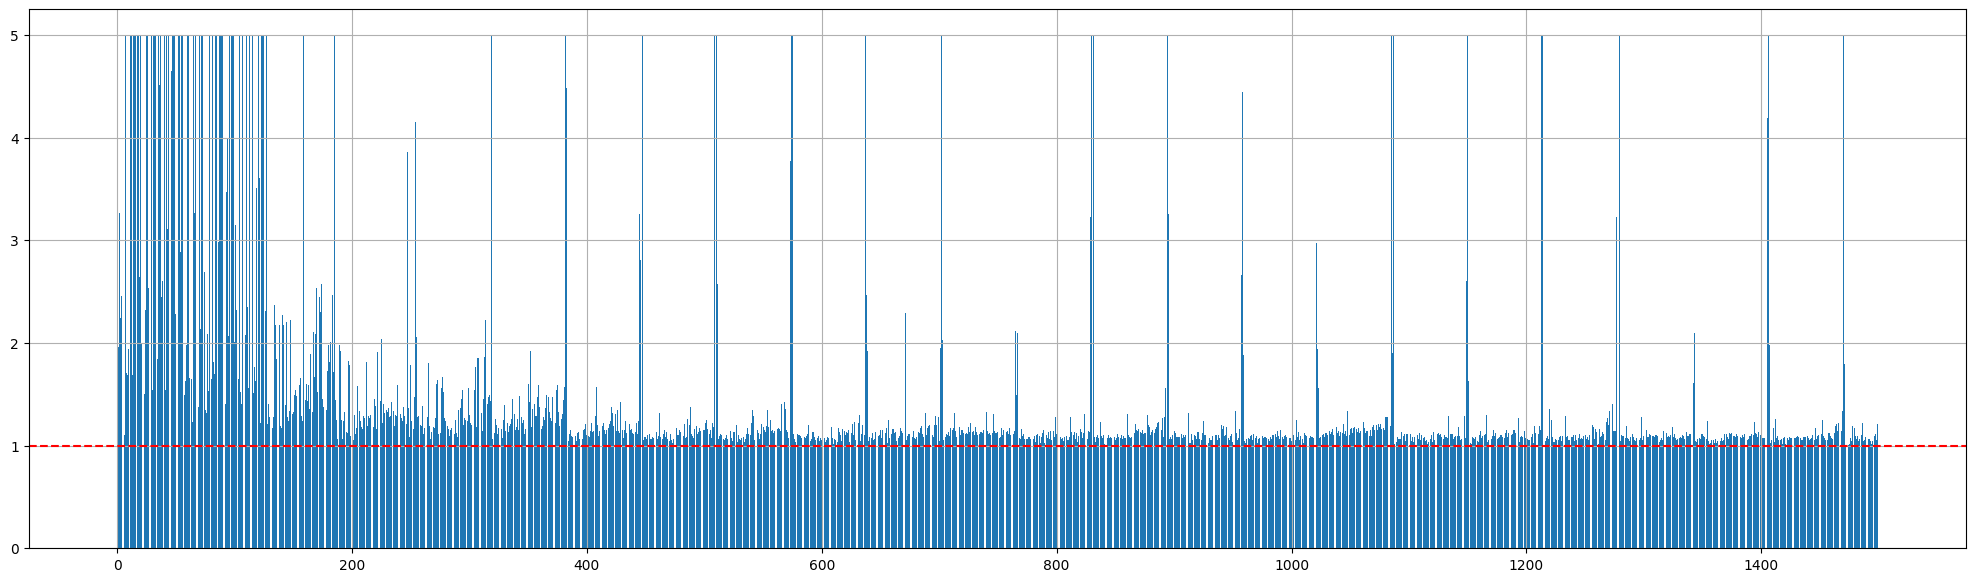

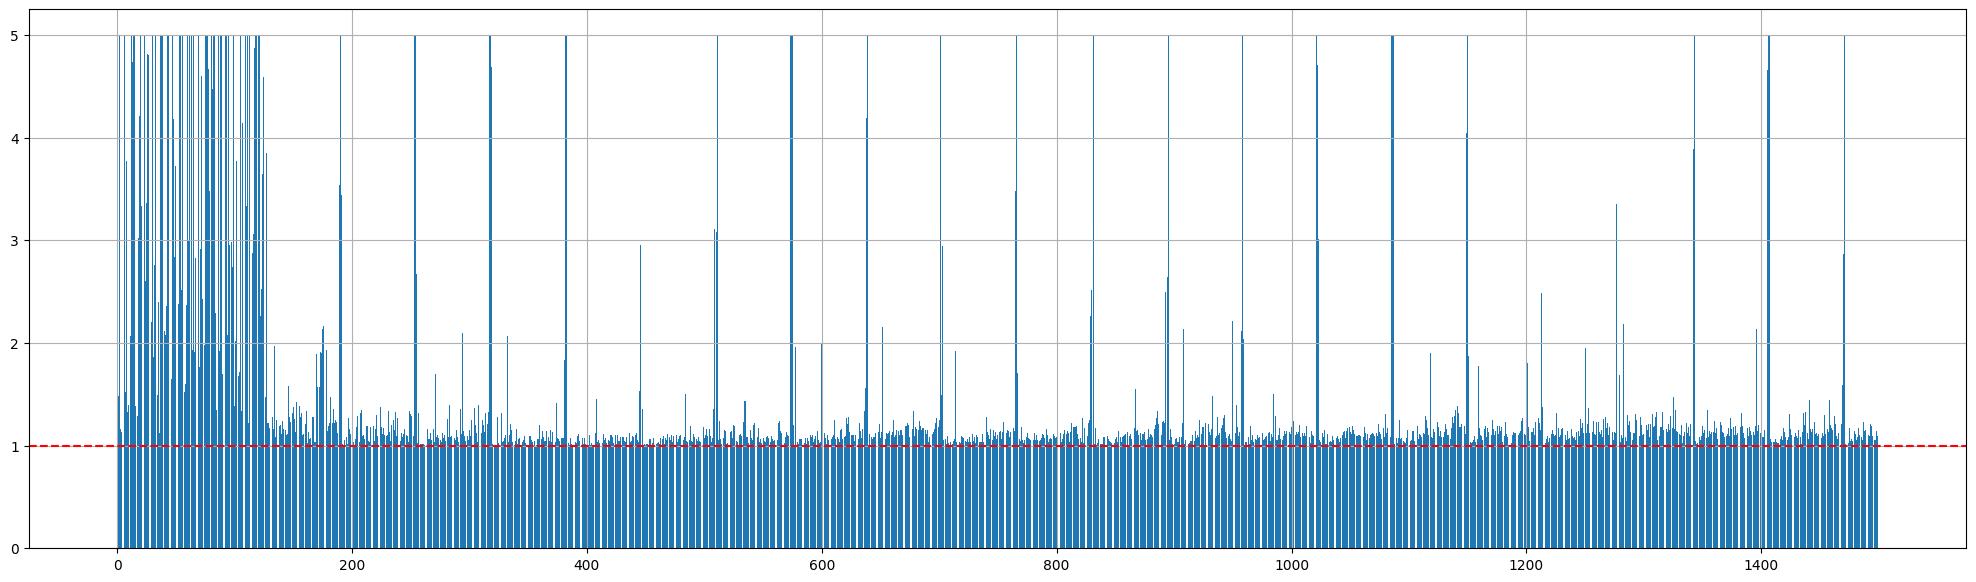

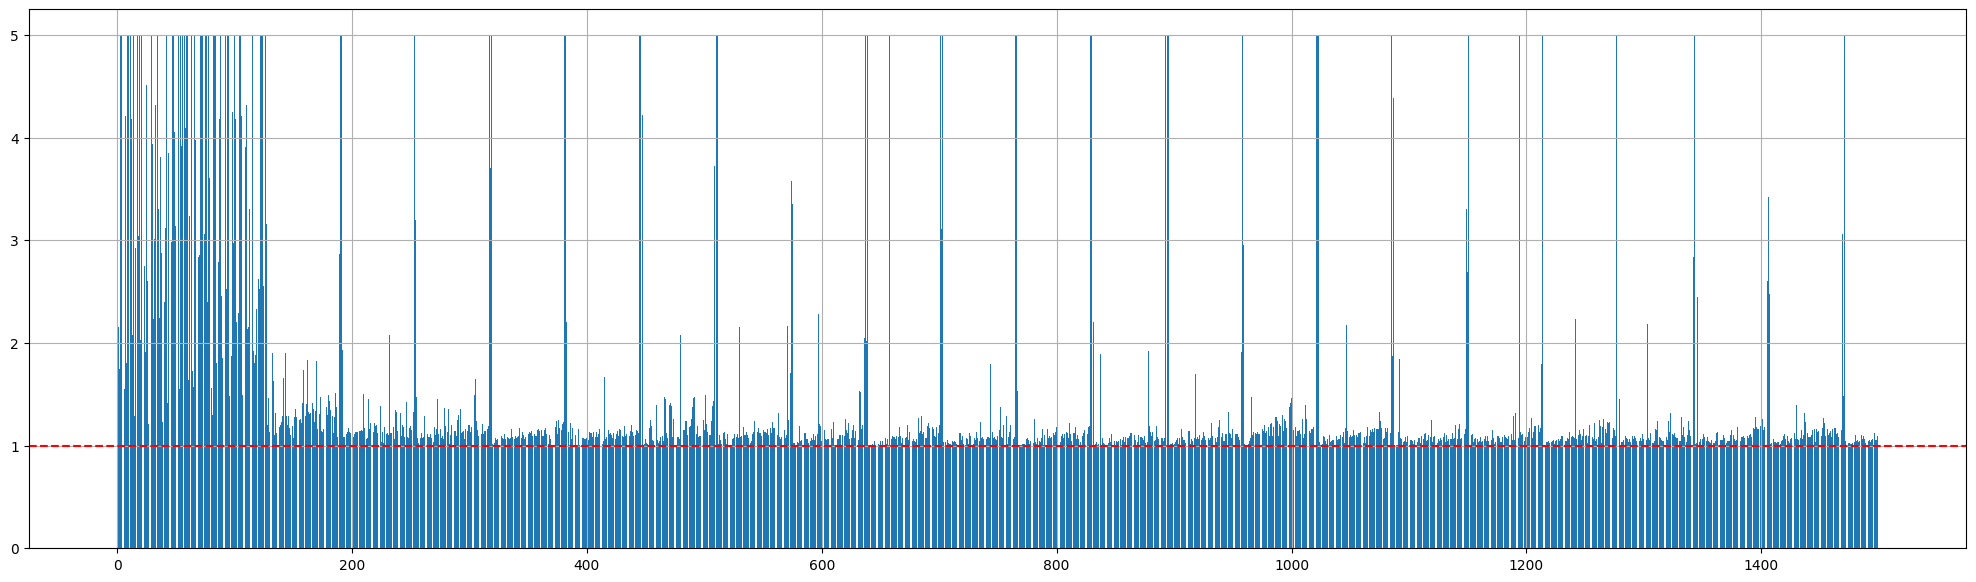

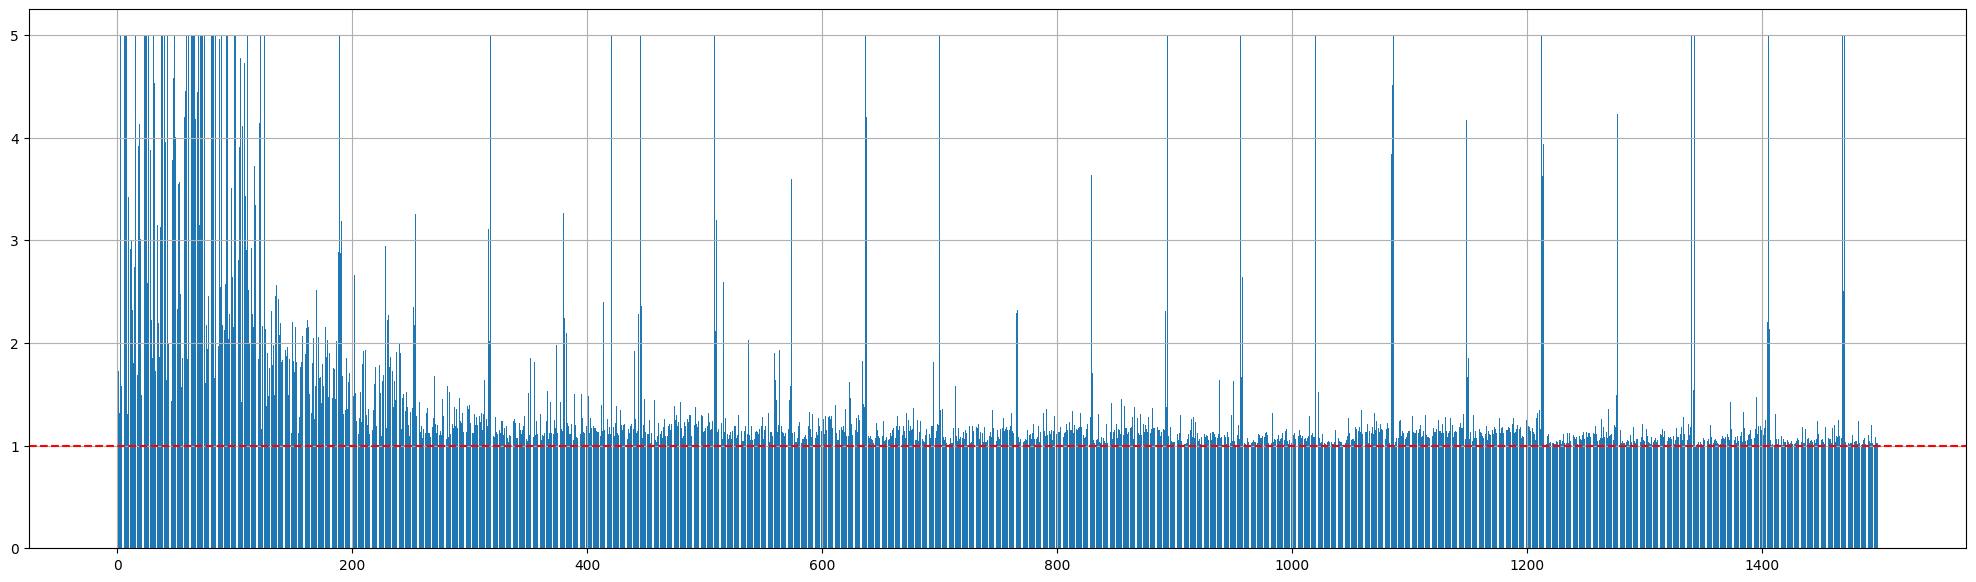

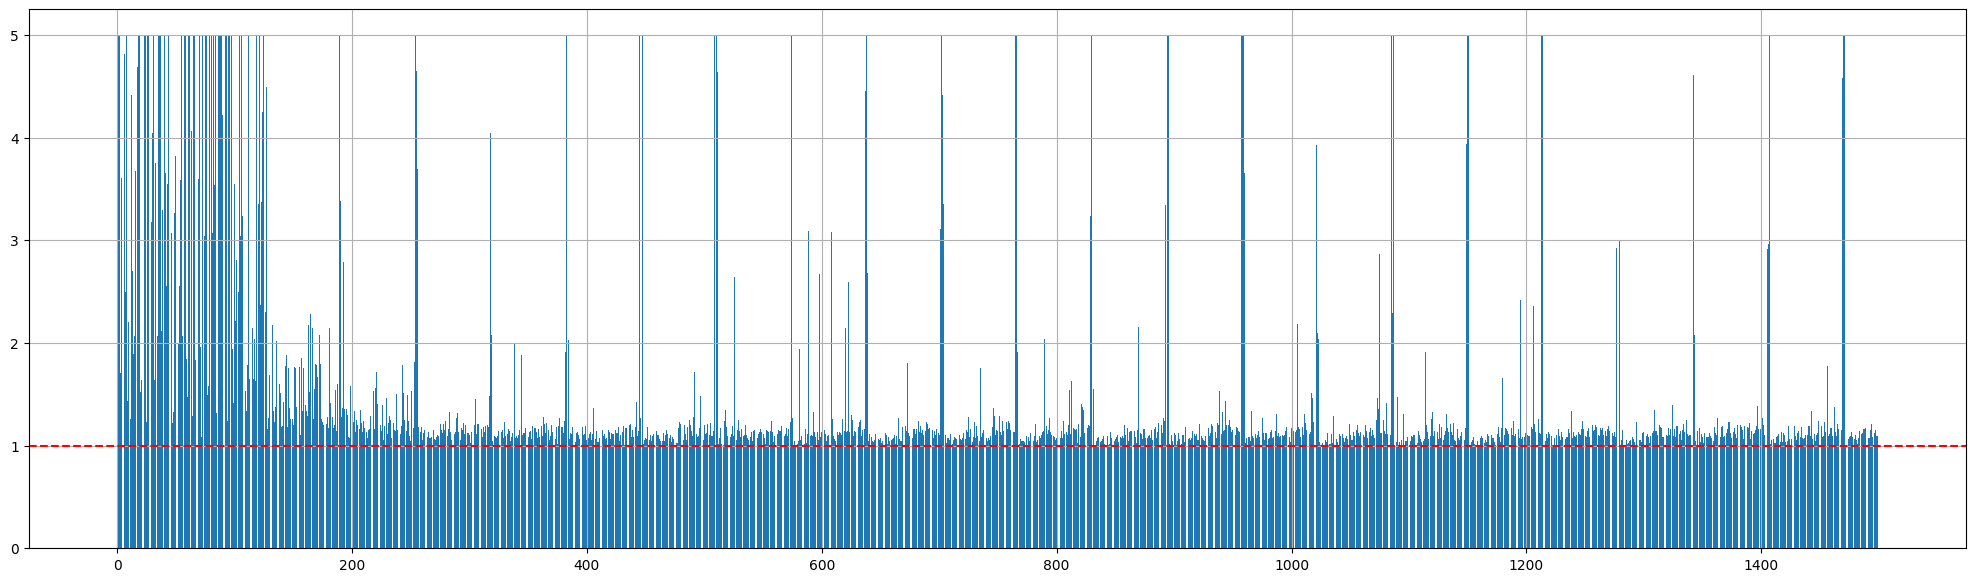

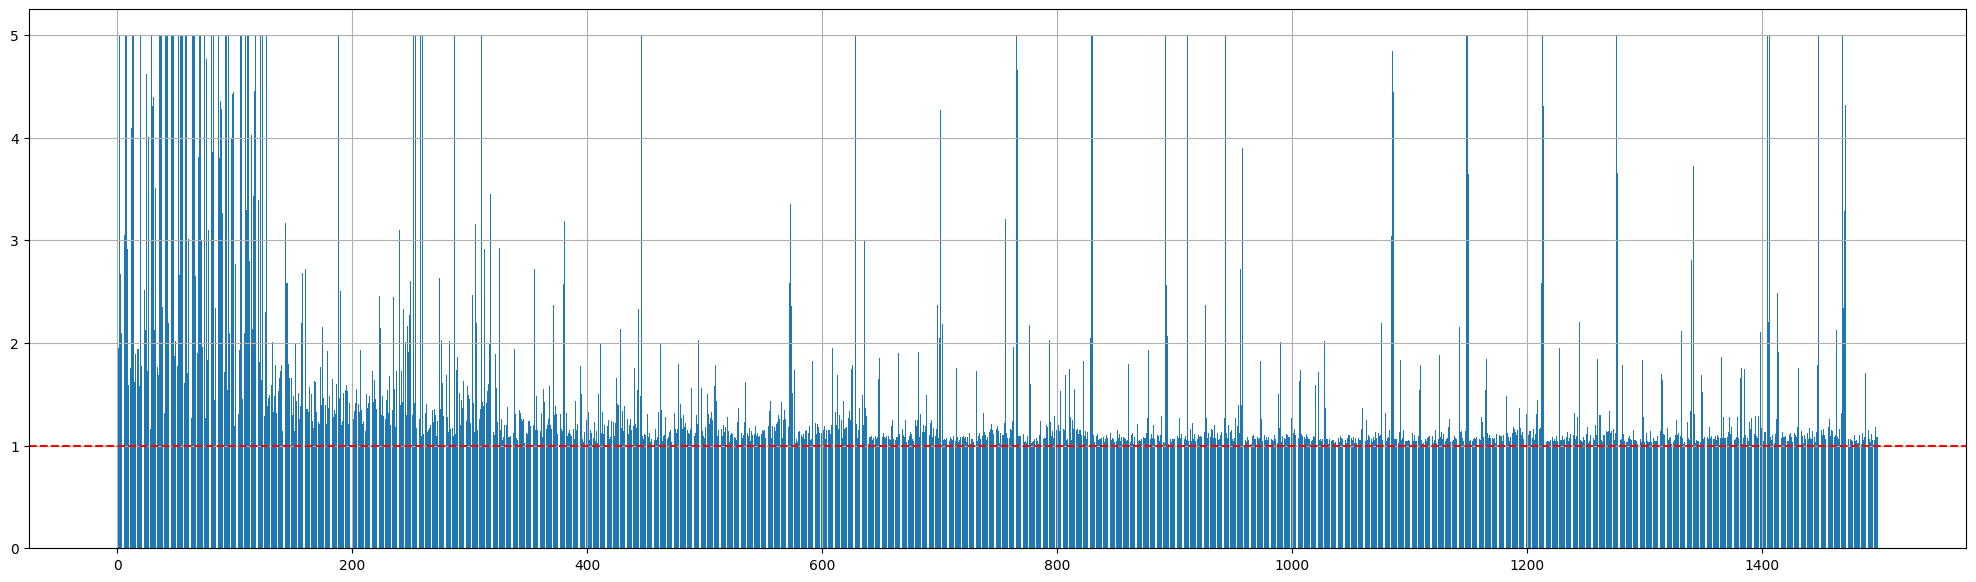

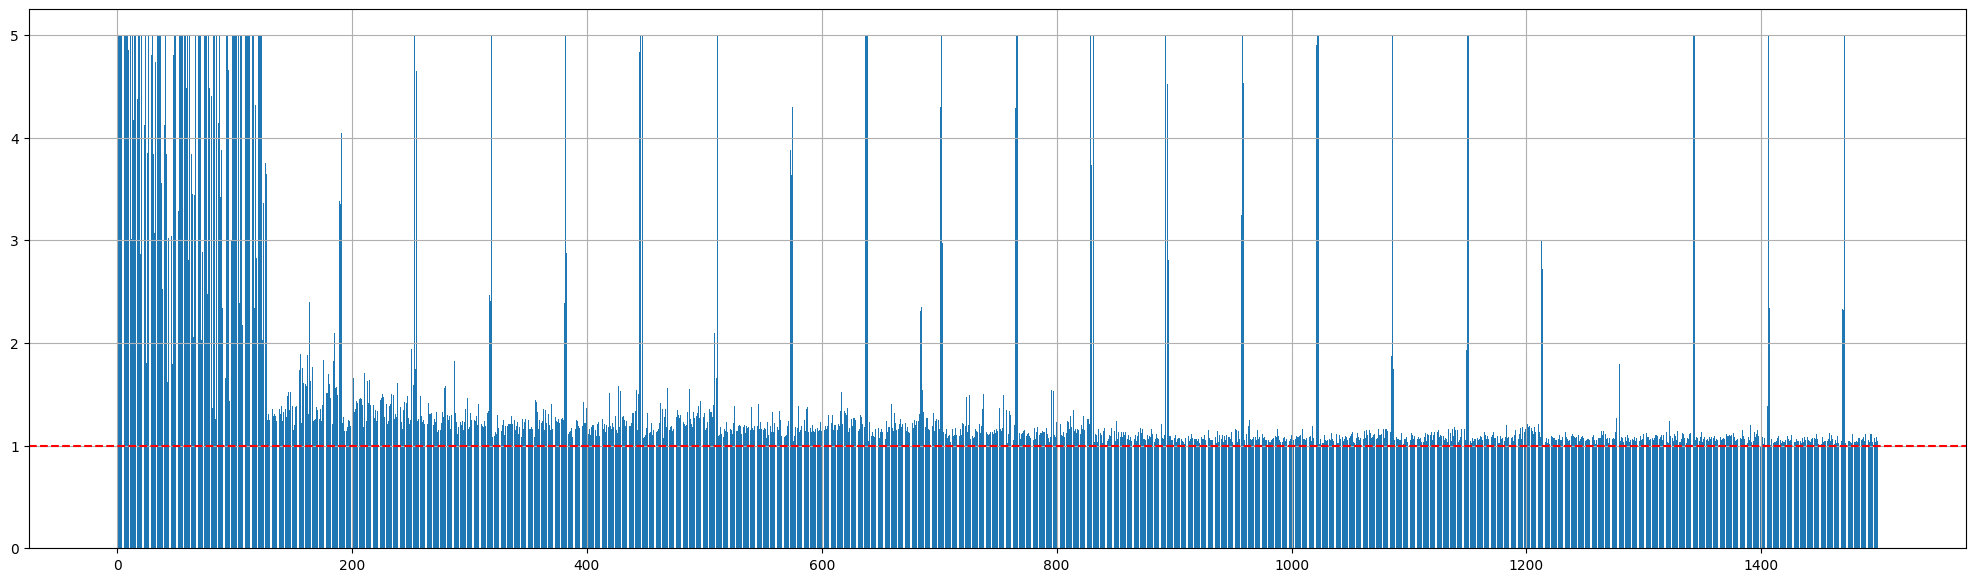

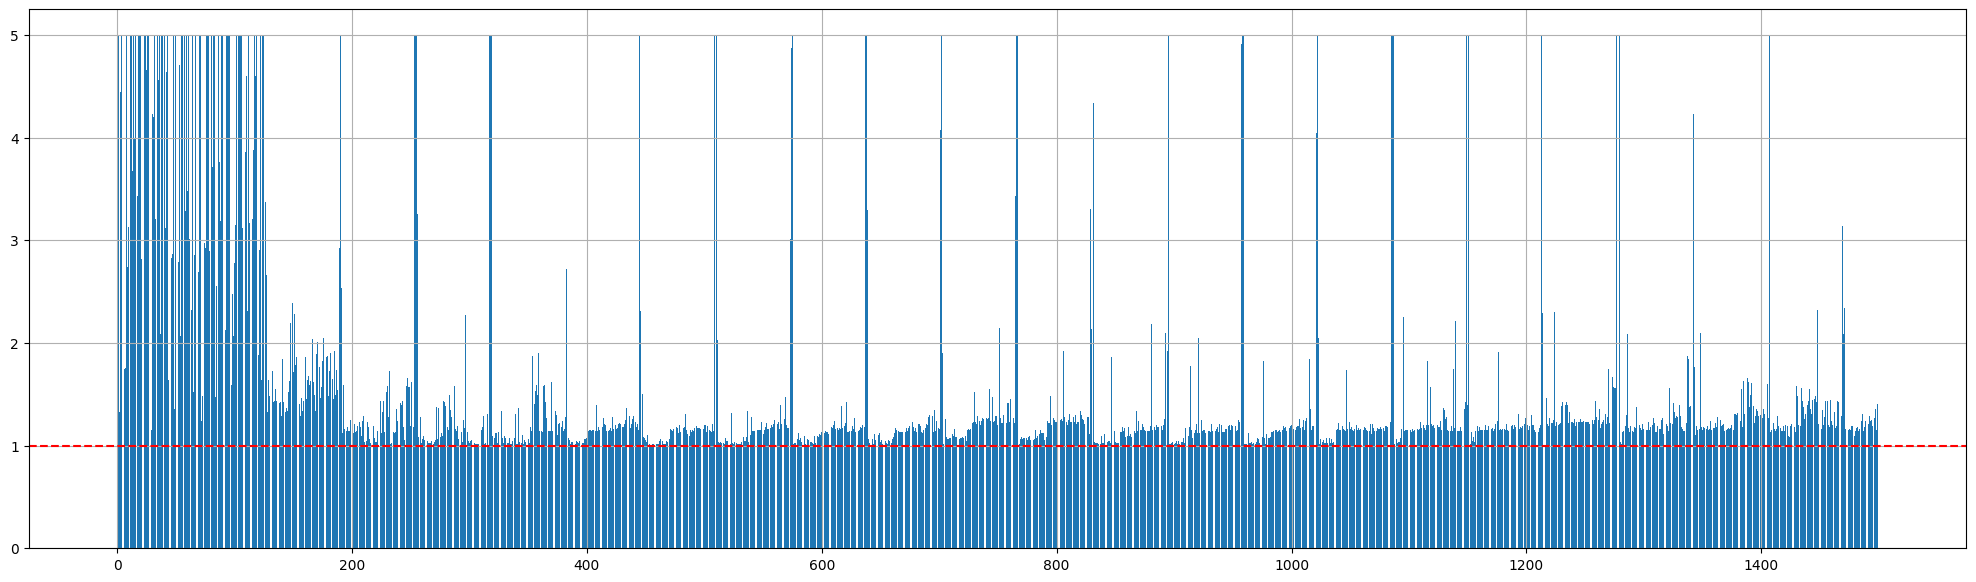

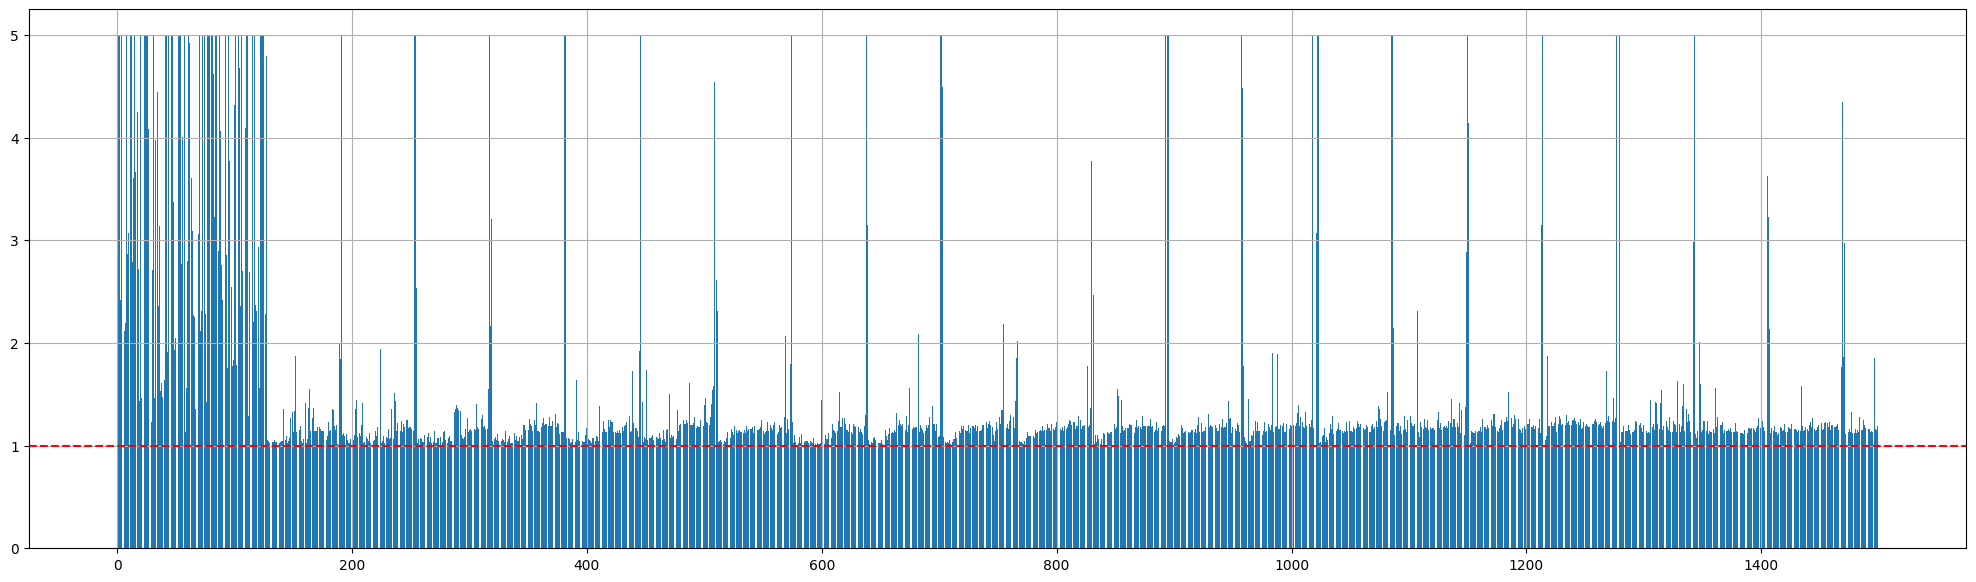

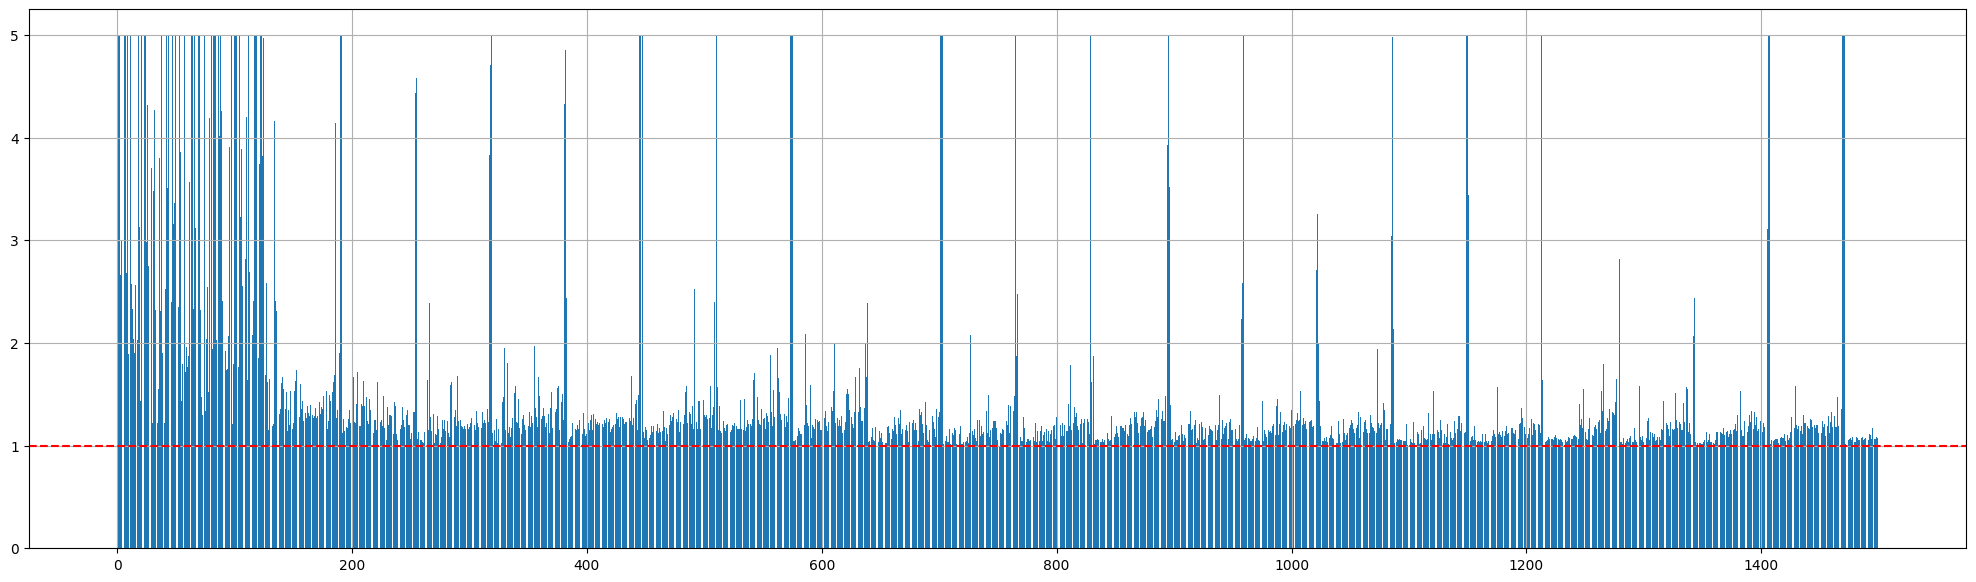

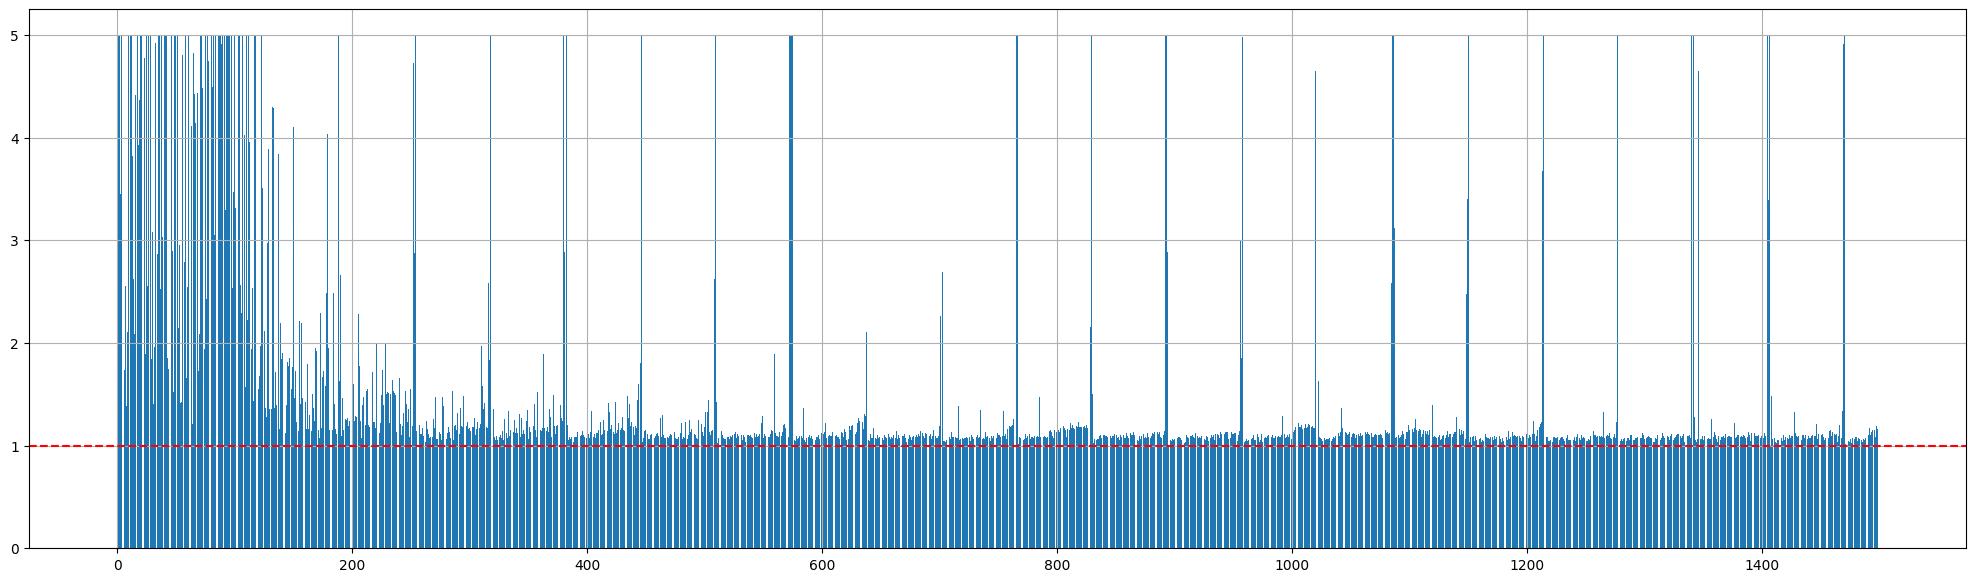

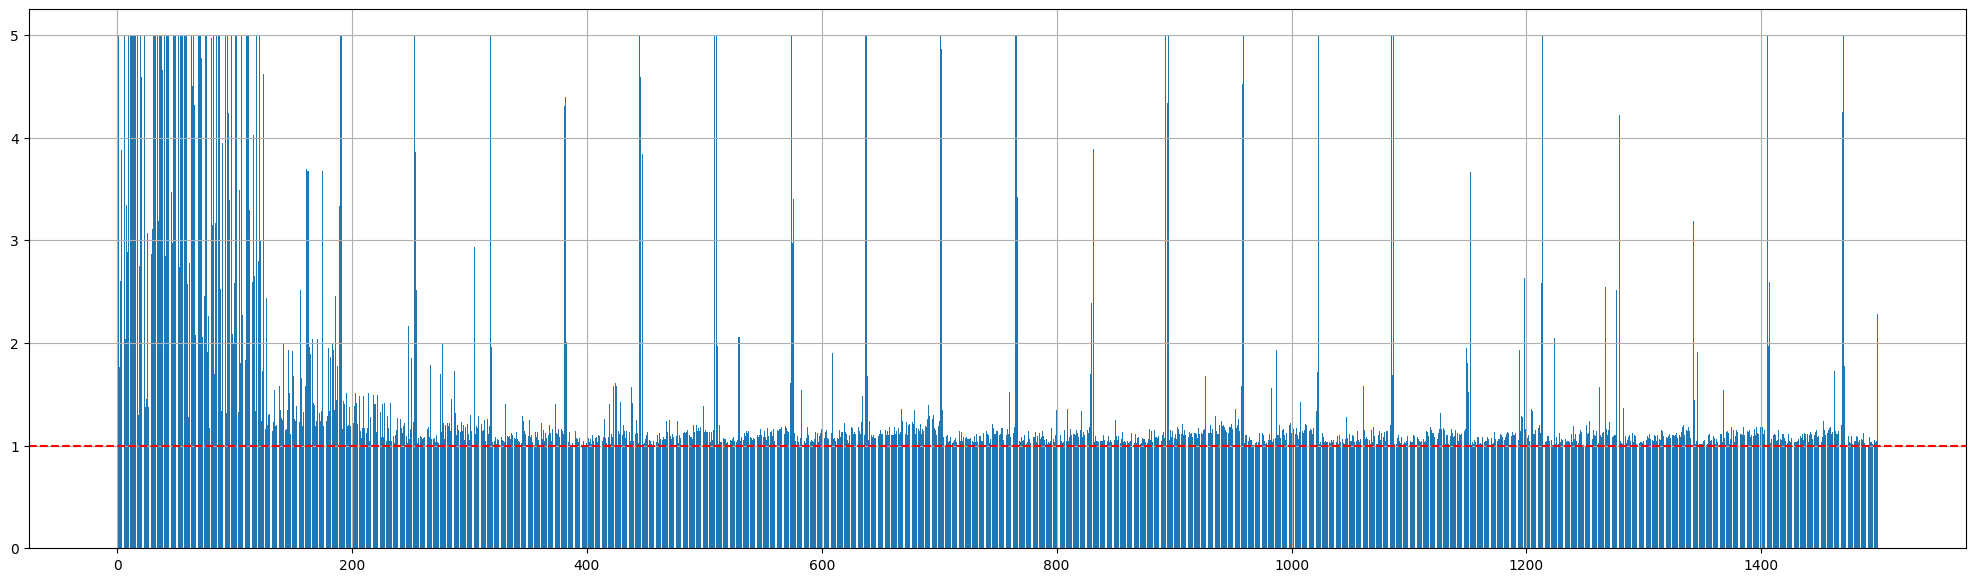

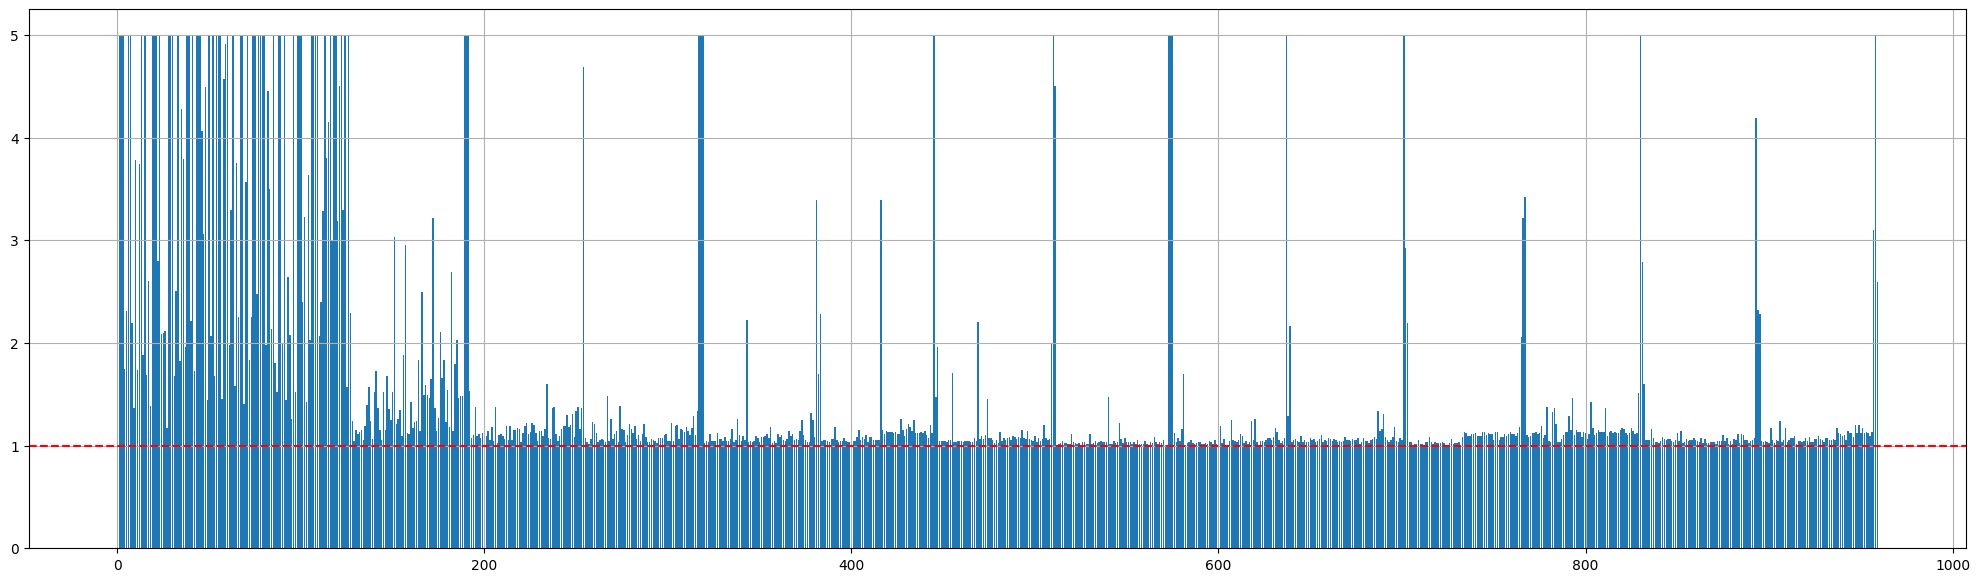

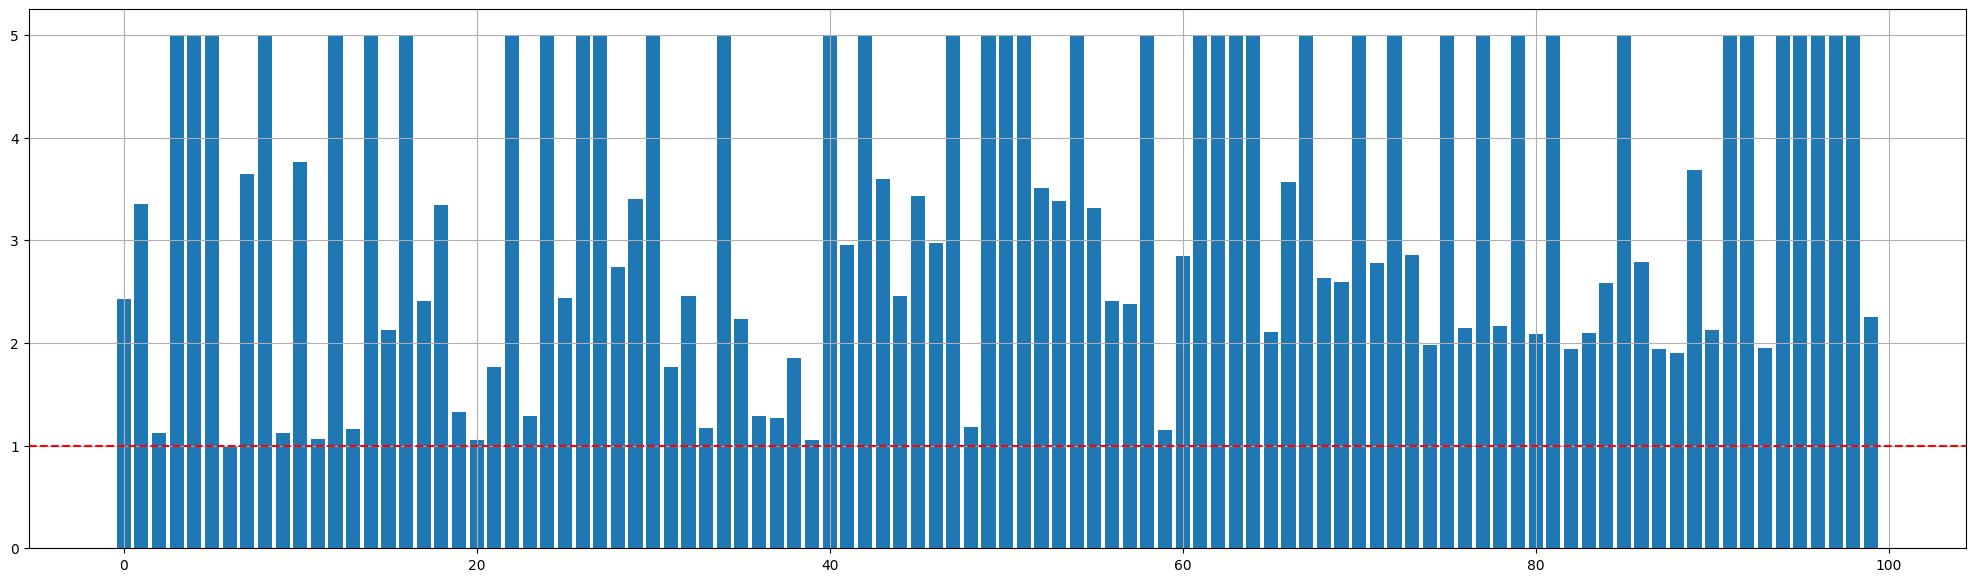

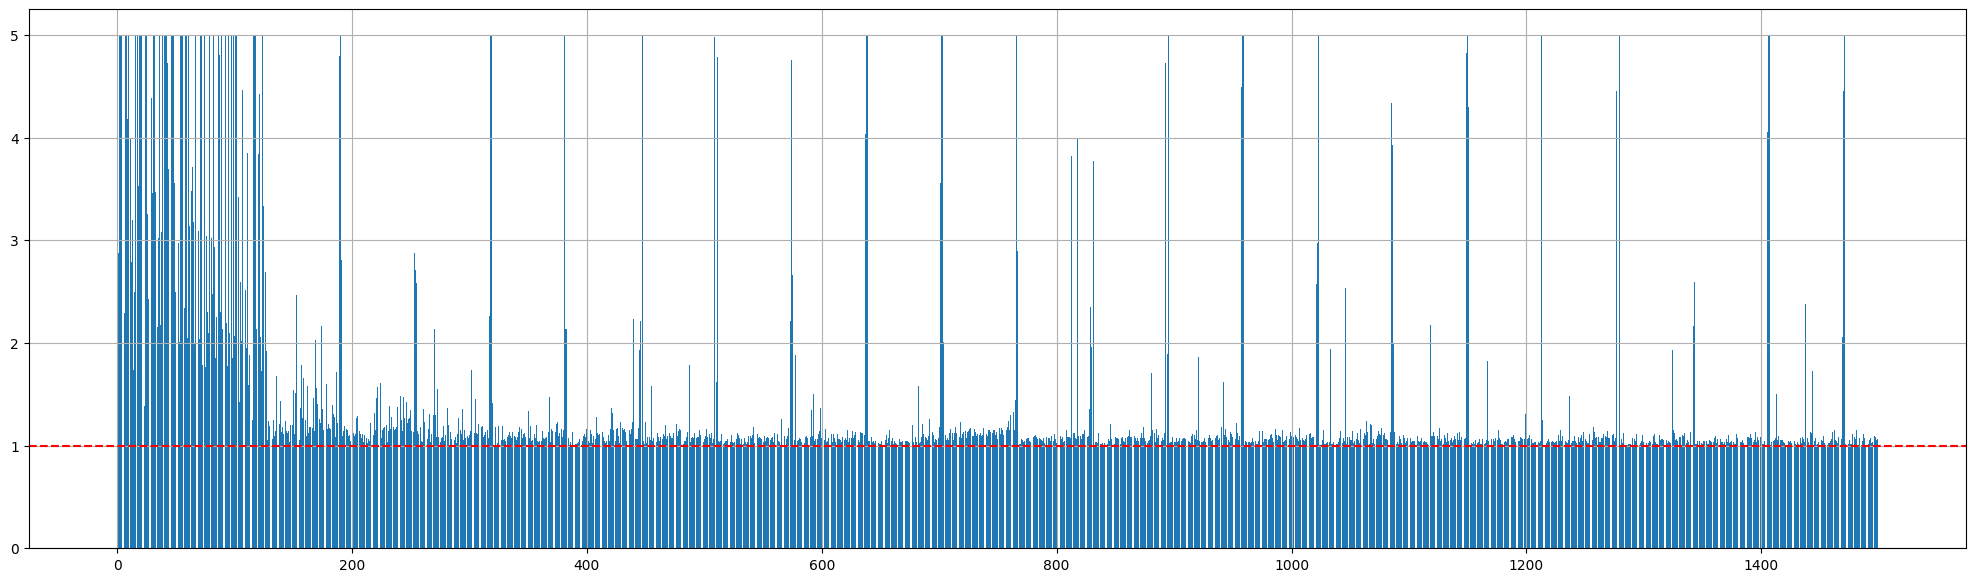

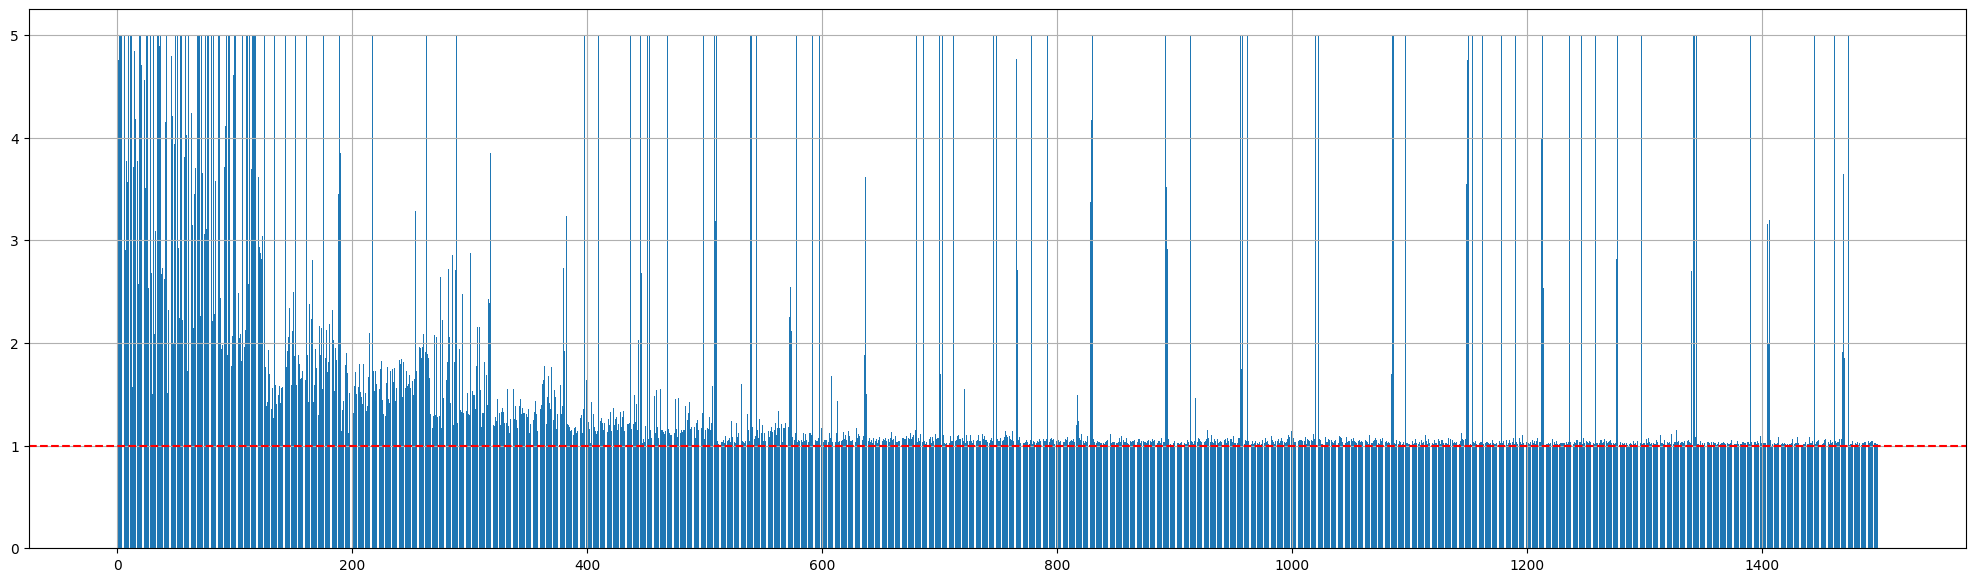

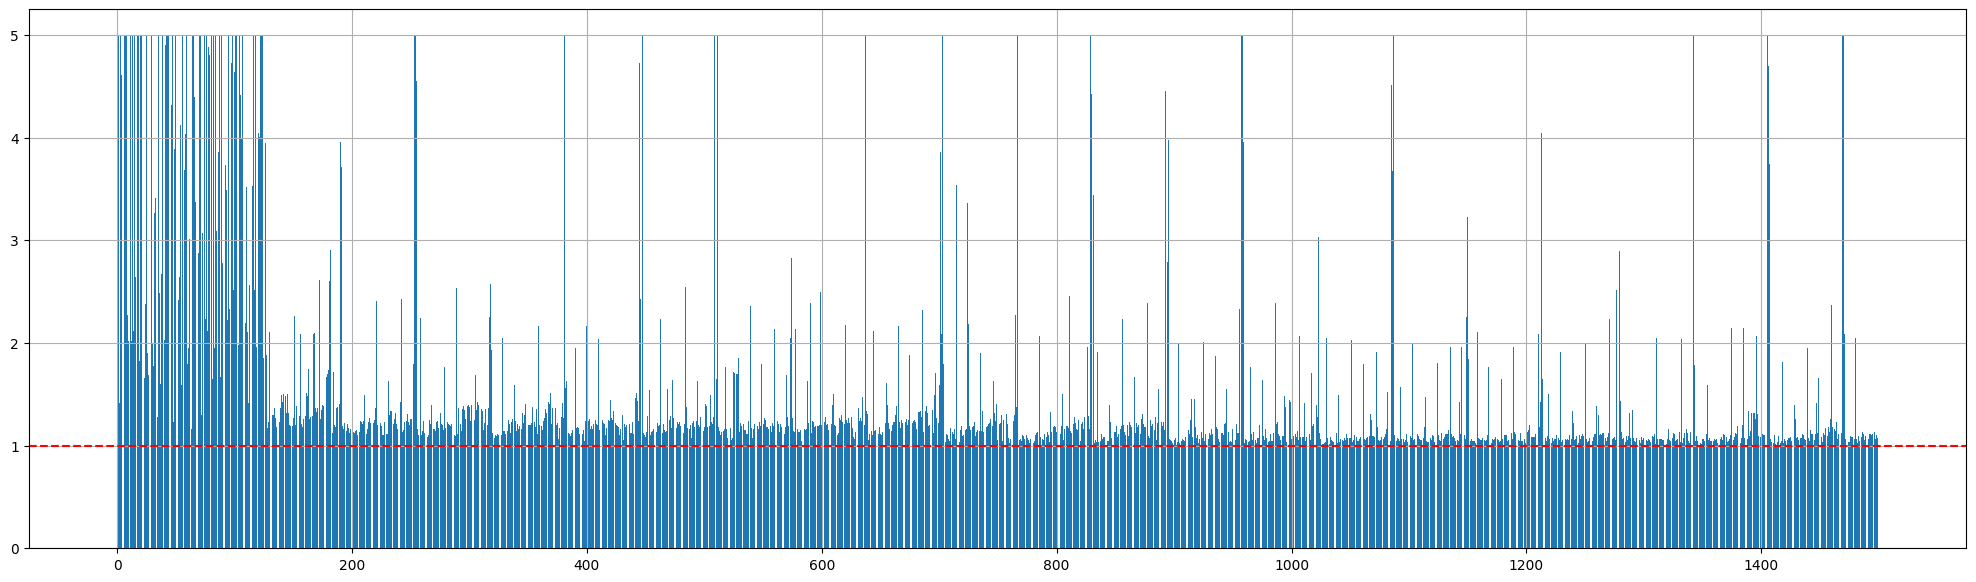

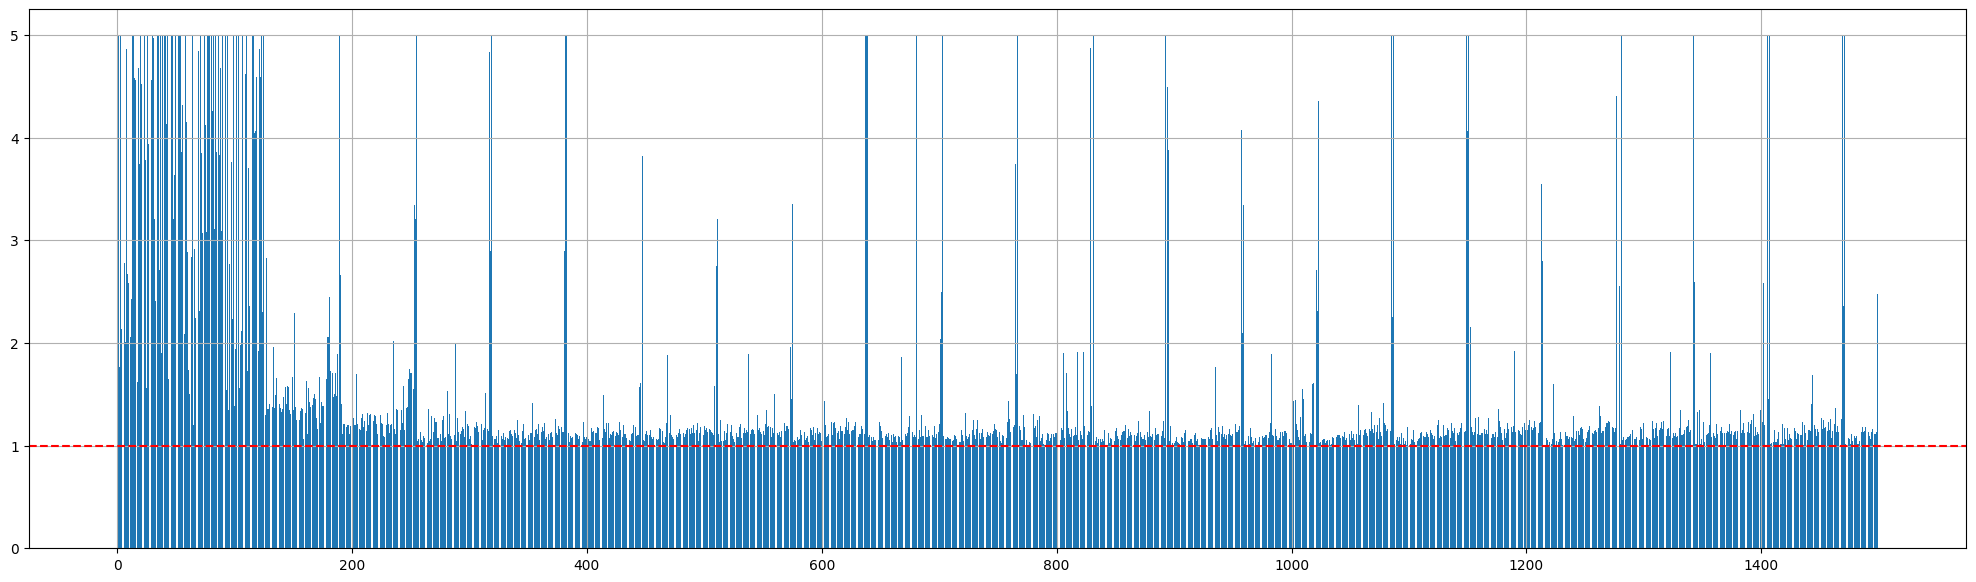

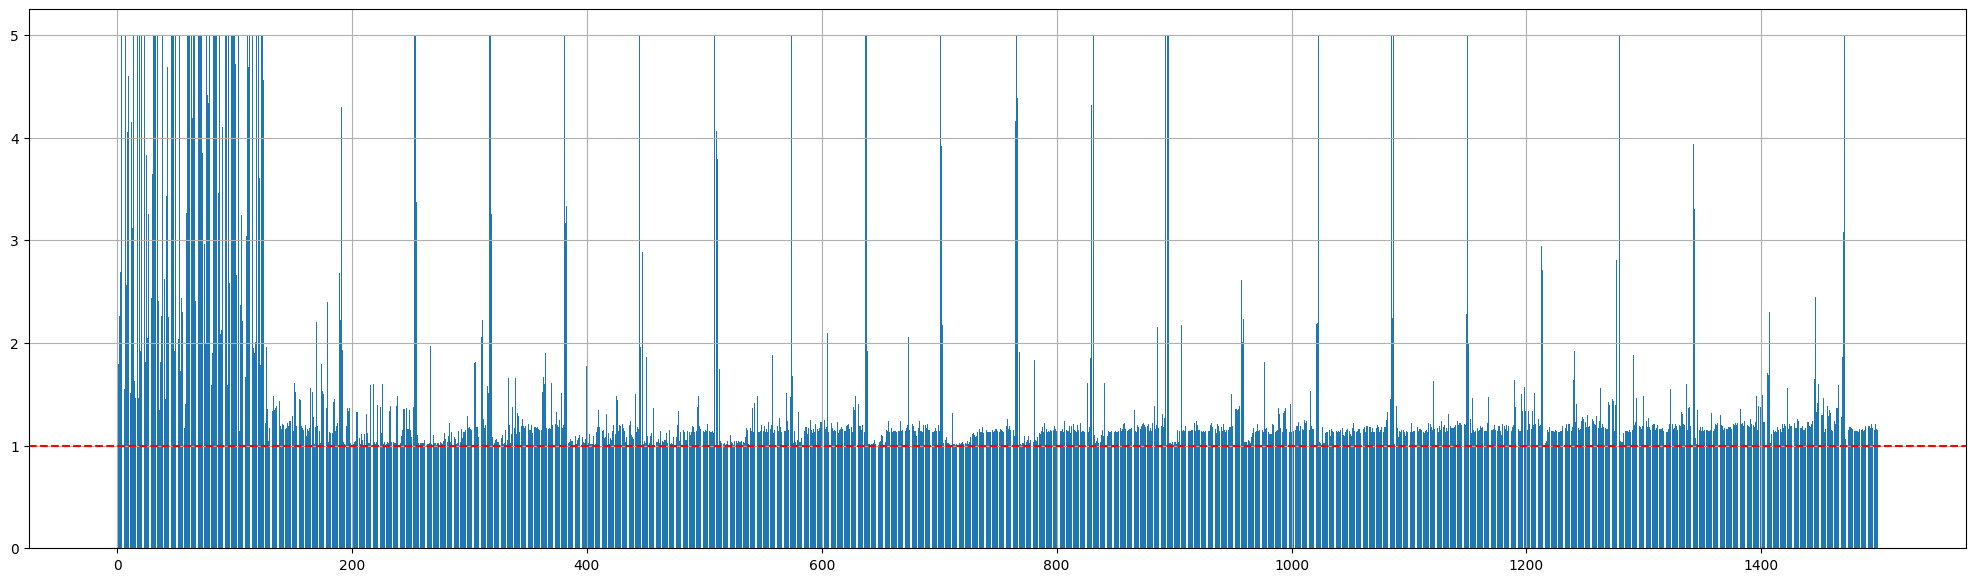

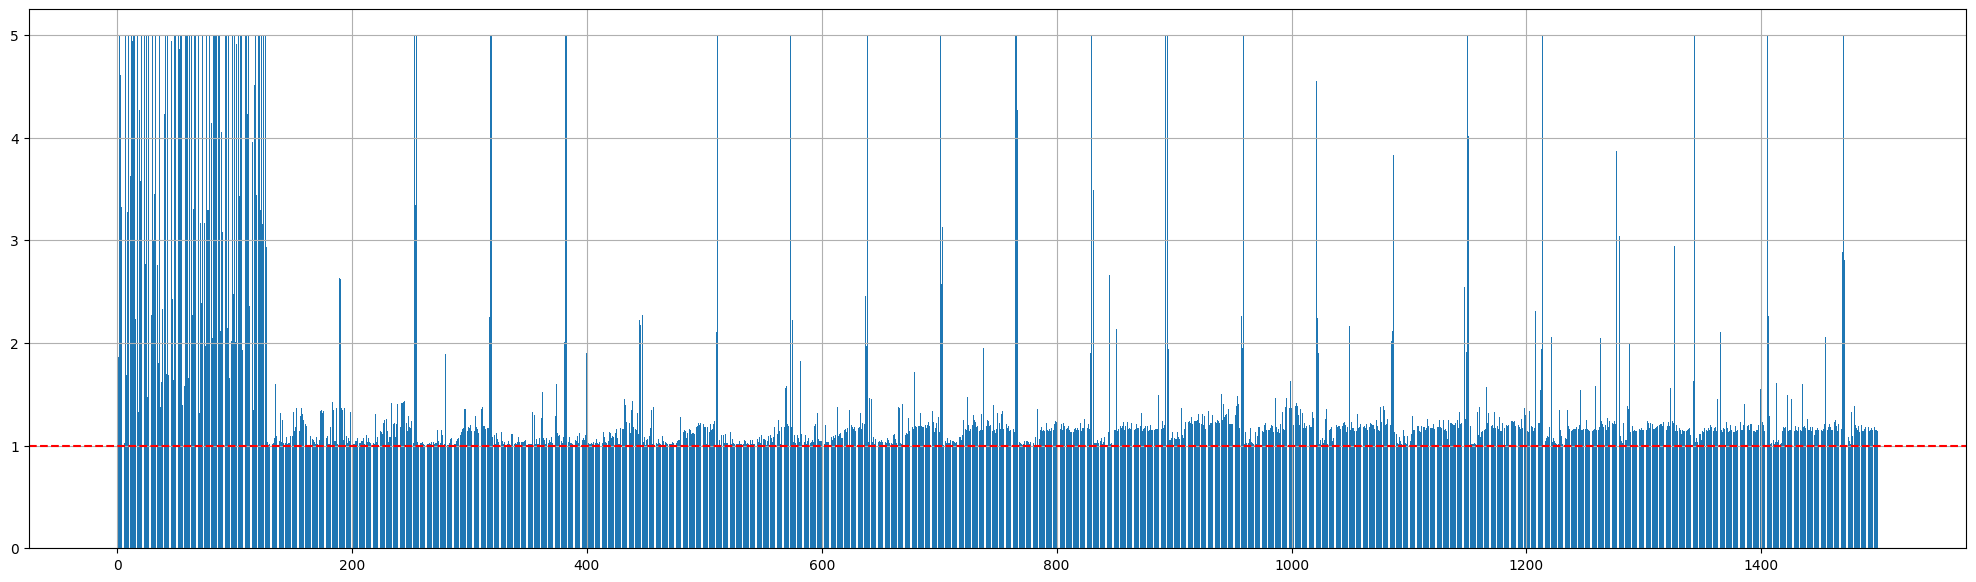

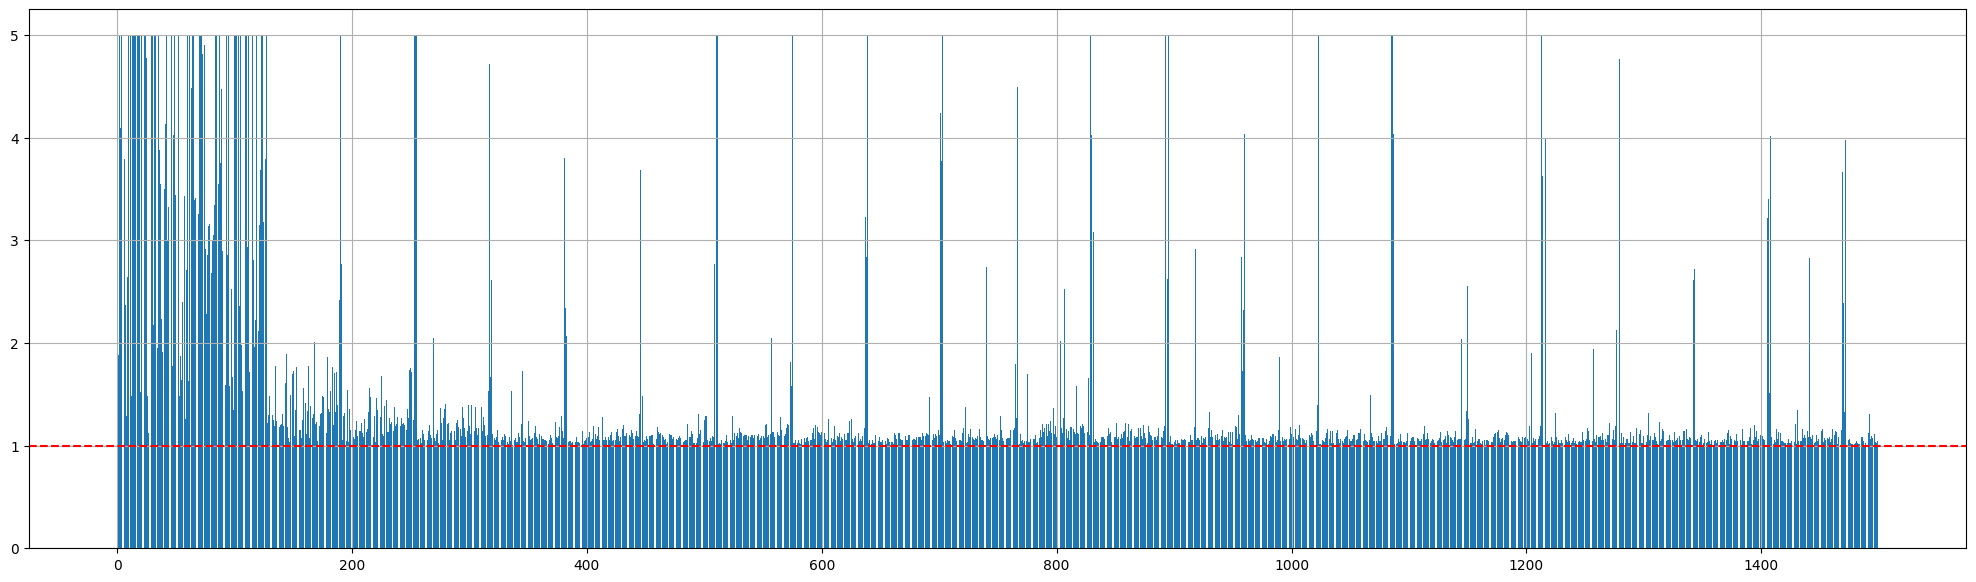

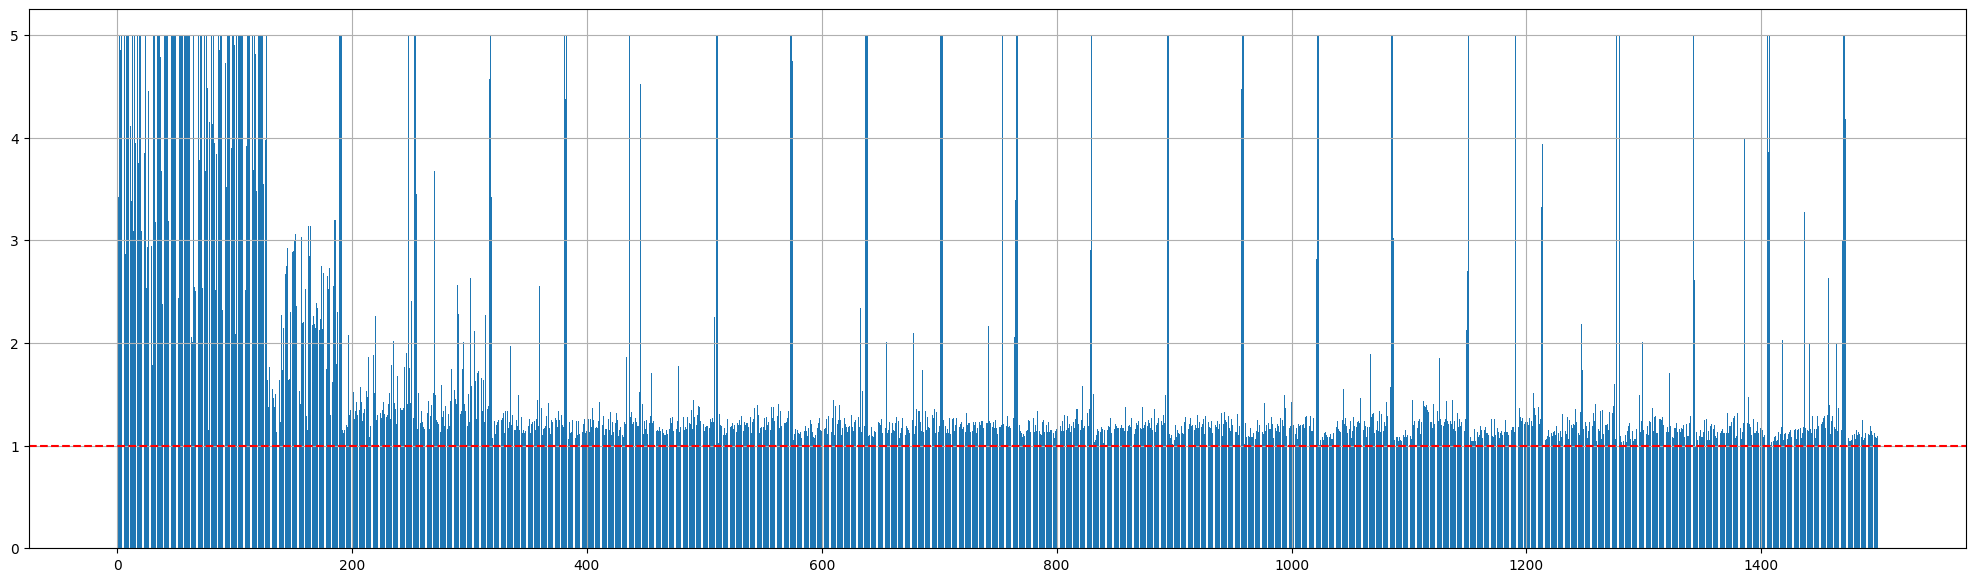

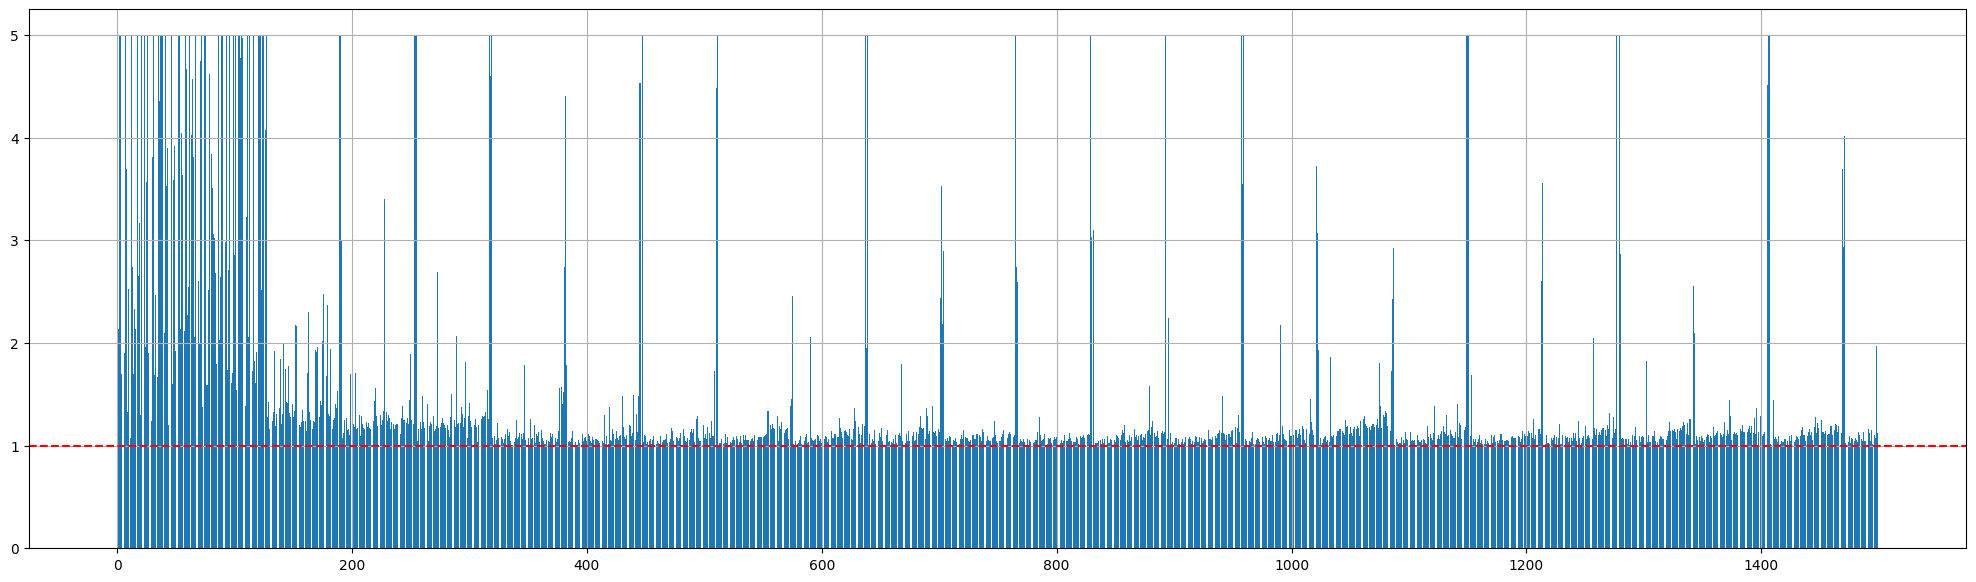

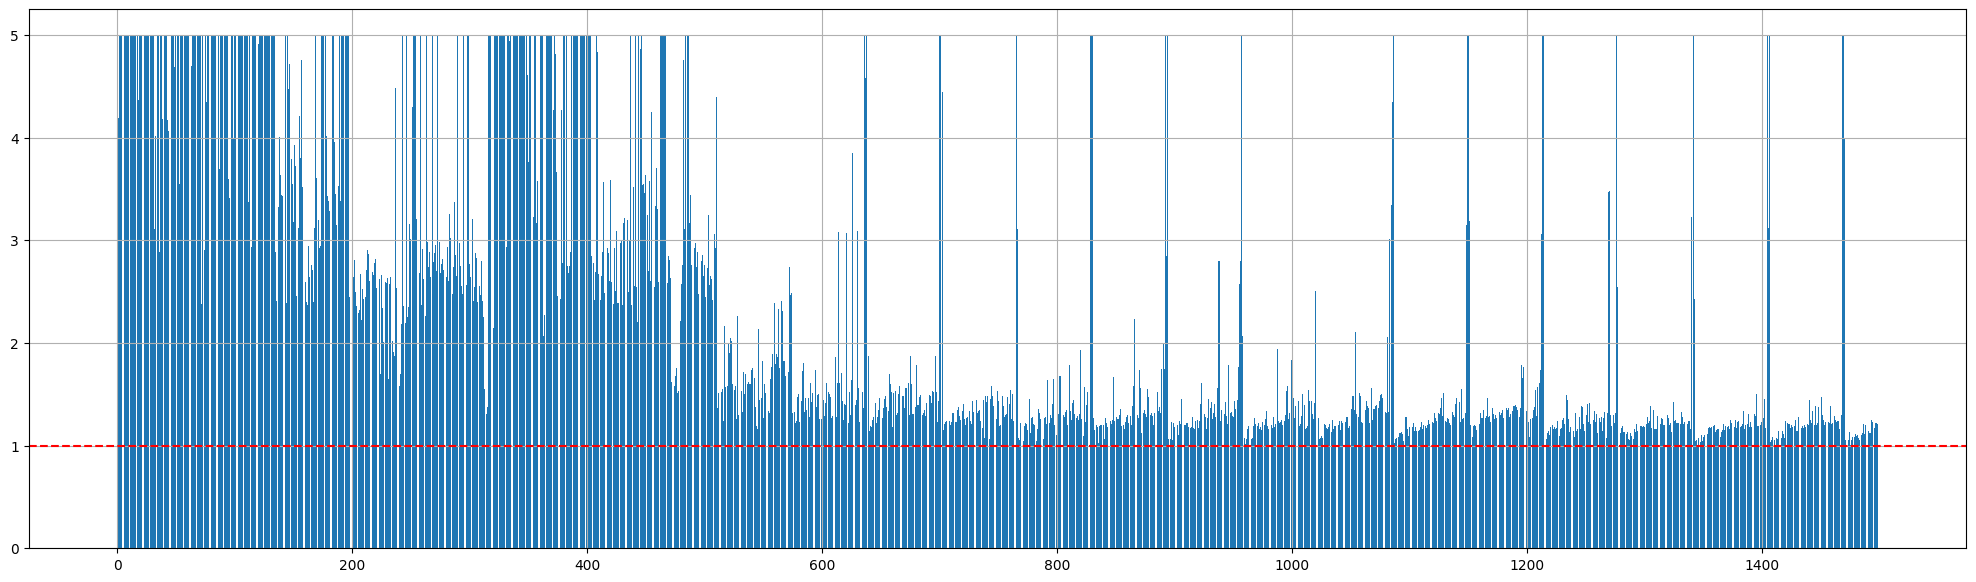

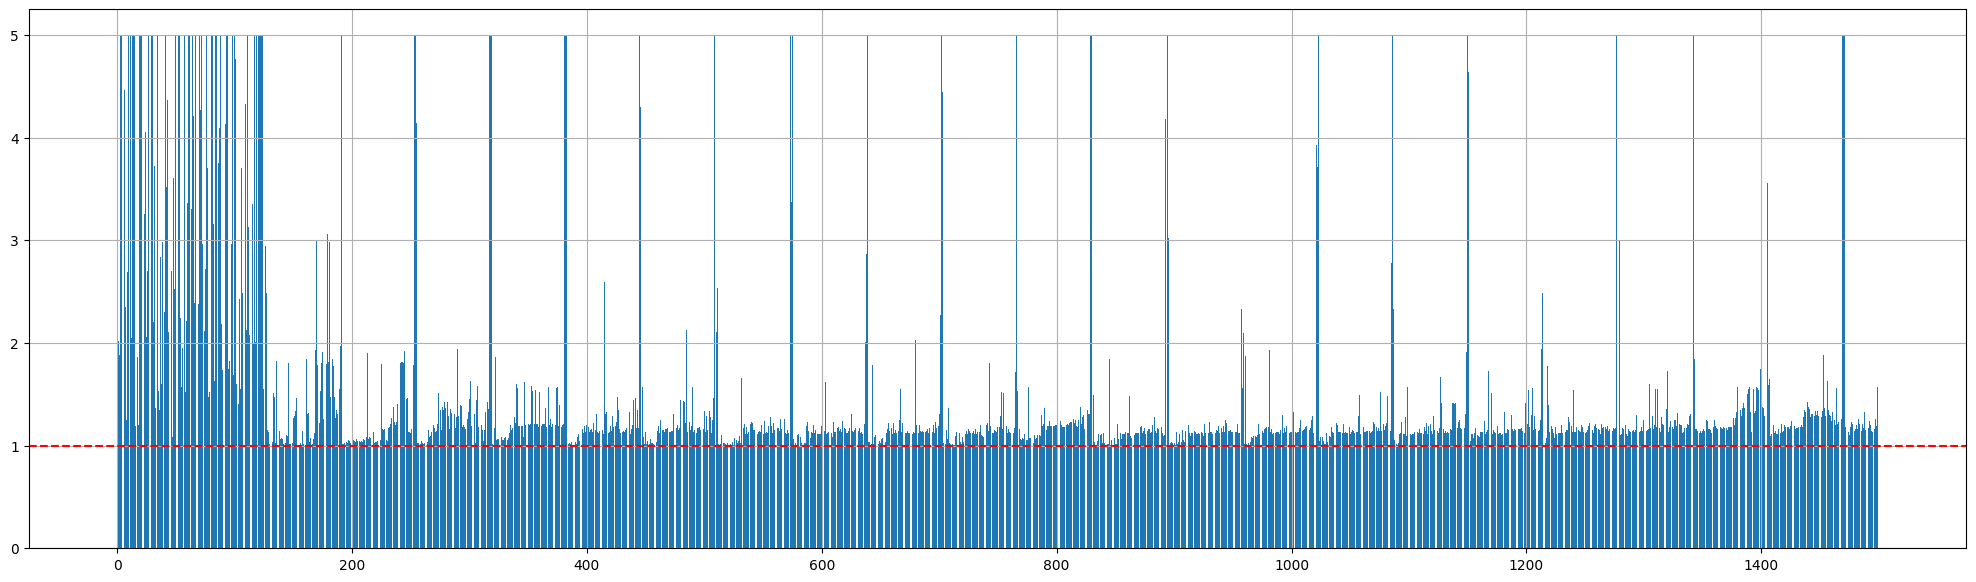

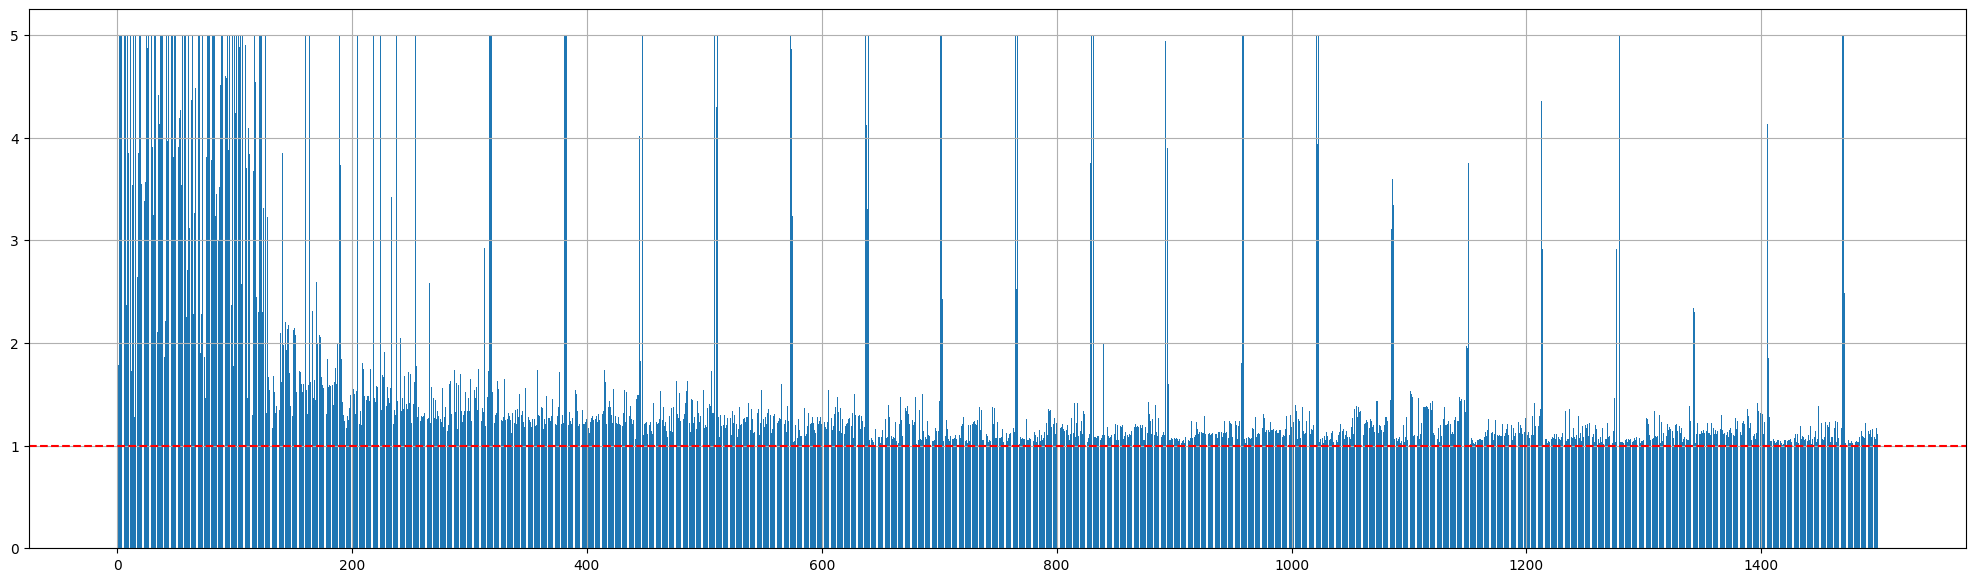

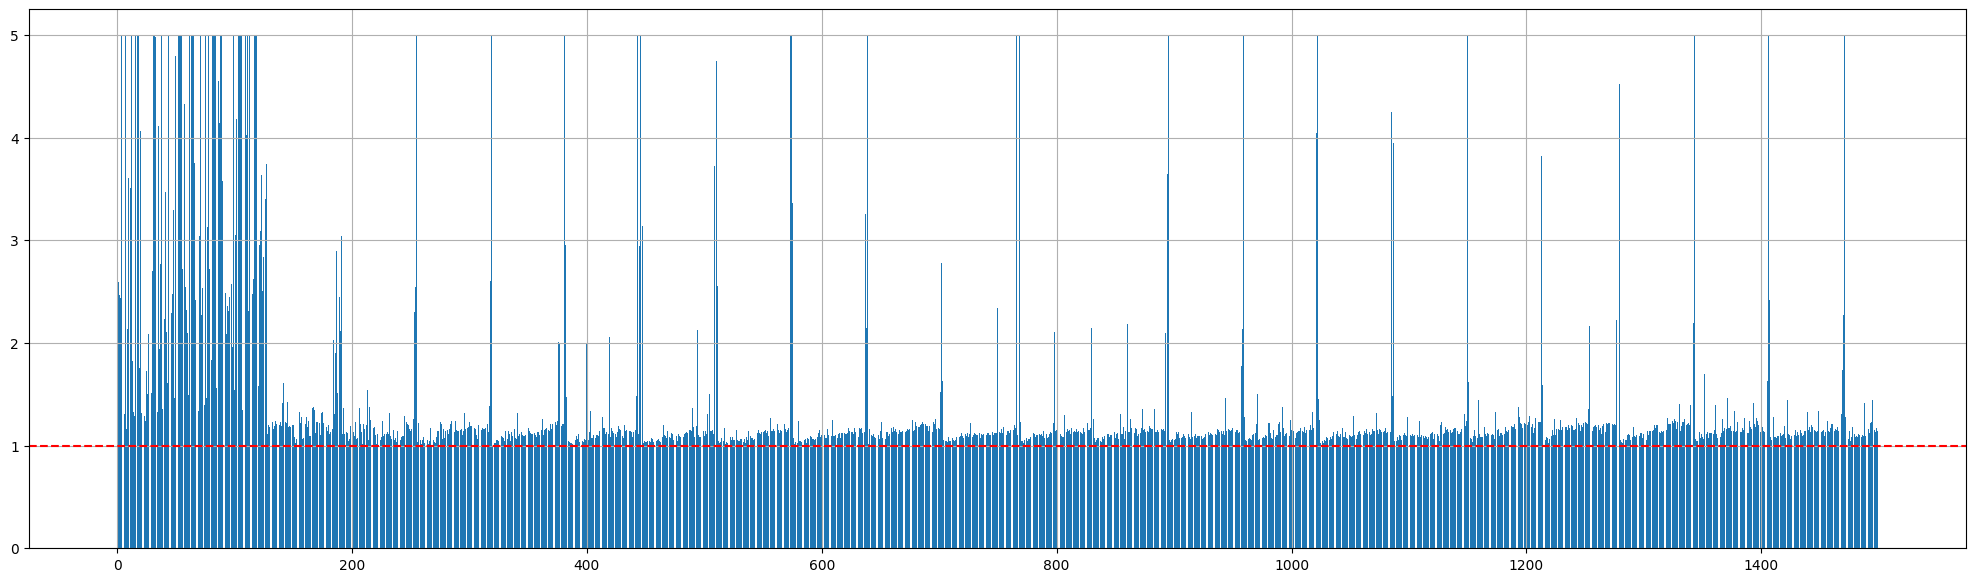

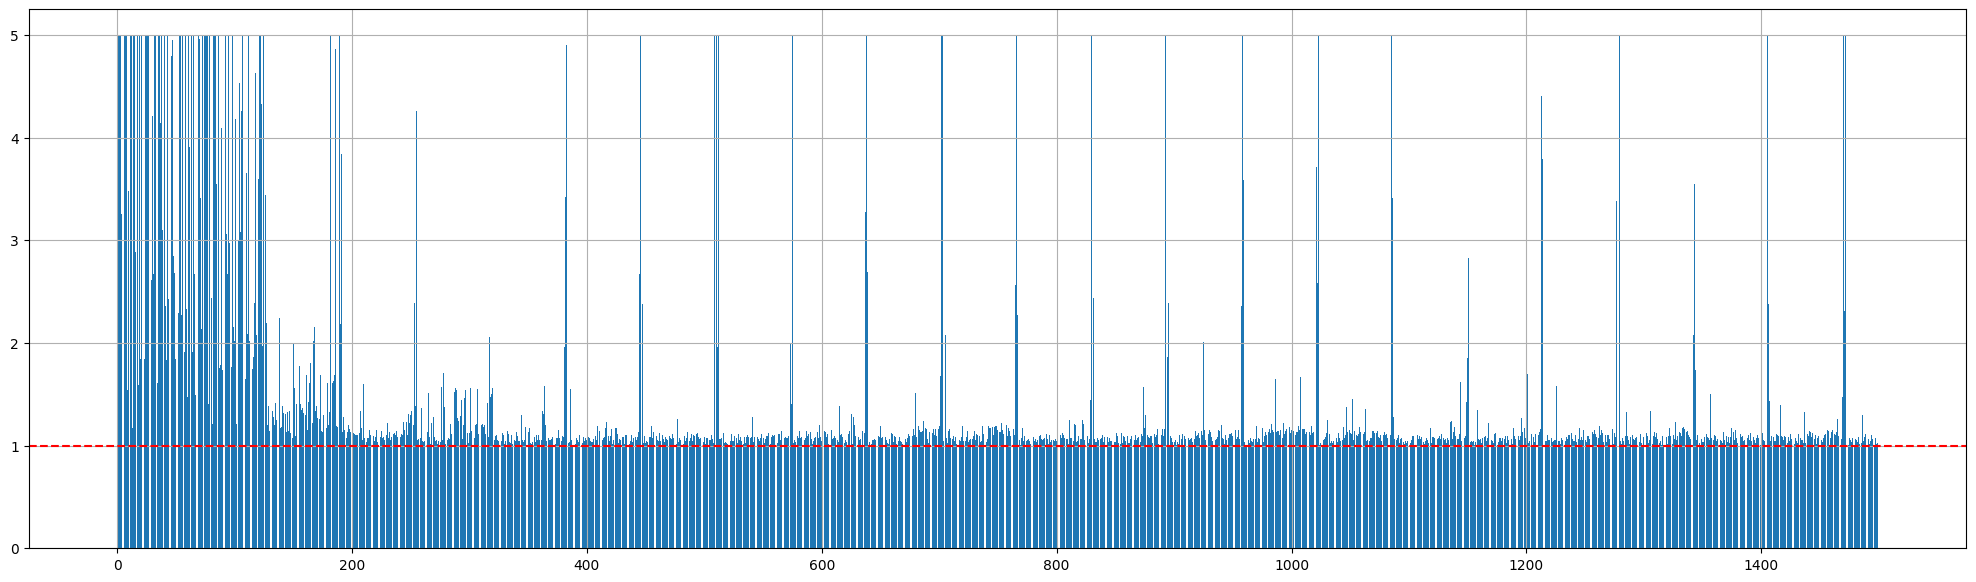

In [42]:
for task in values:
    if(len(values[task]) > 0):
        y = []
        acc = values[task][0]
        for x in values[task]:
            if(x < acc):
                acc = x
            #y.append(acc/min(values[task]))
            if(x/min(values[task]) > 5):
                y.append(5)
            else:
                y.append(x/min(values[task]))
        plt.figure(figsize=(25, 7))
        plt.axhline(y=1, color='r', linestyle='--')
        plt.bar(np.arange(len(y)), y)
        plt.grid()
        plt.show()